# Continues Bayesian

In [ ]:
#!/usr/bin/env python3
"""
Bayesian Hierarchical Model - CONTINUOUS BMI - THREE SEPARATE ANALYSES
Non-Immune | Immune Fine | Immune Coarse
Linear dose-response relationship with BMI as continuous predictor
WITH NON-CENTERED PARAMETERIZATION (FIXES DIVERGENCES)
WITH COMPARTMENT-SPECIFIC REGULARIZING PRIORS (MATCHES CATEGORICAL MODEL)
WITH NAMED DIMENSIONS (IMPROVED INTERPRETABILITY)
WITH PROPER VARIANCE DECOMPOSITION DIAGNOSTICS
"""

import os
import gc
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# CONFIGURATION
# ==============================================================================

BASE = "/content/drive/MyDrive/new_dysfunction"
ROOT = f"{BASE}/stabl_fast/signature_level"
BMI_PATH = "/content/drive/MyDrive/BayesPrism/data/sample_id_with_BMI.csv"

# Bayesian sampling parameters
N_TUNE = 2000
N_SAMPLES = 2000
N_CHAINS = 4
TARGET_ACCEPT = 0.99

# ==============================================================================
# COMPARTMENT-SPECIFIC PRIOR CONFIGURATIONS (MATCHES CATEGORICAL MODEL)
# ==============================================================================

PRIOR_CONFIGS = {
    'nonimmune': {
        'name': 'Non-Immune',
        'celltype_sigma': 0.20,      # BMI slope variance at cell-type level
        'feature_sigma': 0.30,        # BMI slope variance at feature level
        'baseline_sigma': 1.5,       # Feature intercepts
        'obs_sigma': 1.0,            # Observation noise
        'rationale': 'CAFs and endothelial cells show robust BMI-related changes'
    },
    'immune_coarse': {
        'name': 'Immune Coarse',
        'celltype_sigma': 0.25,      # Moderate coordinated lineage shifts
        'feature_sigma': 0.40,        # Higher heterogeneity across markers
        'baseline_sigma': 1.5,       # Feature intercepts
        'obs_sigma': 1.0,            # Observation noise
        'rationale': 'Broad immune populations show moderate effect sizes'
    },
    'immune_fine': {
        'name': 'Immune Fine',
        'celltype_sigma': 0.18,     # STRONGER regularization for subtle states
        'feature_sigma': 0.28,        # TIGHTER control - these are noisy
        'baseline_sigma': 1.5,       # Slightly tighter for subtle signals
        'obs_sigma': 1.0,            # Observation noise
        'rationale': 'Granular states require strong pooling to detect real signal over noise'
    }
}

# ==============================================================================
# THREE SEPARATE ANALYSIS CONFIGURATIONS
# ==============================================================================

ANALYSES = {
    'nonimmune': {
        'name': 'Non-Immune',
        'description': 'Tumor microenvironment (non-immune cells) - Continuous BMI',
        'target': {"name": "non_immune/type_level", "display": "Non-Immune"},
        'output_dir': f"{BASE}/bayesian_hierarchical_continuous_nonimmune",
        'color': '#8B4513',
        'priors': PRIOR_CONFIGS['nonimmune']
    },
    'immune_fine': {
        'name': 'Immune Fine',
        'description': 'Detailed immune cell states - Continuous BMI',
        'target': {"name": "immune_fine/state_level", "display": "Immune Fine"},
        'output_dir': f"{BASE}/bayesian_hierarchical_continuous_immune_fine",
        'color': '#4169E1',
        'priors': PRIOR_CONFIGS['immune_fine']
    },
    'immune_coarse': {
        'name': 'Immune Coarse',
        'description': 'Broad immune cell types - Continuous BMI',
        'target': {"name": "immune_course/type_level", "display": "Immune Coarse"},
        'output_dir': f"{BASE}/bayesian_hierarchical_continuous_immune_coarse",
        'color': '#32CD32',
        'priors': PRIOR_CONFIGS['immune_coarse']
    }
}

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def to_base_id_any(x):
    if pd.isna(x): return np.nan
    first = str(x).split(";")[0].strip()
    parts = first.split("-")
    return f"{parts[0]}-{parts[1]}" if len(parts) >= 2 else first

def parse_feature(feature):
    if "||" in feature:
        parts = feature.split("||", 1)
        return parts[0].strip().replace("_", " "), parts[1].strip()
    return "Unknown", feature

# ==============================================================================
# DATA LOADING
# ==============================================================================

def load_data(target_info, analysis_name):
    """Load data for specific analysis"""
    print(f"\n{'='*80}")
    print(f"LOADING DATA: {analysis_name}")
    print(f"{'='*80}")

    # Load BMI data
    print("\n📊 Loading BMI data...")
    bmi = pd.read_csv(BMI_PATH)
    bmi.columns = [c.lower() for c in bmi.columns]
    bmi["sample_id"] = bmi["sample_id"].astype(str)
    bmi["bmi"] = pd.to_numeric(bmi["bmi"], errors="coerce")
    bmi["base_sample_id"] = bmi["sample_id"].map(to_base_id_any)

    # Standardize BMI for continuous model
    bmi_mean = bmi['bmi'].mean()
    bmi_std = bmi['bmi'].std()
    bmi['bmi_standardized'] = (bmi['bmi'] - bmi_mean) / bmi_std

    print(f"\n📈 BMI statistics (continuous):")
    print(f"  Mean: {bmi_mean:.2f}")
    print(f"  SD: {bmi_std:.2f}")
    print(f"  Min: {bmi['bmi'].min():.2f}")
    print(f"  Max: {bmi['bmi'].max():.2f}")
    print(f"  Range: {bmi['bmi'].max() - bmi['bmi'].min():.2f}")
    print(f"  N samples: {bmi['bmi'].notna().sum()}")

    # Load signature data
    target_group = target_info["name"]
    z_file = f"{ROOT}/{target_group}/rebuilt/z_long_union_all.csv"

    if not os.path.exists(z_file):
        raise FileNotFoundError(f"❌ File not found: {z_file}")

    print(f"\n📁 Loading: {z_file}")
    df = pd.read_csv(z_file)
    df.columns = [c.strip() for c in df.columns]
    df["feature"] = df["CellType"].astype(str) + "||" + df["Signature"].astype(str)
    df["base_sample_id"] = df["Sample"].astype(str).map(to_base_id_any)
    df["Z"] = pd.to_numeric(df["Z"], errors="coerce")
    df['target_group'] = target_group
    df['target_display'] = target_info['display']

    # Merge with BMI
    merged = df.merge(
        bmi[["base_sample_id", "bmi", "bmi_standardized"]],
        on="base_sample_id", how="inner"
    ).dropna(subset=["Z", "bmi"])

    merged[['cell_type', 'signature']] = merged['feature'].apply(
        lambda x: pd.Series(parse_feature(x))
    )

    print(f"\n✅ Loaded {target_info['display']}:")
    print(f"   Observations: {len(merged)}")
    print(f"   Features: {merged['feature'].nunique()}")
    print(f"   Cell types: {merged['cell_type'].nunique()}")
    print(f"   Signatures: {merged['signature'].nunique()}")

    # Show cell type distribution
    print(f"\n📊 Cell type distribution:")
    ct_counts = merged.groupby('cell_type')['feature'].nunique().sort_values(ascending=False)
    for ct, count in ct_counts.head(10).items():
        print(f"   {ct}: {count} signatures")
    if len(ct_counts) > 10:
        print(f"   ... and {len(ct_counts) - 10} more cell types")

    return merged, bmi_mean, bmi_std

def prepare_hierarchical_data(merged_data):
    """Prepare data for hierarchical model with safety checks"""
    merged_data = merged_data.copy()

    # Sort to ensure consistency
    merged_data = merged_data.sort_values(['cell_type', 'feature', 'base_sample_id'])

    # Get unique lists - sorted alphabetically for consistency
    features = sorted(merged_data['feature'].unique())
    cell_types = sorted(merged_data['cell_type'].unique())

    # Create Mappings
    feature_to_idx = {f: i for i, f in enumerate(features)}
    celltype_to_idx = {ct: i for i, ct in enumerate(cell_types)}

    merged_data['feature_idx'] = merged_data['feature'].map(feature_to_idx)
    merged_data['celltype_idx'] = merged_data['cell_type'].map(celltype_to_idx)

    # SAFETY: Ensure feature_to_celltype is ordered exactly by feature_idx (0, 1, 2...)
    mapping_df = merged_data[['feature_idx', 'celltype_idx']].drop_duplicates().sort_values('feature_idx')
    feature_to_celltype = mapping_df['celltype_idx'].values

    print(f"\n🏗️ Hierarchical structure:")
    print(f"   {len(features)} features")
    print(f"   {len(cell_types)} cell types")
    print(f"   Features per cell type: {len(features)/len(cell_types):.1f} avg")
    print(f"   Mapping shape check: {feature_to_celltype.shape}")

    return {
        'data': merged_data,
        'n_obs': len(merged_data),
        'n_features': len(features),
        'n_celltypes': len(cell_types),
        'feature_names': features,
        'celltype_names': cell_types,
        'feature_to_idx': feature_to_idx,
        'celltype_to_idx': celltype_to_idx,
        'feature_to_celltype': feature_to_celltype
    }

# ==============================================================================
# EMPIRICAL VARIANCE ESTIMATION
# ==============================================================================

def estimate_empirical_variance(data_dict, prior_config, bmi_std):
    """
    Estimate empirical BMI slopes to validate prior choices
    Uses simple linear regression per feature
    """
    print(f"\nEmpirical variance estimation for {prior_config['name']}...")

    data = data_dict['data']

    # Simple linear model per feature
    slopes = []

    for feature in data_dict['feature_names']:
        feat_data = data[data['feature'] == feature].copy()

        if len(feat_data) < 10:  # Skip features with too few observations
            continue

        # Simple regression: Z ~ BMI_standardized
        from sklearn.linear_model import LinearRegression
        X = feat_data[['bmi_standardized']].values
        y = feat_data['Z'].values

        try:
            model = LinearRegression()
            model.fit(X, y)
            slopes.append(model.coef_[0])
        except:
            continue

    slopes = np.array(slopes)

    print(f"\n   Empirical BMI slope distribution (standardized):")
    print(f"      Mean: {np.mean(slopes):.3f}")
    print(f"      SD: {np.std(slopes):.3f}")
    print(f"      95% range: [{np.percentile(slopes, 2.5):.3f}, {np.percentile(slopes, 97.5):.3f}]")

    # Convert to per-unit BMI
    slopes_per_unit = slopes / bmi_std
    print(f"\n   Empirical BMI slope distribution (per BMI unit):")
    print(f"      Mean: {np.mean(slopes_per_unit):.4f}")
    print(f"      SD: {np.std(slopes_per_unit):.4f}")
    print(f"      95% range: [{np.percentile(slopes_per_unit, 2.5):.4f}, {np.percentile(slopes_per_unit, 97.5):.4f}]")

    # Compare to chosen priors
    empirical_sigma = np.std(slopes)
    chosen_sigma = prior_config['celltype_sigma']

    print(f"\n   Prior validation:")
    print(f"      Empirical SD (standardized): {empirical_sigma:.3f}")
    print(f"      Chosen cell-type σ: {chosen_sigma:.3f}")

    if chosen_sigma < empirical_sigma * 0.5:
        print(f"      WARNING: Prior may be TOO STRONG (much tighter than data)")
    elif chosen_sigma > empirical_sigma * 2.0:
        print(f"      WARNING: Prior may be TOO WEAK (much wider than data)")
    else:
        print(f"     Prior looks reasonable (within 0.5-2x of empirical)")

    return {
        'slopes_standardized': slopes,
        'slopes_per_unit': slopes_per_unit,
        'empirical_sigma': empirical_sigma
    }

# ==============================================================================
# PRIOR PREDICTIVE CHECK
# ==============================================================================

def run_prior_predictive_check(model, data_dict, prior_config, n_samples=1000):
    """
    Check if priors generate reasonable BMI slopes BEFORE seeing data
    """
    print(f"\nPrior Predictive Check for {prior_config['name']}...")

    with model:
        prior_pred = pm.sample_prior_predictive(samples=n_samples, random_seed=42)

    # Extract prior samples
    celltype_slope = prior_pred.prior['celltype_bmi_slope'].values.flatten()
    feature_slope = prior_pred.prior['feature_bmi_slope'].values.flatten()

    print(f"\nPrior predictions:")
    print(f"   Cell-type BMI slopes:")
    print(f"      95% range: [{np.percentile(celltype_slope, 2.5):.3f}, {np.percentile(celltype_slope, 97.5):.3f}]")
    print(f"      Mean: {np.mean(celltype_slope):.3f}, SD: {np.std(celltype_slope):.3f}")

    print(f"   Feature BMI slopes:")
    print(f"      95% range: [{np.percentile(feature_slope, 2.5):.3f}, {np.percentile(feature_slope, 97.5):.3f}]")
    print(f"      Mean: {np.mean(feature_slope):.3f}, SD: {np.std(feature_slope):.3f}")

    # CHECK: Are these biologically plausible?
    # For standardized BMI slopes, values of |0.5-1.0| are large
    extreme_features = np.sum(np.abs(feature_slope) > 1.5)
    pct_extreme = (extreme_features / len(feature_slope)) * 100

    print(f"\nPrior sanity check:")
    print(f"   Features with |slope| > 1.5: {extreme_features}/{len(feature_slope)} ({pct_extreme:.1f}%)")
    if pct_extreme > 10:
        print(f"   WARNING: Priors may be too weak (>10% extreme values)")
    elif pct_extreme < 1:
        print(f"    WARNING: Priors may be too strong (<1% extreme values)")
    else:
        print(f"   Priors look reasonable (1-10% extreme values)")

    return prior_pred

# ==============================================================================
# MODEL BUILDING - CONTINUOUS BMI WITH NAMED DIMENSIONS
# ==============================================================================

def build_continuous_hierarchical_model(data_dict, prior_config):
    """
    Build hierarchical Bayesian model with CONTINUOUS BMI
    and COMPARTMENT-SPECIFIC REGULARIZING PRIORS
    and NAMED DIMENSIONS for interpretability
    """
    data = data_dict['data']
    print(f"\n🏗️ Building continuous BMI hierarchical model for {prior_config['name']}...")
    print(f"   Rationale: {prior_config['rationale']}")
    print(f"   Cell-type σ (BMI slope): {prior_config['celltype_sigma']}")
    print(f"   Feature σ (BMI slope): {prior_config['feature_sigma']}")
    print(f"   Baseline σ: {prior_config['baseline_sigma']}")

    # Define Coordinates for ArviZ
    coords = {
        "celltype": data_dict['celltype_names'],
        "feature": data_dict['feature_names'],
        "obs_id": data.index
    }

    # Pass coords to the model
    with pm.Model(coords=coords) as model:

        # --- GLOBAL DATA CONTAINERS ---
        feature_idx_data = pm.Data("feature_idx_data", data['feature_idx'].values, dims="obs_id")
        bmi_std_data = pm.Data("bmi_std_data", data['bmi_standardized'].values, dims="obs_id")
        observed_data = pm.Data("observed_data", data['Z'].values, dims="obs_id")

        # Map features to cell types
        feature_map = pm.Data("feature_to_celltype_map", data_dict['feature_to_celltype'], dims="feature")

        # ===== COMPARTMENT-SPECIFIC CELL-TYPE LEVEL (HYPERPRIORS FOR BMI SLOPES) =====
        celltype_bmi_slope = pm.Normal(
            'celltype_bmi_slope',
            mu=0,
            sigma=prior_config['celltype_sigma'],
            dims="celltype"
        )

        # ===== COMPARTMENT-SPECIFIC FEATURE-LEVEL VARIANCE FOR BMI SLOPES =====
        feature_sigma_bmi = pm.HalfNormal(
            'feature_sigma_bmi',
            sigma=prior_config['feature_sigma'],
            dims="celltype"
        )

        # ===== NON-CENTERED: Feature-level BMI slope deviations =====
        feature_deviation_bmi_raw = pm.Normal(
            'feature_deviation_bmi_raw',
            mu=0, sigma=1,
            dims="feature"
        )

        # ===== NON-CENTERED: Feature-level BMI slopes (partial pooling) =====
        feature_bmi_slope = pm.Deterministic(
            'feature_bmi_slope',
            celltype_bmi_slope[feature_map] +
            feature_deviation_bmi_raw * feature_sigma_bmi[feature_map],
            dims="feature"
        )

        # Baseline (intercept) for each feature
        feature_baseline = pm.Normal(
            'feature_baseline',
            mu=0,
            sigma=prior_config['baseline_sigma'],
            dims="feature"
        )

        # Observation noise
        sigma_obs = pm.HalfNormal('sigma_obs', sigma=prior_config['obs_sigma'])

        # ===== LIKELIHOOD: Z ~ baseline + slope × BMI_standardized =====
        mu = pm.Deterministic(
            'mu',
            feature_baseline[feature_idx_data] +
            feature_bmi_slope[feature_idx_data] * bmi_std_data,
            dims="obs_id"
        )

        pm.Normal('y_obs', mu=mu, sigma=sigma_obs, observed=observed_data, dims="obs_id")

    print(f"Model built with compartment-specific priors:")
    print(f"   Parameters: {len(model.free_RVs)}")
    print(f"   Observations: {len(data)}")
    print(f"   Coordinates: {list(coords.keys())}")
    print(f"   Model: Z = baseline + slope × BMI_standardized")

    return model

# ==============================================================================
# SAMPLING
# ==============================================================================

def sample_hierarchical_model(model):
    """Sample from the model"""
    print(f"\n Sampling posterior...")
    print(f"   Tuning: {N_TUNE} iterations")
    print(f"   Sampling: {N_SAMPLES} iterations")
    print(f"   Chains: {N_CHAINS}")
    print(f"   Target accept: {TARGET_ACCEPT}")

    with model:
        trace = pm.sample(
            draws=N_SAMPLES,
            tune=N_TUNE,
            chains=N_CHAINS,
            cores=N_CHAINS,
            target_accept=TARGET_ACCEPT,
            return_inferencedata=True,
            progressbar=True
        )

    print(f"\nSampling complete!")
    return trace

# ==============================================================================
# POSTERIOR PREDICTIVE CHECK
# ==============================================================================

def generate_ppc(model, trace, data_dict):
    """Generate posterior predictive samples"""
    print("\n🔮 Generating posterior predictive check...")

    with model:
        ppc = pm.sample_posterior_predictive(
            trace,
            var_names=['y_obs'],
            random_seed=42,
            progressbar=True
        )

        trace.extend(ppc)

        print(f"\nPPC generated!")
        print(f"   Shape: {ppc.posterior_predictive['y_obs'].shape}")

        # Quick validation
        observed = data_dict['data']['Z'].values
        predicted = ppc.posterior_predictive['y_obs'].values

        obs_mean = observed.mean()
        obs_sd = observed.std()
        pred_mean = predicted.mean()
        pred_sd = predicted.std()

        print(f"\nModel fit check:")
        print(f"   Observed  - Mean: {obs_mean:.3f}, SD: {obs_sd:.3f}")
        print(f"   Predicted - Mean: {pred_mean:.3f}, SD: {pred_sd:.3f}")
        print(f"   Mean diff: {abs(obs_mean - pred_mean):.3f} "
              f"({'Good' if abs(obs_mean - pred_mean) < 0.5 else 'Check'})")
        print(f"   SD diff: {abs(obs_sd - pred_sd):.3f} "
              f"({'Good' if abs(obs_sd - pred_sd) < 0.5 else 'Check'})")

    return trace

# ==============================================================================
# RESULTS SUMMARIZATION
# ==============================================================================

def summarize_results(trace, data_dict, bmi_std):
    """Extract summary statistics"""
    print("\nExtracting summaries...")

    summary = az.summary(
        trace,
        var_names=['feature_bmi_slope'],
        hdi_prob=0.95
    )

    results = []
    for i, feature in enumerate(data_dict['feature_names']):
        celltype_idx = data_dict['feature_to_celltype'][i]
        celltype = data_dict['celltype_names'][celltype_idx]

        # With named dimensions
        slope_idx = f'feature_bmi_slope[{feature}]'

        # BMI slope (standardized)
        slope_mean = summary.loc[slope_idx, 'mean']
        slope_low = summary.loc[slope_idx, 'hdi_2.5%']
        slope_high = summary.loc[slope_idx, 'hdi_97.5%']

        # Posterior samples
        post_slope = trace.posterior['feature_bmi_slope'].sel(feature=feature).values.flatten()

        # Convert to per-unit BMI
        slope_per_unit_mean = slope_mean / bmi_std
        slope_per_unit_low = slope_low / bmi_std
        slope_per_unit_high = slope_high / bmi_std

        results.append({
            'feature': feature,
            'cell_type': celltype,
            'bmi_slope_standardized_mean': slope_mean,
            'bmi_slope_standardized_hdi_low': slope_low,
            'bmi_slope_standardized_hdi_high': slope_high,
            'bmi_slope_per_unit_mean': slope_per_unit_mean,
            'bmi_slope_per_unit_hdi_low': slope_per_unit_low,
            'bmi_slope_per_unit_hdi_high': slope_per_unit_high,
            'prob_positive': np.mean(post_slope > 0),
            'prob_negative': np.mean(post_slope < 0),
            'prob_sig_0.1': np.mean(np.abs(post_slope) > 0.1),
            'prob_sig_0.2': np.mean(np.abs(post_slope) > 0.2),
            'prob_sig_0.3': np.mean(np.abs(post_slope) > 0.3),
        })

    print(f"✅ Summaries extracted for {len(results)} features")

    return pd.DataFrame(results)

# ==============================================================================
# SAVE OUTPUTS
# ==============================================================================

def save_outputs(trace, results_df, data_dict, output_dir, prior_config, bmi_mean, bmi_std):
    """Save all outputs"""
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n💾 Saving outputs to: {output_dir}")

    # Save trace
    trace_path = os.path.join(output_dir, 'posterior_trace.nc')
    if os.path.exists(trace_path):
        try:
            os.remove(trace_path)
        except Exception as e:
            print(f"   ⚠️  Could not remove old trace: {e}")

    trace.to_netcdf(trace_path)
    print(f"   Trace: posterior_trace.nc")

    # Save results
    results_path = os.path.join(output_dir, 'bayesian_results_continuous.csv')
    results_df.to_csv(results_path, index=False)
    print(f"   Results: bayesian_results_continuous.csv")

    # Save BMI scaling info
    bmi_info = pd.DataFrame({
        'parameter': ['bmi_mean', 'bmi_std'],
        'value': [bmi_mean, bmi_std]
    })
    bmi_info_path = os.path.join(output_dir, 'bmi_scaling_info.csv')
    bmi_info.to_csv(bmi_info_path, index=False)
    print(f"   BMI scaling: bmi_scaling_info.csv")

    # Save cell type mapping
    celltype_mapping = pd.DataFrame({
        'celltype_idx': range(data_dict['n_celltypes']),
        'celltype_name': list(data_dict['celltype_names'])
    })
    celltype_path = os.path.join(output_dir, 'celltype_mapping.csv')
    celltype_mapping.to_csv(celltype_path, index=False)
    print(f"   Cell types: celltype_mapping.csv")

    # Save feature mapping
    feature_mapping = pd.DataFrame({
        'feature_idx': range(data_dict['n_features']),
        'feature_name': list(data_dict['feature_names']),
        'celltype_idx': data_dict['feature_to_celltype']
    })
    feature_path = os.path.join(output_dir, 'feature_mapping.csv')
    feature_mapping.to_csv(feature_path, index=False)
    print(f"   Features: feature_mapping.csv")

    # Save prior configuration used
    prior_config_df = pd.DataFrame([{
        'compartment': prior_config['name'],
        'celltype_sigma': prior_config['celltype_sigma'],
        'feature_sigma': prior_config['feature_sigma'],
        'baseline_sigma': prior_config['baseline_sigma'],
        'obs_sigma': prior_config['obs_sigma'],
        'rationale': prior_config['rationale']
    }])
    prior_path = os.path.join(output_dir, 'prior_configuration.csv')
    prior_config_df.to_csv(prior_path, index=False)
    print(f"  Prior config: prior_configuration.csv")

# ==============================================================================
# VARIANCE DECOMPOSITION DIAGNOSTICS
# ==============================================================================

def variance_decomposition(trace, data_dict, prior_config):
    """
    Proper variance decomposition to show hierarchical structure
    """
    print(f"\nVariance Decomposition for {prior_config['name']}:")

    # Get cell-type level BMI slopes
    celltype_slopes = trace.posterior['celltype_bmi_slope'].values.mean(axis=(0, 1))

    # Get feature-level BMI slopes
    feature_slopes = trace.posterior['feature_bmi_slope'].values.mean(axis=(0, 1))

    # Get feature sigmas
    feature_sigmas = trace.posterior['feature_sigma_bmi'].values.mean(axis=(0, 1))

    # Calculate variances
    var_between_celltypes = np.var(celltype_slopes)

    # Within-cell-type variance
    feature_to_celltype = data_dict['feature_to_celltype']
    within_vars = []
    for ct_idx in range(data_dict['n_celltypes']):
        feat_mask = feature_to_celltype == ct_idx
        if np.sum(feat_mask) > 0:
            ct_feature_slopes = feature_slopes[feat_mask]
            ct_mean = celltype_slopes[ct_idx]
            within_var = np.mean((ct_feature_slopes - ct_mean)**2)
            within_vars.append(within_var)

    var_within_celltypes = np.mean(within_vars)
    total_var = var_between_celltypes + var_within_celltypes
    icc = var_between_celltypes / total_var if total_var > 0 else 0
    observed_total_var = np.var(feature_slopes)

    print(f"\n   BMI Slopes:")
    print(f"      Between cell-type variance: {var_between_celltypes:.6f}")
    print(f"      Within cell-type variance:  {var_within_celltypes:.6f}")
    print(f"      Total variance (sum):       {total_var:.6f}")
    print(f"      Observed total variance:    {observed_total_var:.6f}")
    print(f"      ICC (between/total):        {icc:.3f}")

    if icc > 0.7:
        print(f"     STRONG hierarchy: {icc*100:.1f}% of variance is between cell types")
        print(f"         (Features within cell types show similar BMI responses)")
    elif icc > 0.4:
        print(f"       MODERATE hierarchy: {icc*100:.1f}% of variance is between cell types")
        print(f"         (Some heterogeneity within cell types)")
    else:
        print(f"      WEAK hierarchy: Only {icc*100:.1f}% of variance is between cell types")
        print(f"         (High heterogeneity within cell types)")

    # Average feature sigma
    avg_sigma = np.mean(feature_sigmas)
    print(f"\n      Posterior feature σ (avg): {avg_sigma:.3f}")
    print(f"      Prior feature σ:           {prior_config['feature_sigma']:.3f}")
    print(f"      Shrinkage factor:          {avg_sigma / prior_config['feature_sigma']:.2f}x")

    if avg_sigma < prior_config['feature_sigma'] * 0.5:
        print(f"      Strong data-driven shrinkage (>50% reduction)")
    elif avg_sigma < prior_config['feature_sigma'] * 0.8:
        print(f"      Moderate data-driven shrinkage")
    elif avg_sigma > prior_config['feature_sigma'] * 1.2:
        print(f"      Data suggest weaker pooling than prior")
    else:
        print(f"      Data consistent with prior")

def check_shrinkage(trace, data_dict, prior_config):
    """
    Calculate and report hierarchical shrinkage
    NOW WITH PROPER INTERPRETATION
    """
    print(f"\n Hierarchical Pooling Diagnostics for {prior_config['name']}:")

    # Get cell-type level BMI slopes
    celltype_slopes = trace.posterior['celltype_bmi_slope'].values.mean(axis=(0, 1))

    # Get feature-level BMI slopes
    feature_slopes = trace.posterior['feature_bmi_slope'].values.mean(axis=(0, 1))

    # Map features to cell types
    feature_to_celltype = data_dict['feature_to_celltype']

    # Calculate deviation from cell-type mean per feature
    deviations = []
    for feat_idx in range(data_dict['n_features']):
        ct_idx = feature_to_celltype[feat_idx]
        pooled = celltype_slopes[ct_idx]
        feature = feature_slopes[feat_idx]
        deviation = abs(feature - pooled)
        deviations.append(deviation)

    avg_deviation = np.mean(deviations)
    max_deviation = np.max(deviations)
    median_deviation = np.median(deviations)

    # Calculate what proportion of effect is at cell-type vs feature level
    feature_empirical_sd = np.std(feature_slopes)
    if feature_empirical_sd > 0:
        pct_at_celltype = (1 - avg_deviation / feature_empirical_sd) * 100
    else:
        pct_at_celltype = 0

    print(f"\n   BMI Slopes:")
    print(f"      Average deviation from cell-type mean: {avg_deviation:.3f}")
    print(f"      Median deviation:  {median_deviation:.3f}")
    print(f"      Maximum deviation: {max_deviation:.3f}")
    print(f"      Empirical SD of feature slopes: {feature_empirical_sd:.3f}")
    print(f"      → {pct_at_celltype:.1f}% of variation captured at cell-type level")

    if pct_at_celltype > 80:
        print(f"      STRONG pooling: Features tightly grouped within cell types")
    elif pct_at_celltype > 50:
        print(f"      MODERATE pooling: Some feature-level variation remains")
    else:
        print(f"      WEAK pooling: Features behaving independently")

    # Calculate percentage of features with large deviations
    large_dev = sum(1 for d in deviations if d > 0.1)
    pct_large = (large_dev / len(deviations)) * 100
    print(f"      Features with deviation >0.1: {large_dev} ({pct_large:.1f}%)")

# ==============================================================================
# CONVERGENCE DIAGNOSTICS
# ==============================================================================

def check_convergence(trace, results_df):
    """Check convergence diagnostics"""
    print(f"\n Convergence diagnostics:")

    # R-hat
    rhat_summary = az.summary(
        trace,
        var_names=['celltype_bmi_slope']
    )
    max_rhat = rhat_summary['r_hat'].max()
    print(f"   Max R-hat: {max_rhat:.4f} "
          f"({'Converged' if max_rhat < 1.01 else ' Check convergence'})")

    # Credible effects (HDI-based)
    credible = ((results_df['bmi_slope_standardized_hdi_low'] > 0) |
                (results_df['bmi_slope_standardized_hdi_high'] < 0)).sum()
    positive = (results_df['bmi_slope_standardized_hdi_low'] > 0).sum()
    negative = (results_df['bmi_slope_standardized_hdi_high'] < 0).sum()

    print(f"\nCredible BMI effects (HDI excludes 0):")
    print(f"   Total credible: {credible}/{len(results_df)} "
          f"({credible/len(results_df)*100:.1f}%)")
    print(f"   Positive (↑ with BMI): {positive}/{len(results_df)} "
          f"({positive/len(results_df)*100:.1f}%)")
    print(f"   Negative (↓ with BMI): {negative}/{len(results_df)} "
          f"({negative/len(results_df)*100:.1f}%)")

    print(f"\n   Note: These are HDI-based credibility counts.")
    print(f"   For practical significance, also check prob_sig columns in results CSV.")

# ==============================================================================
# RUN SINGLE ANALYSIS
# ==============================================================================

def run_analysis(analysis_key):
    """Run a single analysis with compartment-specific priors and validation"""
    config = ANALYSES[analysis_key]
    prior_config = config['priors']

    print("\n" + "="*80)
    print(f"ANALYSIS: {config['name']}")
    print(f"{config['description']}")
    print(f"Prior strategy: {prior_config['rationale']}")
    print("="*80)

    # Load data
    data, bmi_mean, bmi_std = load_data(config['target'], config['name'])

    # Prepare hierarchical structure
    data_dict = prepare_hierarchical_data(data)

    # VALIDATE PRIORS AGAINST EMPIRICAL DATA
    empirical = estimate_empirical_variance(data_dict, prior_config, bmi_std)

    # Build model
    model = build_continuous_hierarchical_model(data_dict, prior_config)

    # Prior predictive check
    prior_pred = run_prior_predictive_check(model, data_dict, prior_config)

    # Sample
    trace = sample_hierarchical_model(model)

    # Posterior predictive check
    trace = generate_ppc(model, trace, data_dict)

    # Summarize results
    results_df = summarize_results(trace, data_dict, bmi_std)

    # Save outputs
    save_outputs(trace, results_df, data_dict, config['output_dir'], prior_config, bmi_mean, bmi_std)

    # Diagnostics
    check_convergence(trace, results_df)
    variance_decomposition(trace, data_dict, prior_config)
    check_shrinkage(trace, data_dict, prior_config)

    print(f"\n {config['name']} analysis complete!")
    print(f" Results saved to: {config['output_dir']}")

    # Cleanup
    del trace
    del model
    del prior_pred
    gc.collect()

    return {
        'results': results_df,
        'data_dict': data_dict,
        'config': config,
        'empirical': empirical,
        'bmi_mean': bmi_mean,
        'bmi_std': bmi_std
    }

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    """Run all three analyses with compartment-specific priors"""
    print("="*80)
    print(" BAYESIAN HIERARCHICAL MODEL - CONTINUOUS BMI - THREE COMPARTMENTS")
    print("   WITH COMPARTMENT-SPECIFIC REGULARIZING PRIORS")
    print("   WITH NAMED DIMENSIONS FOR IMPROVED INTERPRETABILITY")
    print("   WITH PROPER VARIANCE DECOMPOSITION DIAGNOSTICS")
    print("="*80)
    print("\n Analyses to run with prior configurations:")
    for key, config in ANALYSES.items():
        priors = config['priors']
        print(f"\n   {config['name']}:")
        print(f"      {config['description']}")
        print(f"      Cell-type σ (BMI slope): {priors['celltype_sigma']}")
        print(f"      Feature σ (BMI slope): {priors['feature_sigma']}")
        print(f"      Rationale: {priors['rationale']}")

    all_results = {}

    # Run each analysis
    for analysis_key in ['nonimmune', 'immune_fine', 'immune_coarse']:
        try:
            results = run_analysis(analysis_key)
            all_results[analysis_key] = results
        except Exception as e:
            print(f"\n ERROR in {analysis_key}: {e}")
            import traceback
            traceback.print_exc()
            continue

    # Summary across all analyses
    print("\n" + "="*80)
    print(" SUMMARY ACROSS ALL ANALYSES")
    print("="*80)

    for key, results in all_results.items():
        config = results['config']
        df = results['results']
        priors = config['priors']

        print(f"\n{config['name']}:")
        print(f"   Output: {config['output_dir']}")
        print(f"   Features: {len(df)}")
        print(f"   Cell types: {results['data_dict']['n_celltypes']}")
        print(f"   Prior configuration:")
        print(f"      Cell-type σ: {priors['celltype_sigma']}")
        print(f"      Feature σ: {priors['feature_sigma']}")

        credible = ((df['bmi_slope_standardized_hdi_low'] > 0) |
                    (df['bmi_slope_standardized_hdi_high'] < 0)).sum()
        positive = (df['bmi_slope_standardized_hdi_low'] > 0).sum()

        print(f"   Credible effects: {credible} ({credible/len(df)*100:.1f}%)")
        print(f"   Positive slopes: {positive} ({positive/len(df)*100:.1f}%)")

    print("\n" + "="*80)
    print("ALL ANALYSES COMPLETE!")
    print("="*80)

    print("\n Next steps:")
    print("   1. Compare continuous vs categorical results")
    print("   2. Run diagnostics for each compartment")
    print("   3. Create dose-response visualizations")
    print("   4. Compare BMI slope estimates across compartments")

    return all_results

if __name__ == "__main__":
    results = main()

    import requests, time
    requests.post("https://ntfy.sh/colab_alerts",
                  data=f"🏁 Continuous BMI Model Finished {time.strftime('%Y-%m-%d %H:%M:%S')}".encode(),
                  headers={"Title":"Colab", "Priority":"5"})

🔬 BAYESIAN HIERARCHICAL MODEL - CONTINUOUS BMI - THREE COMPARTMENTS
   WITH COMPARTMENT-SPECIFIC REGULARIZING PRIORS
   WITH NAMED DIMENSIONS FOR IMPROVED INTERPRETABILITY
   WITH PROPER VARIANCE DECOMPOSITION DIAGNOSTICS

📋 Analyses to run with prior configurations:

   Non-Immune:
      Tumor microenvironment (non-immune cells) - Continuous BMI
      Cell-type σ (BMI slope): 0.2
      Feature σ (BMI slope): 0.3
      Rationale: CAFs and endothelial cells show robust BMI-related changes

   Immune Fine:
      Detailed immune cell states - Continuous BMI
      Cell-type σ (BMI slope): 0.18
      Feature σ (BMI slope): 0.28
      Rationale: Granular states require strong pooling to detect real signal over noise

   Immune Coarse:
      Broad immune cell types - Continuous BMI
      Cell-type σ (BMI slope): 0.25
      Feature σ (BMI slope): 0.4
      Rationale: Broad immune populations show moderate effect sizes

🔬 ANALYSIS: Non-Immune
📝 Tumor microenvironment (non-immune cells) - Contin

Output()

Output()


✅ Sampling complete!

🔮 Generating posterior predictive check...



✅ PPC generated!
   Shape: (4, 2000, 31623)

📊 Model fit check:
   Observed  - Mean: -0.026, SD: 0.490
   Predicted - Mean: -0.026, SD: 0.495
   Mean diff: 0.000 (✅ Good)
   SD diff: 0.004 (✅ Good)

📊 Extracting summaries...
✅ Summaries extracted for 249 features

💾 Saving outputs to: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune
   ✅ Trace: posterior_trace.nc
   ✅ Results: bayesian_results_continuous.csv
   ✅ BMI scaling: bmi_scaling_info.csv
   ✅ Cell types: celltype_mapping.csv
   ✅ Features: feature_mapping.csv
   ✅ Prior config: prior_configuration.csv

🔍 Convergence diagnostics:
   Max R-hat: 1.0000 (✅ Converged)

📊 Credible BMI effects (HDI excludes 0):
   Total credible: 104/249 (41.8%)
   Positive (↑ with BMI): 98/249 (39.4%)
   Negative (↓ with BMI): 6/249 (2.4%)

   Note: These are HDI-based credibility counts.
   For practical significance, also check prob_sig columns in results CSV.

📊 Variance Decomposition for Non-Immune:

   BMI Slop

...


✅ PPC generated!
   Shape: (4, 2000, 19812)

📊 Model fit check:
   Observed  - Mean: -0.022, SD: 0.549
   Predicted - Mean: -0.022, SD: 0.554
   Mean diff: 0.000 (✅ Good)
   SD diff: 0.005 (✅ Good)

📊 Extracting summaries...
✅ Summaries extracted for 156 features

💾 Saving outputs to: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine
   ✅ Trace: posterior_trace.nc
   ✅ Results: bayesian_results_continuous.csv
   ✅ BMI scaling: bmi_scaling_info.csv
   ✅ Cell types: celltype_mapping.csv
   ✅ Features: feature_mapping.csv
   ✅ Prior config: prior_configuration.csv

🔍 Convergence diagnostics:
   Max R-hat: 1.0000 (✅ Converged)

📊 Credible BMI effects (HDI excludes 0):
   Total credible: 37/156 (23.7%)
   Positive (↑ with BMI): 37/156 (23.7%)
   Negative (↓ with BMI): 0/156 (0.0%)

   Note: These are HDI-based credibility counts.
   For practical significance, also check prob_sig columns in results CSV.

📊 Variance Decomposition for Immune Fine:

   BMI Sl

Output()

Output()


✅ Sampling complete!

🔮 Generating posterior predictive check...



✅ PPC generated!
   Shape: (4, 2000, 21209)

📊 Model fit check:
   Observed  - Mean: -0.022, SD: 0.640
   Predicted - Mean: -0.021, SD: 0.646
   Mean diff: 0.000 (✅ Good)
   SD diff: 0.006 (✅ Good)

📊 Extracting summaries...
✅ Summaries extracted for 167 features

💾 Saving outputs to: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse
   ✅ Trace: posterior_trace.nc
   ✅ Results: bayesian_results_continuous.csv
   ✅ BMI scaling: bmi_scaling_info.csv
   ✅ Cell types: celltype_mapping.csv
   ✅ Features: feature_mapping.csv
   ✅ Prior config: prior_configuration.csv

🔍 Convergence diagnostics:
   Max R-hat: 1.0000 (✅ Converged)

📊 Credible BMI effects (HDI excludes 0):
   Total credible: 42/167 (25.1%)
   Positive (↑ with BMI): 29/167 (17.4%)
   Negative (↓ with BMI): 13/167 (7.8%)

   Note: These are HDI-based credibility counts.
   For practical significance, also check prob_sig columns in results CSV.

📊 Variance Decomposition for Immune Coarse:

   B

## ROPE proabilities

In [ ]:
#!/usr/bin/env python3
"""
SCRIPT: Add ROPE Probabilities + Credible Flags to Bayesian Results
CONTINUOUS BMI VERSION - MATCHES CATEGORICAL STRUCTURE
Runs for ALL COMPARTMENTS: nonimmune, immune_fine, immune_coarse
"""

import os
import numpy as np
import pandas as pd
import arviz as az
import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# CONFIG
# ==============================================================================

BASE = "/content/drive/MyDrive/new_dysfunction"

COMPARTMENTS = {
    'nonimmune': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_nonimmune",
        'name': 'Non-Immune',
        'color': '#8B4513'
    },
    'immune_fine': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_immune_fine",
        'name': 'Immune Fine',
        'color': '#4169E1'
    },
    'immune_coarse': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_immune_coarse",
        'name': 'Immune Coarse',
        'color': '#32CD32'
    }
}

COMPARTMENTS_TO_RUN = ['nonimmune', 'immune_fine', 'immune_coarse']

# ROPE thresholds for STANDARDIZED BMI slopes
# For standardized slopes:
# - 0.1 = small effect (like Cohen's d)
# - 0.2 = medium effect
# - 0.3 = large effect
ROPE_THRESHOLDS = [0.05, 0.1, 0.15, 0.2, 0.3]

# ==============================================================================
# FUNCTIONS
# ==============================================================================

def calculate_rope_probabilities(posterior_samples, thresholds):
    """Calculate P(|effect| > threshold) for each threshold"""
    probs = {}
    for thresh in thresholds:
        prob_large = np.mean(np.abs(posterior_samples) > thresh)
        probs[f'prob_gt_{thresh}'] = prob_large
    return probs

def evidence_strength(prob):
    """Categorize evidence strength based on probability"""
    if prob > 0.95:
        return "Strong"
    elif prob > 0.80:
        return "Moderate"
    elif prob > 0.60:
        return "Weak"
    else:
        return "Negligible"

def add_credible_flags(results):
    """Add credible flags based on HDI excluding 0 for BMI slope"""
    print("\n Adding credible flags based on HDI...")

    # For continuous BMI, we only have ONE comparison: BMI slope
    low_col = 'bmi_slope_standardized_hdi_low'
    high_col = 'bmi_slope_standardized_hdi_high'
    cred_col = 'bmi_slope_credible'

    if low_col in results.columns and high_col in results.columns:
        # HDI excludes 0 if: low > 0 OR high < 0
        results[cred_col] = (results[low_col] > 0) | (results[high_col] < 0)

        n_cred = results[cred_col].sum()
        n_pos = ((results[low_col] > 0)).sum()
        n_neg = ((results[high_col] < 0)).sum()

        print(f"  {cred_col}:")
        print(f"    Total credible: {n_cred}/{len(results)} ({n_cred/len(results)*100:.1f}%)")
        print(f"    Positive (↑ with BMI): {n_pos} ({n_pos/len(results)*100:.1f}%)")
        print(f"    Negative (↓ with BMI): {n_neg} ({n_neg/len(results)*100:.1f}%)")
    else:
        print(f"   Missing HDI columns: {low_col}, {high_col}")
        results[cred_col] = False

    return results

def add_direction_flags(results):
    """Add direction flags (positive/negative) for credible BMI slopes"""
    print("\n Adding direction flags...")

    mean_col = 'bmi_slope_standardized_mean'
    low_col = 'bmi_slope_standardized_hdi_low'
    high_col = 'bmi_slope_standardized_hdi_high'
    cred_col = 'bmi_slope_credible'
    dir_col = 'bmi_slope_direction'

    if mean_col in results.columns and cred_col in results.columns:
        # Direction: 'positive', 'negative', or 'none' (not credible)
        results[dir_col] = 'none'
        results.loc[(results[cred_col]) & (results[low_col] > 0), dir_col] = 'positive'
        results.loc[(results[cred_col]) & (results[high_col] < 0), dir_col] = 'negative'

        n_pos = (results[dir_col] == 'positive').sum()
        n_neg = (results[dir_col] == 'negative').sum()
        print(f"  BMI slope directions:")
        print(f"    Positive (↑ with BMI): {n_pos}/{len(results)} ({n_pos/len(results)*100:.1f}%)")
        print(f"    Negative (↓ with BMI): {n_neg}/{len(results)*100:.1f}%)")
    else:
        print(f"  Missing columns for direction flags")
        results[dir_col] = 'none'

    return results

def add_effect_size_categories(results):
    """Add effect size categories based on standardized slopes"""
    print("\n Adding effect size categories...")

    mean_col = 'bmi_slope_standardized_mean'
    cred_col = 'bmi_slope_credible'
    size_col = 'effect_size_category'

    if mean_col in results.columns and cred_col in results.columns:
        # Only categorize credible effects
        results[size_col] = 'negligible'

        abs_mean = results[mean_col].abs()

        # For credible effects only
        credible_mask = results[cred_col]

        results.loc[credible_mask & (abs_mean >= 0.05) & (abs_mean < 0.1), size_col] = 'small'
        results.loc[credible_mask & (abs_mean >= 0.1) & (abs_mean < 0.2), size_col] = 'small-medium'
        results.loc[credible_mask & (abs_mean >= 0.2) & (abs_mean < 0.3), size_col] = 'medium'
        results.loc[credible_mask & (abs_mean >= 0.3), size_col] = 'large'

        print(f"  Effect size distribution (credible effects only):")
        for cat in ['small', 'small-medium', 'medium', 'large']:
            n = (results[size_col] == cat).sum()
            if n > 0:
                print(f"    {cat}: {n} ({n/len(results)*100:.1f}%)")
    else:
        print(f"   Missing columns for effect size categories")
        results[size_col] = 'unknown'

    return results

def add_combined_flags(results):
    """Add tiered significance flags combining HDI and ROPE"""
    print("\n Adding tiered significance flags...")

    cred_col = 'bmi_slope_credible'

    # Tier 1: Credible AND large effect (|slope| > 0.2 with >95% probability)
    tier1_col = 'tier1_large_credible'
    if cred_col in results.columns and 'bmi_slope_prob_gt_0.2' in results.columns:
        results[tier1_col] = (results[cred_col]) & (results['bmi_slope_prob_gt_0.2'] > 0.95)
        n_tier1 = results[tier1_col].sum()
        print(f"  Tier 1 (credible + large): {n_tier1}/{len(results)} ({n_tier1/len(results)*100:.1f}%)")

    # Tier 2: Credible AND medium effect (|slope| > 0.1 with >95% probability)
    tier2_col = 'tier2_medium_credible'
    if cred_col in results.columns and 'bmi_slope_prob_gt_0.1' in results.columns:
        results[tier2_col] = (results[cred_col]) & (results['bmi_slope_prob_gt_0.1'] > 0.95)
        n_tier2 = results[tier2_col].sum()
        print(f"  Tier 2 (credible + medium): {n_tier2}/{len(results)} ({n_tier2/len(results)*100:.1f}%)")

    # Tier 3: Credible only (any effect size)
    tier3_col = 'tier3_any_credible'
    if cred_col in results.columns:
        results[tier3_col] = results[cred_col]
        n_tier3 = results[tier3_col].sum()
        print(f"  Tier 3 (any credible): {n_tier3}/{len(results)} ({n_tier3/len(results)*100:.1f}%)")

    return results

# ==============================================================================
# MAIN LOOP
# ==============================================================================

print("="*80)
print("🔬 BAYESIAN CONTINUOUS BMI - ROPE ANALYSIS")
print("   Adding practical significance metrics to all compartments")
print("="*80)

for comp_key in COMPARTMENTS_TO_RUN:

    comp_info = COMPARTMENTS[comp_key]
    MODEL_DIR = comp_info['dir']
    COMP_NAME = comp_info['name']

    print("\n" + "="*80)
    print(f" PROCESSING: {COMP_NAME}")
    print("="*80)

    trace_path = os.path.join(MODEL_DIR, "posterior_trace.nc")
    results_path = os.path.join(MODEL_DIR, "bayesian_results_continuous.csv")
    feat_map_path = os.path.join(MODEL_DIR, "feature_mapping.csv")
    enhanced_path = os.path.join(MODEL_DIR, "bayesian_results_continuous_with_rope.csv")

    # Check files exist
    if not os.path.exists(trace_path):
        print(f" Trace not found: {trace_path}")
        continue
    if not os.path.exists(results_path):
        print(f" Results not found: {results_path}")
        continue

    print(f"\n Loading trace: {trace_path}")
    trace = az.from_netcdf(trace_path)

    print(f" Loading results: {results_path}")
    results = pd.read_csv(results_path)

    if os.path.exists(feat_map_path):
        print(f" Loading feature mapping: {feat_map_path}")
        feat_map = pd.read_csv(feat_map_path)

    # ========== EXTRACT FEATURE-LEVEL BMI SLOPES ==========
    print("\n Extracting posterior samples for feature-level BMI slopes...")

    # Extract feature-level slopes
    bmi_samples = trace.posterior['feature_bmi_slope'].values
    # Shape: (chains, draws, n_features)

    # Flatten across chains and draws: (chains * draws, n_features)
    bmi_flat = bmi_samples.reshape(-1, bmi_samples.shape[-1])

    print(f"   Posterior samples shape: {bmi_flat.shape}")
    print(f"   Expected n_features: {len(results)}")

    if bmi_flat.shape[1] != len(results):
        print(f"⚠️  WARNING: Shape mismatch!")
        print(f"   Trace has {bmi_flat.shape[1]} features")
        print(f"   Results has {len(results)} features")
        # Continue anyway - might work if dimensions match

    # ========== CALCULATE ROPE PROBABILITIES ==========
    print(f"\n🎯 Calculating ROPE probabilities for {len(ROPE_THRESHOLDS)} thresholds...")
    print(f"   Thresholds: {ROPE_THRESHOLDS}")

    for idx in range(len(results)):
        # Get posterior samples for this feature
        feature_bmi_post = bmi_flat[:, idx]

        # Calculate ROPE probabilities
        rope_probs = calculate_rope_probabilities(feature_bmi_post, ROPE_THRESHOLDS)

        # Add to results dataframe
        for key, val in rope_probs.items():
            results.loc[idx, f'bmi_slope_{key}'] = val

        if (idx + 1) % 50 == 0 or idx == len(results) - 1:
            print(f"  Processed {idx + 1}/{len(results)} features")

    print(f"  Completed all {len(results)} features")

    # ========== ADD EVIDENCE INTERPRETATION ==========
    print("\n💡 Adding evidence strength categories...")

    for thresh in [0.1, 0.2, 0.3]:
        prob_col = f'bmi_slope_prob_gt_{thresh}'
        evidence_col = f'bmi_slope_evidence_{thresh}'
        if prob_col in results.columns:
            results[evidence_col] = results[prob_col].apply(evidence_strength)
            print(f"  Added: {evidence_col}")

    # ========== ADD FLAGS AND CATEGORIES ==========
    results = add_credible_flags(results)
    results = add_direction_flags(results)
    results = add_effect_size_categories(results)
    results = add_combined_flags(results)

    # ========== SAVE ENHANCED RESULTS ==========
    print(f"\n Saving enhanced results...")
    results.to_csv(enhanced_path, index=False)
    print(f" Saved: {enhanced_path}")
    print(f"   Total columns: {len(results.columns)}")
    print(f"   Features: {len(results)}")

    # Show summary of new columns
    new_cols = [c for c in results.columns if any(x in c for x in
                ['prob_gt', 'credible', 'direction', 'evidence', 'tier', 'effect_size'])]
    print(f"\n New columns added ({len(new_cols)}):")
    for col in sorted(new_cols):
        n_nonzero = (results[col] != 0).sum() if results[col].dtype in ['float64', 'int64'] else 'N/A'
        print(f"   - {col}")

print("\n" + "="*80)
print("ALL COMPARTMENTS COMPLETED SUCCESSFULLY")
print("="*80)

# ========== COMPREHENSIVE FINAL SUMMARY ==========
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY ACROSS COMPARTMENTS")
print("="*80)

summary_data = []

for comp_key in COMPARTMENTS_TO_RUN:
    comp_info = COMPARTMENTS[comp_key]
    enhanced_path = os.path.join(comp_info['dir'], "bayesian_results_continuous_with_rope.csv")

    if os.path.exists(enhanced_path):
        df = pd.read_csv(enhanced_path)

        print(f"\n{'='*80}")
        print(f"{comp_info['name'].upper()}")
        print(f"{'='*80}")
        print(f"File: bayesian_results_continuous_with_rope.csv")
        print(f"Features: {len(df)}")
        print(f"Columns: {len(df.columns)}")

        if 'bmi_slope_credible' in df.columns:
            n_cred = df['bmi_slope_credible'].sum()
            print(f"\nCredible BMI effects (HDI excludes 0):")
            print(f"   Total: {n_cred}/{len(df)} ({n_cred/len(df)*100:.1f}%)")

            if 'bmi_slope_direction' in df.columns:
                n_pos = (df['bmi_slope_direction'] == 'positive').sum()
                n_neg = (df['bmi_slope_direction'] == 'negative').sum()
                print(f"   ↑ Positive (increase with BMI): {n_pos} ({n_pos/len(df)*100:.1f}%)")
                print(f"   ↓ Negative (decrease with BMI): {n_neg} ({n_neg/len(df)*100:.1f}%)")

        if 'effect_size_category' in df.columns:
            print(f"\nEffect size distribution (credible only):")
            for cat in ['small', 'small-medium', 'medium', 'large']:
                n = (df['effect_size_category'] == cat).sum()
                if n > 0:
                    print(f"   {cat}: {n} ({n/len(df)*100:.1f}%)")

        if 'tier1_large_credible' in df.columns:
            print(f"\n Tiered significance:")
            tier1 = df['tier1_large_credible'].sum()
            tier2 = df['tier2_medium_credible'].sum()
            tier3 = df['tier3_any_credible'].sum()
            print(f"   Tier 1 (Large + Credible):  {tier1} ({tier1/len(df)*100:.1f}%)")
            print(f"   Tier 2 (Medium + Credible): {tier2} ({tier2/len(df)*100:.1f}%)")
            print(f"   Tier 3 (Any Credible):      {tier3} ({tier3/len(df)*100:.1f}%)")

        if 'bmi_slope_prob_gt_0.2' in df.columns:
            print(f"\n ROPE probabilities:")
            strong_01 = (df['bmi_slope_prob_gt_0.1'] > 0.95).sum()
            strong_02 = (df['bmi_slope_prob_gt_0.2'] > 0.95).sum()
            strong_03 = (df['bmi_slope_prob_gt_0.3'] > 0.95).sum()
            print(f"   P(|slope| > 0.1) > 0.95: {strong_01} ({strong_01/len(df)*100:.1f}%)")
            print(f"   P(|slope| > 0.2) > 0.95: {strong_02} ({strong_02/len(df)*100:.1f}%)")
            print(f"   P(|slope| > 0.3) > 0.95: {strong_03} ({strong_03/len(df)*100:.1f}%)")

        summary_data.append({
            'compartment': comp_info['name'],
            'n_features': len(df),
            'n_credible': n_cred if 'bmi_slope_credible' in df.columns else 0,
            'pct_credible': f"{n_cred/len(df)*100:.1f}%" if 'bmi_slope_credible' in df.columns else "N/A",
            'n_tier1': tier1 if 'tier1_large_credible' in df.columns else 0,
            'n_tier2': tier2 if 'tier2_medium_credible' in df.columns else 0,
        })

print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

print("\n" + "="*80)
print(" ROPE ANALYSIS COMPLETE!")
print("="*80)

print("\n Next steps:")
print("   1. Run diagnostic plots for each compartment")
print("   2. Create dose-response visualizations")
print("   3. Compare continuous vs categorical results")
print("   4. Export tiered results for manuscript")
print("\n Interpretation guide:")
print("   Tier 1: Strong evidence for LARGE effects (publication-ready)")
print("   Tier 2: Strong evidence for MEDIUM effects (biologically meaningful)")
print("   Tier 3: Credible effects (any size - exploratory)")

🔬 BAYESIAN CONTINUOUS BMI - ROPE ANALYSIS
   Adding practical significance metrics to all compartments

🔬 PROCESSING: Non-Immune

📁 Loading trace: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/posterior_trace.nc
📁 Loading results: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/bayesian_results_continuous.csv
📁 Loading feature mapping: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/feature_mapping.csv

🎲 Extracting posterior samples for feature-level BMI slopes...
   Posterior samples shape: (8000, 249)
   Expected n_features: 249

🎯 Calculating ROPE probabilities for 5 thresholds...
   Thresholds: [0.05, 0.1, 0.15, 0.2, 0.3]
  Processed 50/249 features
  Processed 100/249 features
  Processed 150/249 features
  Processed 200/249 features
  Processed 249/249 features
  ✅ Completed all 249 features

💡 Adding evidence strength categories...
  ✅ Added: bmi_slope_evidence_0.1
  ✅ Added:

## Diagnostics (R-hat, ESS)

In [ ]:
#!/usr/bin/env python3
"""
SCRIPT 2: Convergence Diagnostics (R-hat, ESS)
CONTINUOUS BMI VERSION
Runs for all 3 compartments: nonimmune, immune_fine, immune_coarse
"""

import os
import numpy as np
import pandas as pd
import arviz as az
import warnings
warnings.filterwarnings("ignore")

# ======================================================================
# CONFIGURATION
# ======================================================================

BASE = "/content/drive/MyDrive/new_dysfunction"

COMPARTMENTS = {
    'nonimmune': f"{BASE}/bayesian_hierarchical_continuous_nonimmune",
    'immune_fine': f"{BASE}/bayesian_hierarchical_continuous_immune_fine",
    'immune_coarse': f"{BASE}/bayesian_hierarchical_continuous_immune_coarse"
}

# SVG output configuration
SVG_BASE = f"{BASE}/svg_continuous"
SVG_SUBFOLDER = "convergence_diagnostics"

ESS_THRESHOLD = 400
RHAT_THRESHOLD = 1.01

VARS_TO_CHECK = ['celltype_bmi_slope']


# ======================================================================
# MAIN LOOP
# ======================================================================

for COMPARTMENT, MODEL_DIR in COMPARTMENTS.items():

    print("\n" + "="*80)
    print(f"CONVERGENCE DIAGNOSTICS (CONTINUOUS BMI): {COMPARTMENT.upper()}")
    print("="*80)

    out_dir = os.path.join(MODEL_DIR, "continuous_diagnostics")
    os.makedirs(out_dir, exist_ok=True)

    # Create SVG output directory
    svg_out_dir = os.path.join(SVG_BASE, SVG_SUBFOLDER, COMPARTMENT)
    os.makedirs(svg_out_dir, exist_ok=True)

    trace_path = os.path.join(MODEL_DIR, "posterior_trace_continuous.nc")
    print(f"\nLoading trace: {trace_path}")

    if not os.path.exists(trace_path):
        print(f"  Trace file not found, skipping {COMPARTMENT}")
        continue

    trace = az.from_netcdf(trace_path)

    # R-hat
    print("\n" + "="*80)
    print("R-HAT STATISTICS")
    print("="*80)

    rhat = az.rhat(trace)

    for var_name in VARS_TO_CHECK:
        if var_name in rhat:
            rhat_vals = rhat[var_name].values
            max_rhat = np.max(rhat_vals)
            mean_rhat = np.mean(rhat_vals)

            print(f"\n{var_name}:")
            print(f"  Max R-hat: {max_rhat:.6f}")
            print(f"  Mean R-hat: {mean_rhat:.6f}")

            if max_rhat < RHAT_THRESHOLD:
                print(f"  PASS: All R-hat < {RHAT_THRESHOLD}")
            else:
                print(f"  WARNING: Some R-hat >= {RHAT_THRESHOLD}")

    # ESS
    print("\n" + "="*80)
    print("EFFECTIVE SAMPLE SIZE")
    print("="*80)

    ess = az.ess(trace)

    for var_name in VARS_TO_CHECK:
        if var_name in ess:
            ess_vals = ess[var_name].values
            min_ess = np.min(ess_vals)
            mean_ess = np.mean(ess_vals)
            median_ess = np.median(ess_vals)

            print(f"\n{var_name}:")
            print(f"  Min ESS: {min_ess:.0f}")
            print(f"  Mean ESS: {mean_ess:.0f}")
            print(f"  Median ESS: {median_ess:.0f}")

            if min_ess > 1000:
                print(f"  EXCELLENT: All ESS > 1000")
            elif min_ess > ESS_THRESHOLD:
                print(f"  PASS: All ESS > {ESS_THRESHOLD}")
            else:
                print(f"  WARNING: Some ESS < {ESS_THRESHOLD}")

    # Save detailed summary
    summary = az.summary(trace, var_names=VARS_TO_CHECK)
    summary_path = os.path.join(out_dir, "convergence_summary_continuous.csv")
    summary.to_csv(summary_path)
    print(f"\nSaved: {summary_path}")

    # Also save to SVG directory (as CSV)
    svg_summary_path = os.path.join(svg_out_dir, "convergence_summary_continuous.csv")
    summary.to_csv(svg_summary_path)
    print(f"Saved (SVG dir): {svg_summary_path}")

    # Text report
    report = []
    report.append("="*80)
    report.append(f"CONVERGENCE DIAGNOSTICS (CONTINUOUS BMI): {COMPARTMENT.upper()}")
    report.append("="*80)
    report.append("")
    report.append("VARIABLE: celltype_bmi_slope")
    report.append("  (Effect of BMI on cell-type level signatures)")
    report.append("")
    report.append("R-HAT:")

    for var_name in VARS_TO_CHECK:
        max_rhat = rhat[var_name].values.max()
        status = "PASS" if max_rhat < RHAT_THRESHOLD else "WARNING"
        report.append(f"  {var_name}: Max R-hat = {max_rhat:.6f} ({status})")

    report.append("")
    report.append("EFFECTIVE SAMPLE SIZE:")

    for var_name in VARS_TO_CHECK:
        min_ess = ess[var_name].values.min()
        if min_ess > 1000:
            status = "EXCELLENT"
        elif min_ess > ESS_THRESHOLD:
            status = "PASS"
        else:
            status = "WARNING"
        report.append(f"  {var_name}: Min ESS = {min_ess:.0f} ({status})")

    report.append("")
    report.append("INTERPRETATION:")
    report.append("  R-hat < 1.01: Chains have converged")
    report.append("  ESS > 400: Sufficient effective samples for reliable inference")
    report.append("  ESS > 1000: Excellent sampling efficiency")

    report_text = "\n".join(report)
    print("\n" + report_text)

    # Save text report to both locations
    report_path = os.path.join(out_dir, "diagnostic_summary_continuous.txt")
    with open(report_path, 'w') as f:
        f.write(report_text)
    print(f"Saved: {report_path}")

    svg_report_path = os.path.join(svg_out_dir, "diagnostic_summary_continuous.txt")
    with open(svg_report_path, 'w') as f:
        f.write(report_text)
    print(f"Saved (SVG dir): {svg_report_path}")

    print("\n DONE:", COMPARTMENT)

print("\n ALL THREE COMPARTMENTS FINISHED SUCCESSFULLY!")

print("\n" + "="*80)
print("OUTPUT LOCATIONS:")
print("="*80)
for COMPARTMENT in COMPARTMENTS.keys():
    print(f"\n{COMPARTMENT.upper()}:")
    print(f"  Main outputs: {COMPARTMENTS[COMPARTMENT]}/continuous_diagnostics/")
    print(f"  SVG outputs:  {SVG_BASE}/{SVG_SUBFOLDER}/{COMPARTMENT}/")


CONVERGENCE DIAGNOSTICS (CONTINUOUS BMI): NONIMMUNE

Loading trace: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/posterior_trace_continuous.nc

R-HAT STATISTICS

celltype_bmi_slope:
  Max R-hat: 1.001557
  Mean R-hat: 1.000515
  ✅ PASS: All R-hat < 1.01

EFFECTIVE SAMPLE SIZE

celltype_bmi_slope:
  Min ESS: 4418
  Mean ESS: 6263
  Median ESS: 5129
  ✅ EXCELLENT: All ESS > 1000

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_diagnostics/convergence_summary_continuous.csv
💾 Saved (SVG dir): /content/drive/MyDrive/new_dysfunction/svg_continuous/convergence_diagnostics/nonimmune/convergence_summary_continuous.csv

CONVERGENCE DIAGNOSTICS (CONTINUOUS BMI): NONIMMUNE

VARIABLE: celltype_bmi_slope
  (Effect of BMI on cell-type level signatures)

R-HAT:
  celltype_bmi_slope: Max R-hat = 1.001557 (PASS)

EFFECTIVE SAMPLE SIZE:
  celltype_bmi_slope: Min ESS = 4418 (EXCELLENT)

INTERPRETATION:
  R-hat < 1

## Quantitative Validation (Correlations, SNR)


QUANTITATIVE VALIDATION (CONTINUOUS BMI): Non-Immune

Loading results: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/bayesian_results_continuous_with_rope.csv

1. SLOPE MAGNITUDE vs UNCERTAINTY ANALYSIS

Slope Magnitude vs Uncertainty:
  Pearson correlation: r = 0.343, p = 2.86e-08
  Spearman correlation: ρ = 0.075, p = 2.40e-01

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_quantitative_validation/slope_magnitude_vs_uncertainty.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/nonimmune/slope_magnitude_vs_uncertainty.svg


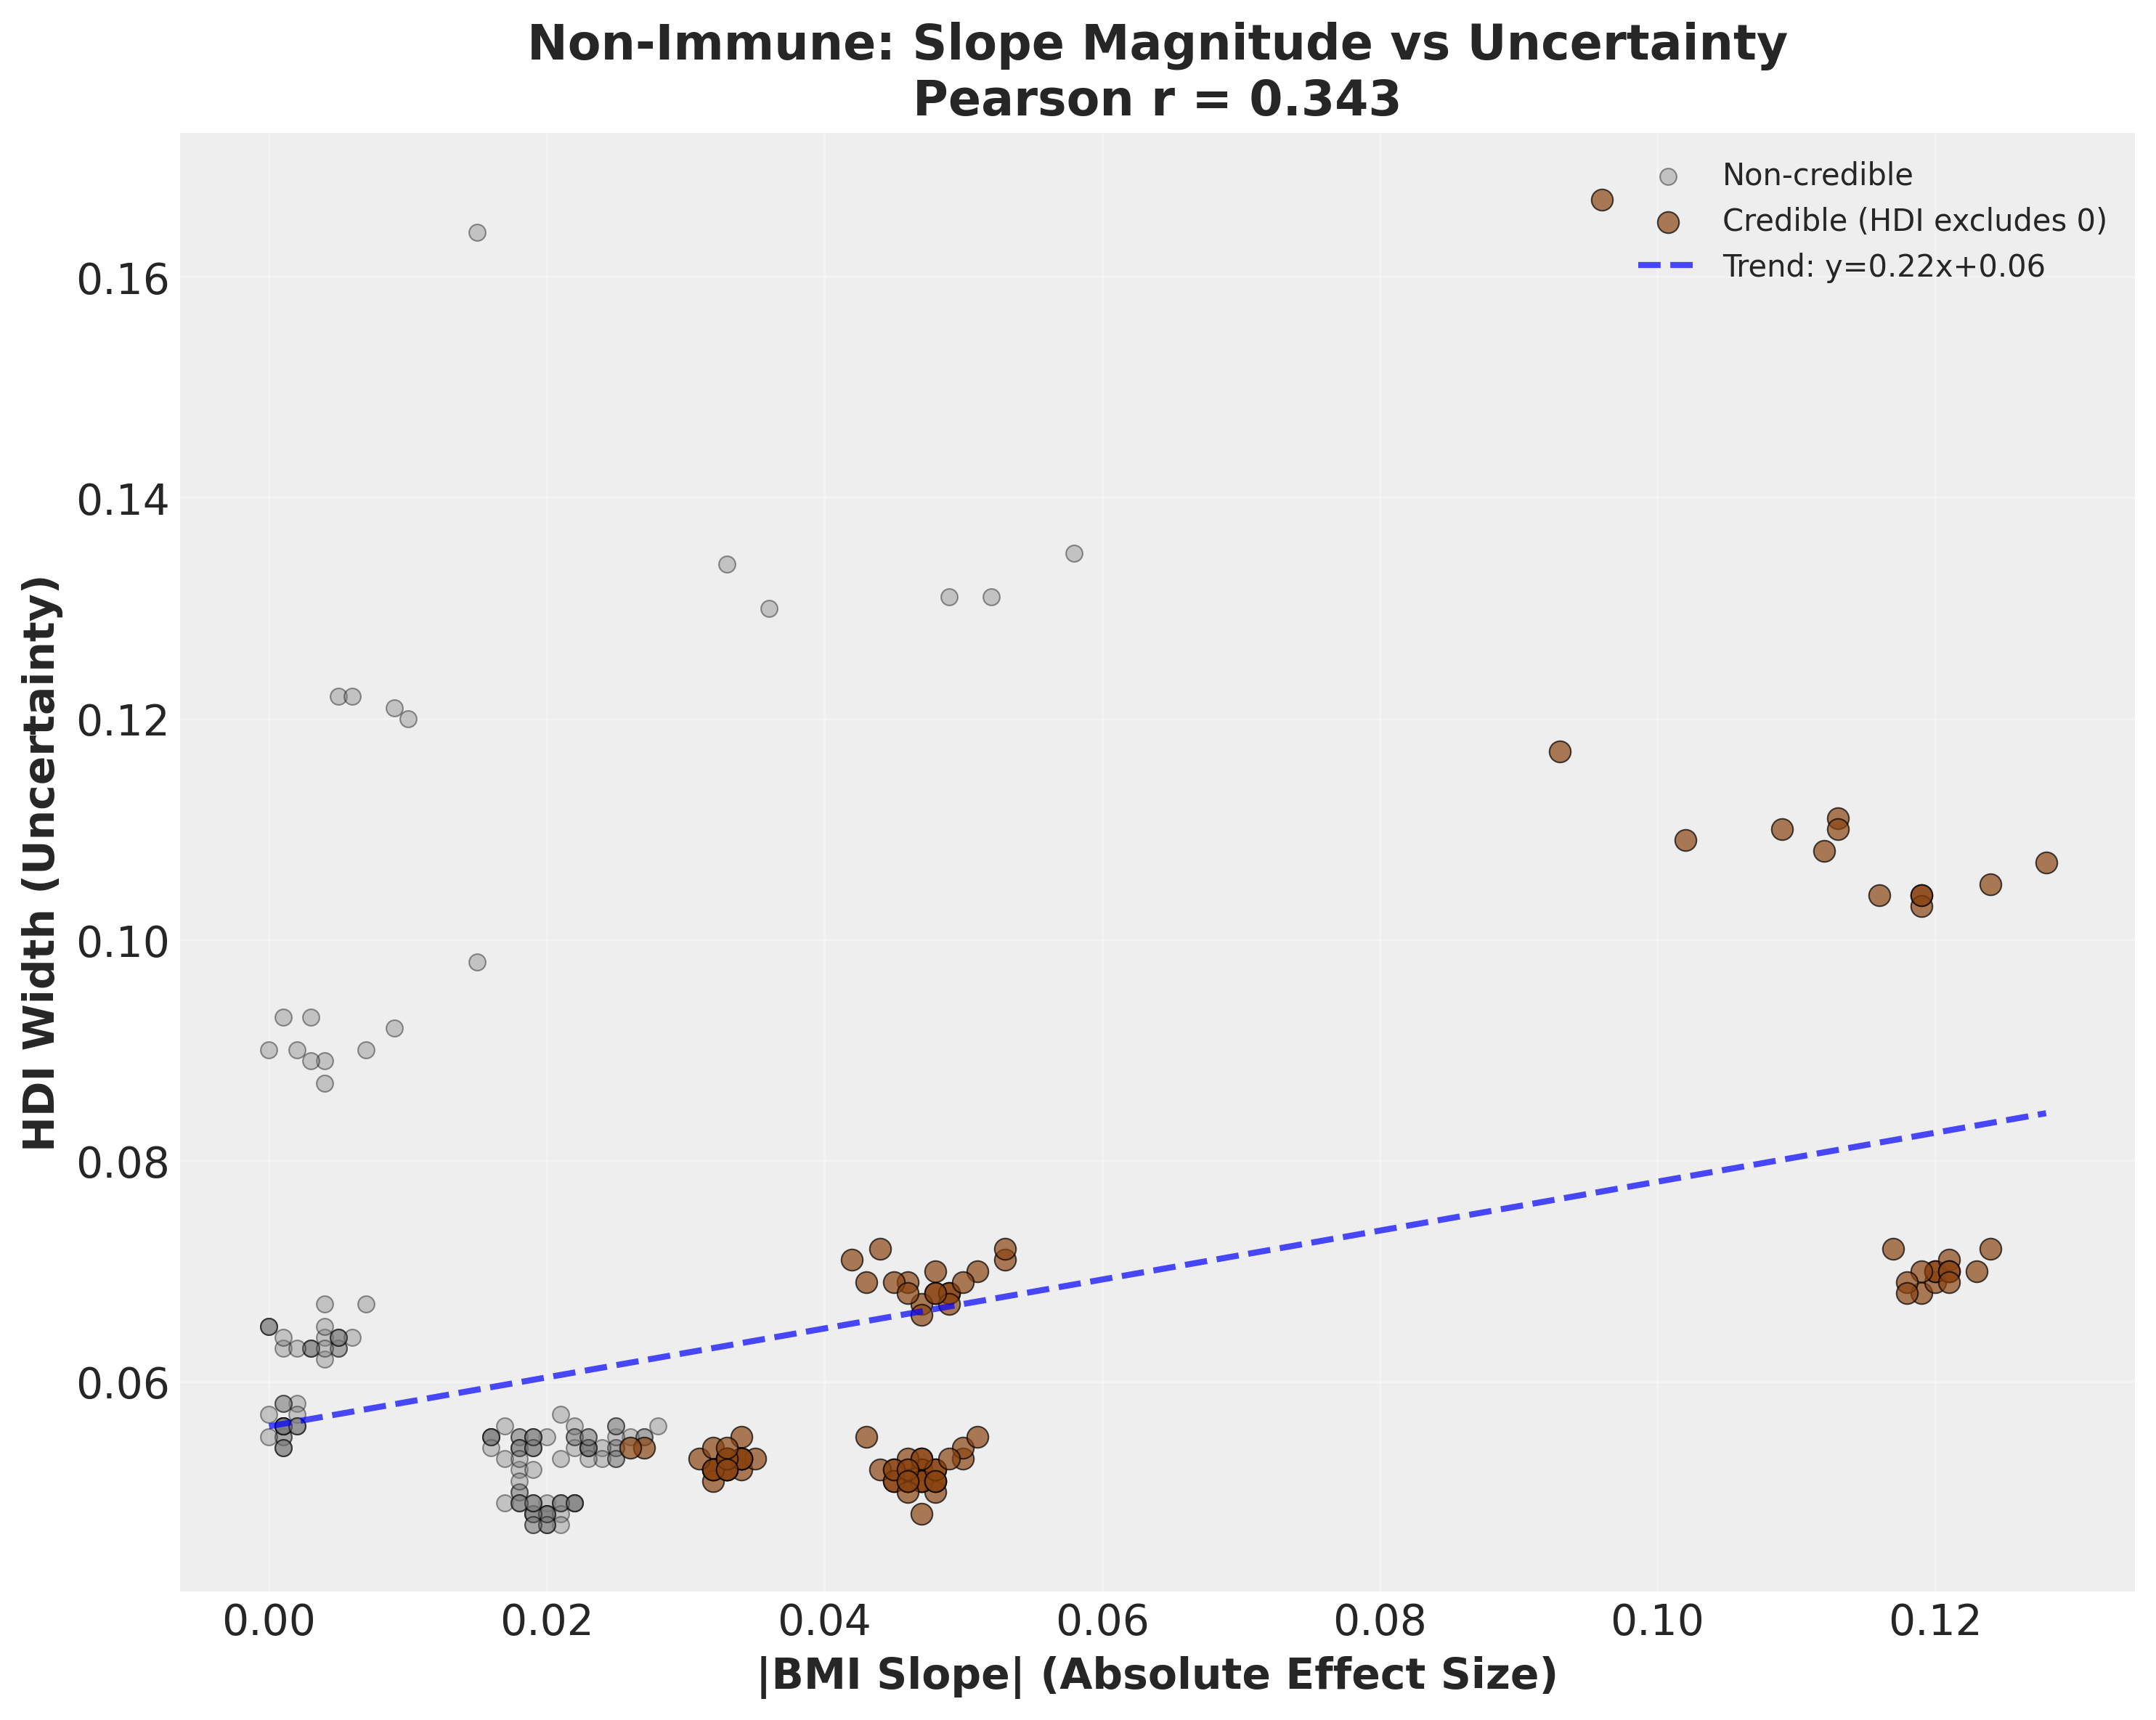


2. SIGNAL-TO-NOISE RATIO ANALYSIS

Signal-to-Noise Ratios:
  Mean SNR: 2.090
  Median SNR: 1.684
  Max SNR: 6.888

Features by signal strength:
  Strong signal (SNR > 2): 102/249 (41.0%)
  Moderate signal (1 < SNR ≤ 2): 89/249 (35.7%)
  Weak signal (SNR ≤ 1): 58/249 (23.3%)

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_quantitative_validation/signal_to_noise_ratio.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/nonimmune/signal_to_noise_ratio.svg


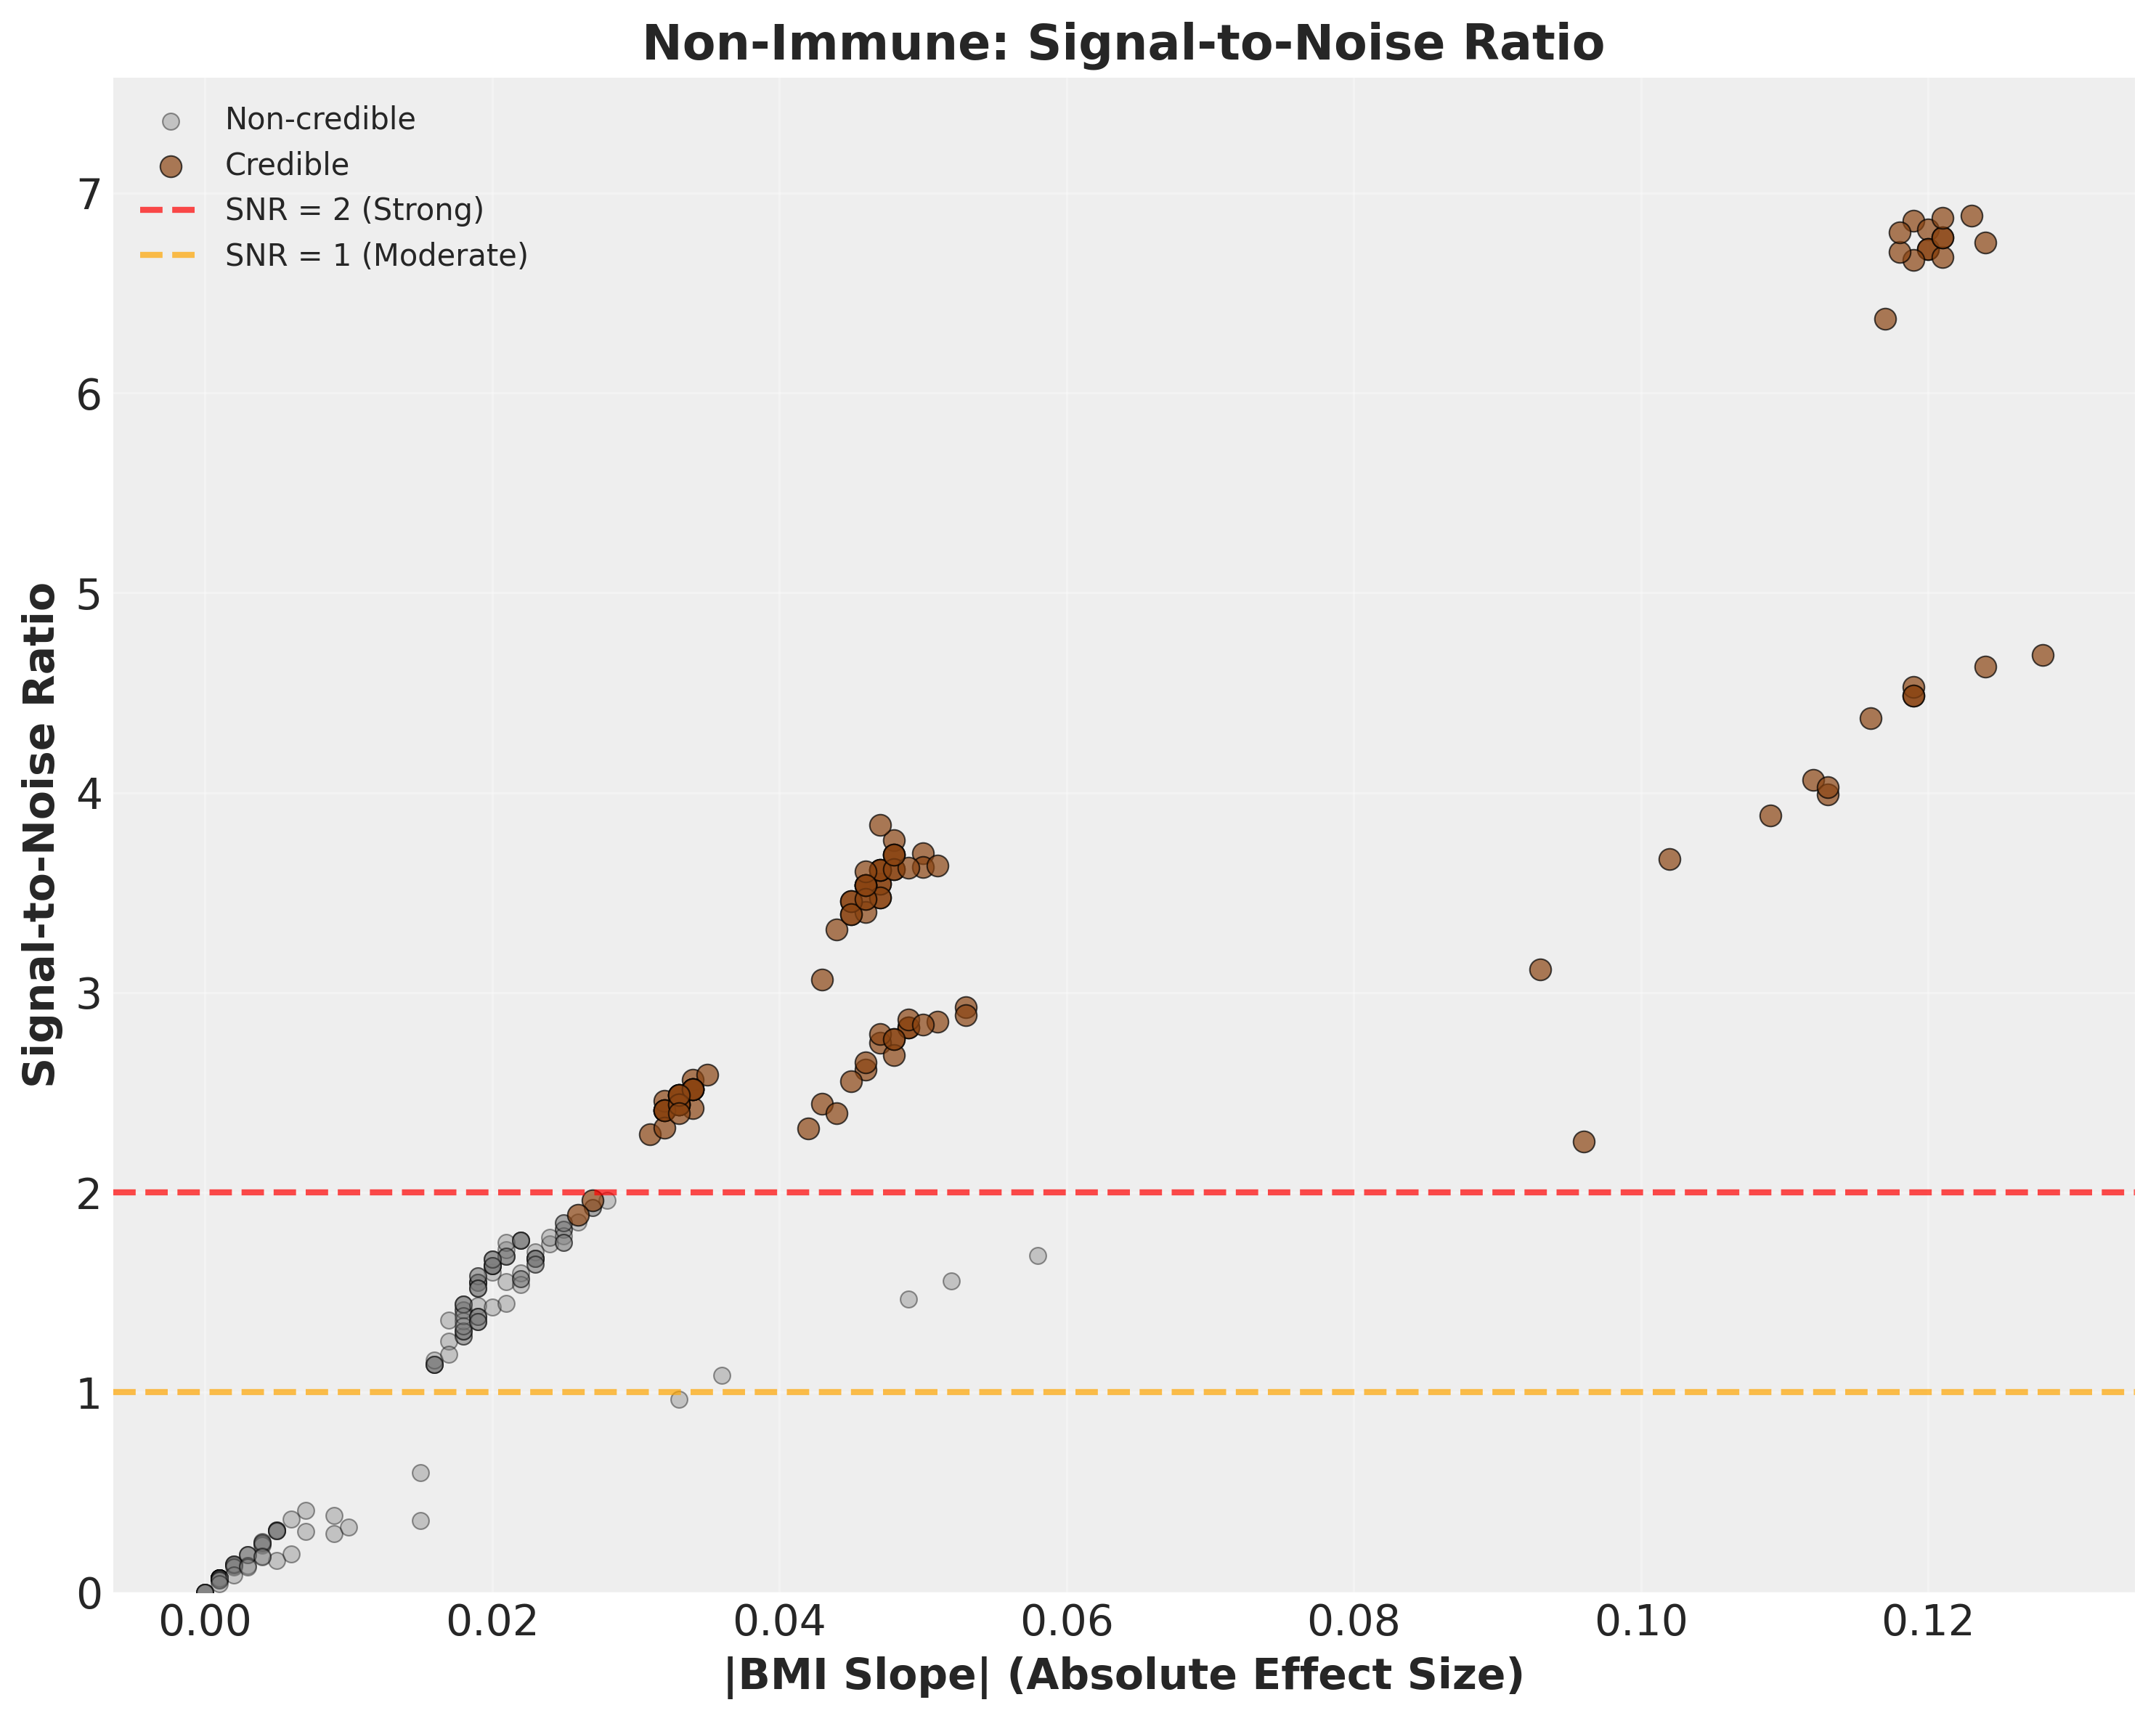


3. EFFECT SIZE DISTRIBUTION

BMI Slope Distribution:
  Mean: 0.0282
  Median: 0.0220
  SD: 0.0380
  Range: [-0.1280, 0.1240]

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_quantitative_validation/effect_size_distribution.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/nonimmune/effect_size_distribution.svg


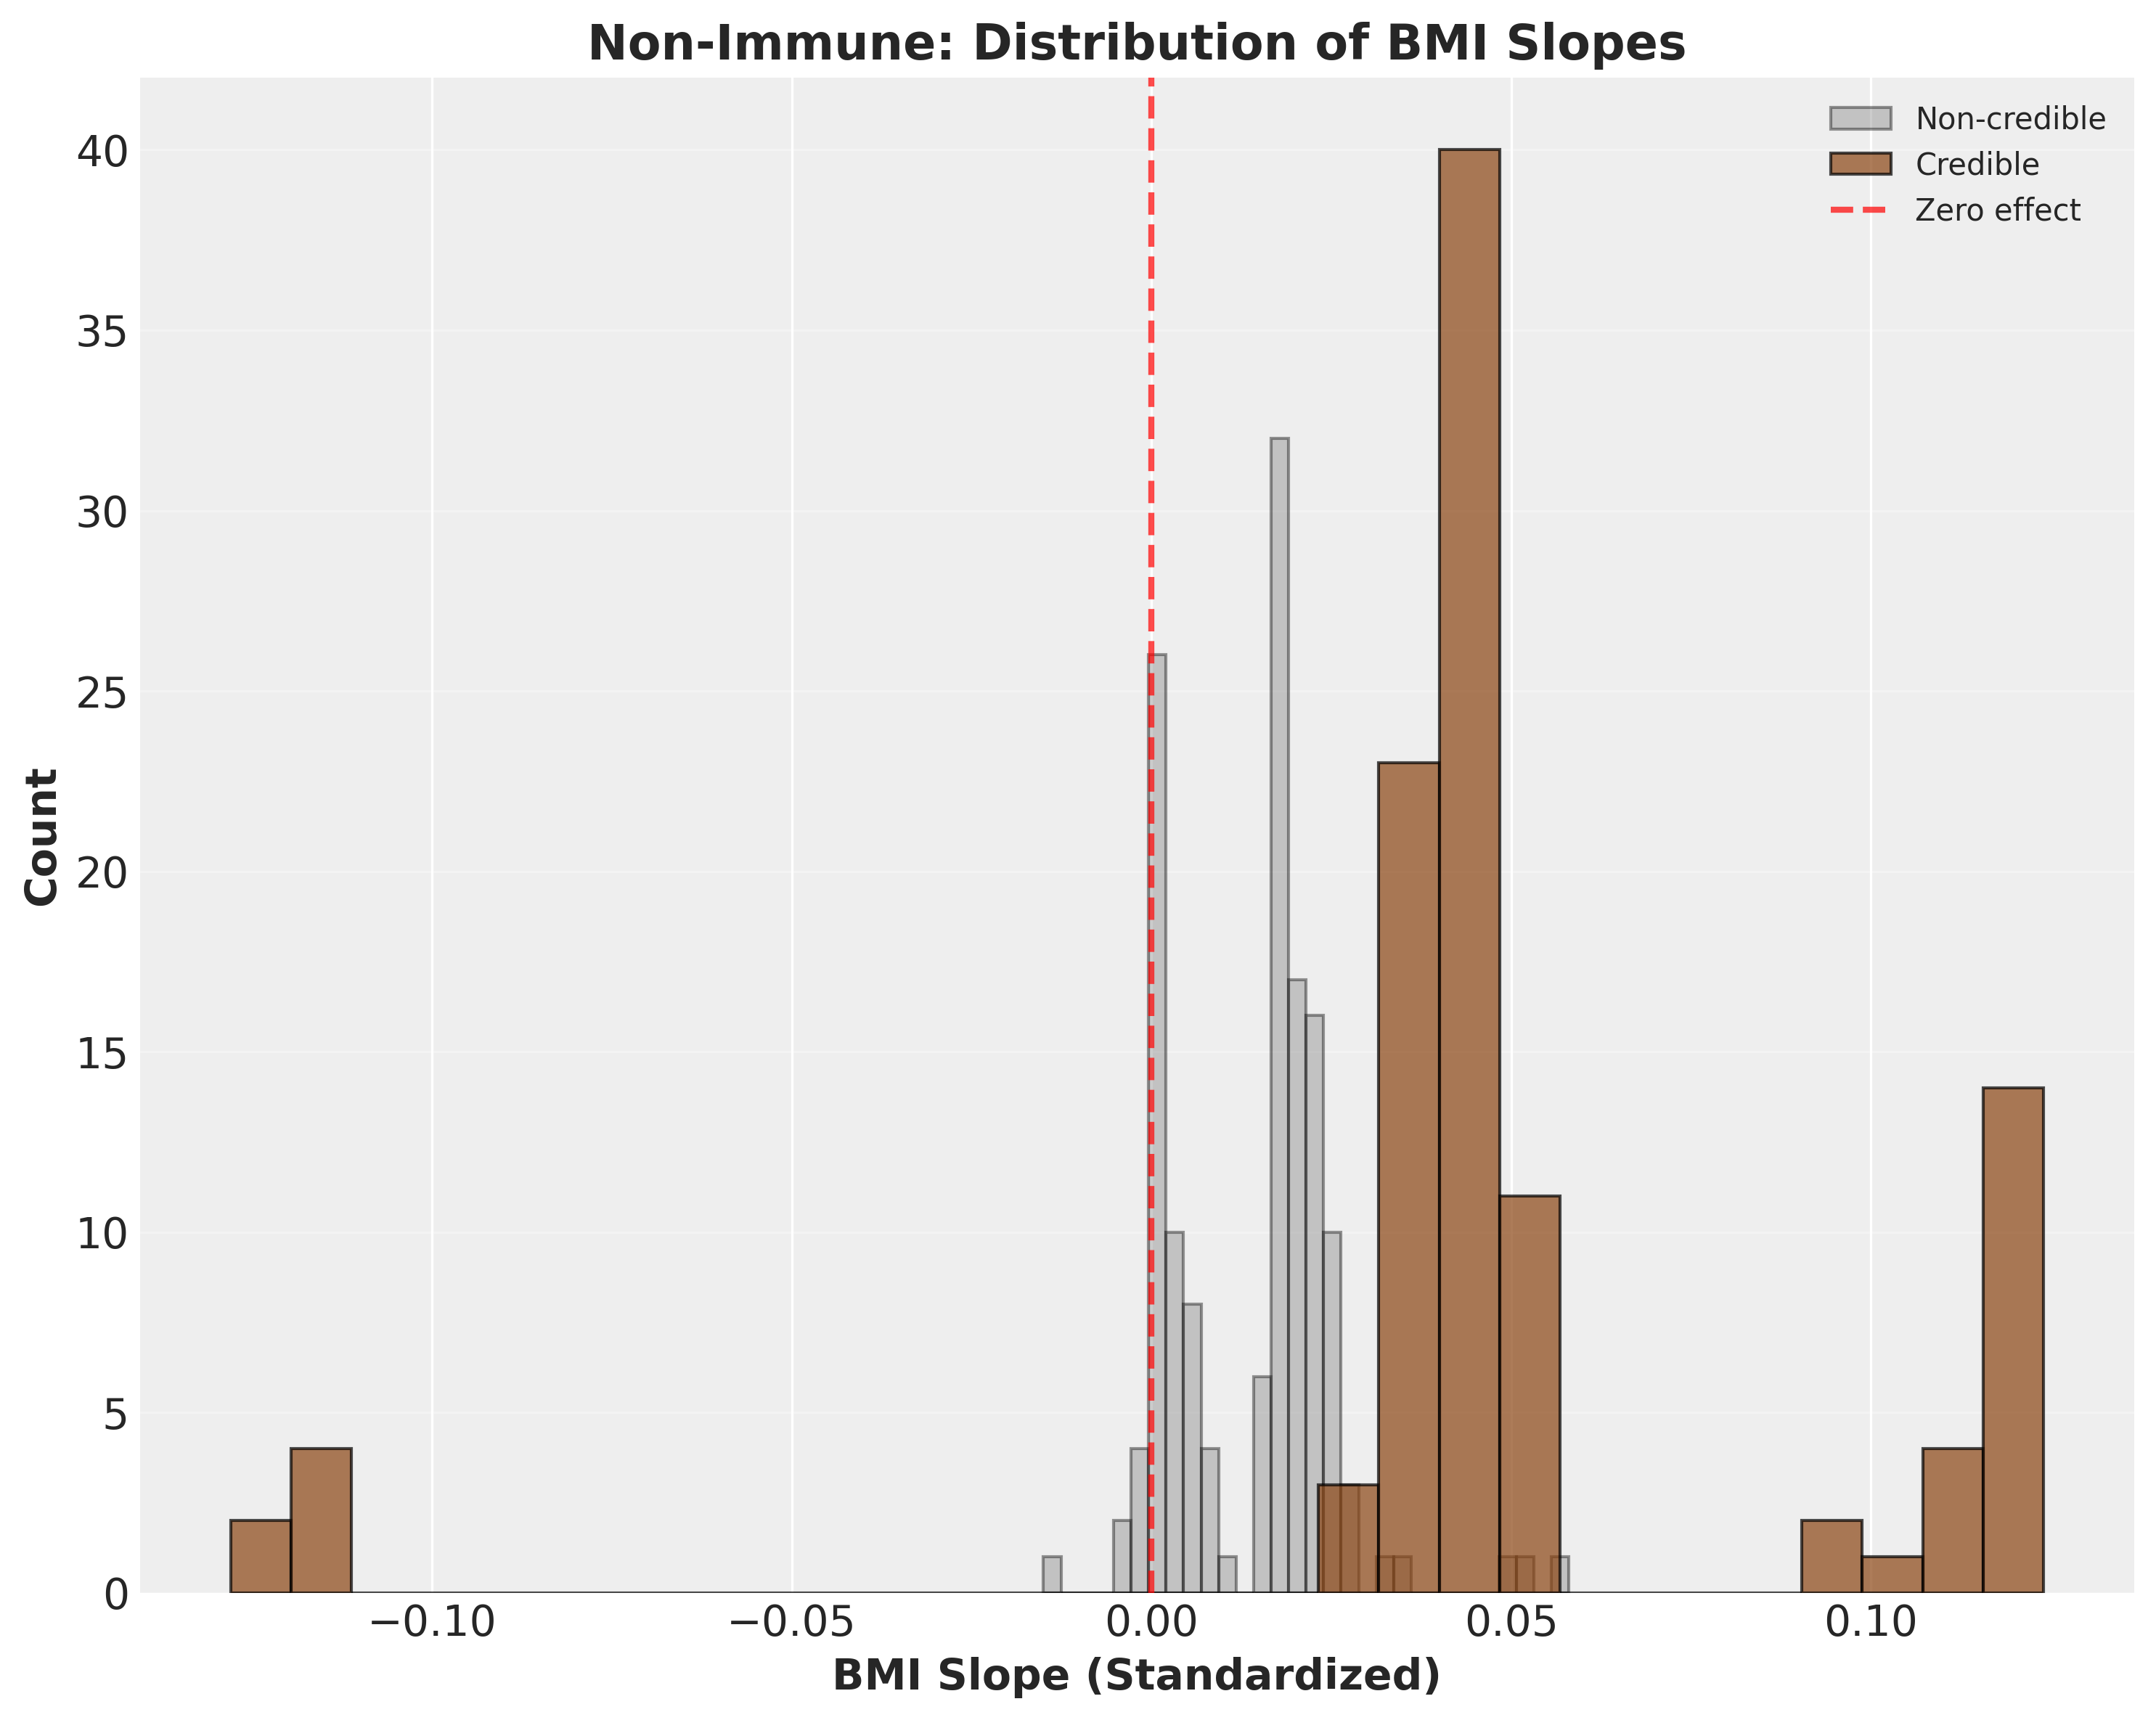


4. PRECISION ANALYSIS

Precision Statistics:
  Mean: 4574.3
  Median: 5079.8
  Range: [551.0, 6956.3]
  High precision (>75th percentile): 55/249

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_quantitative_validation/precision_vs_effect_size.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/nonimmune/precision_vs_effect_size.svg


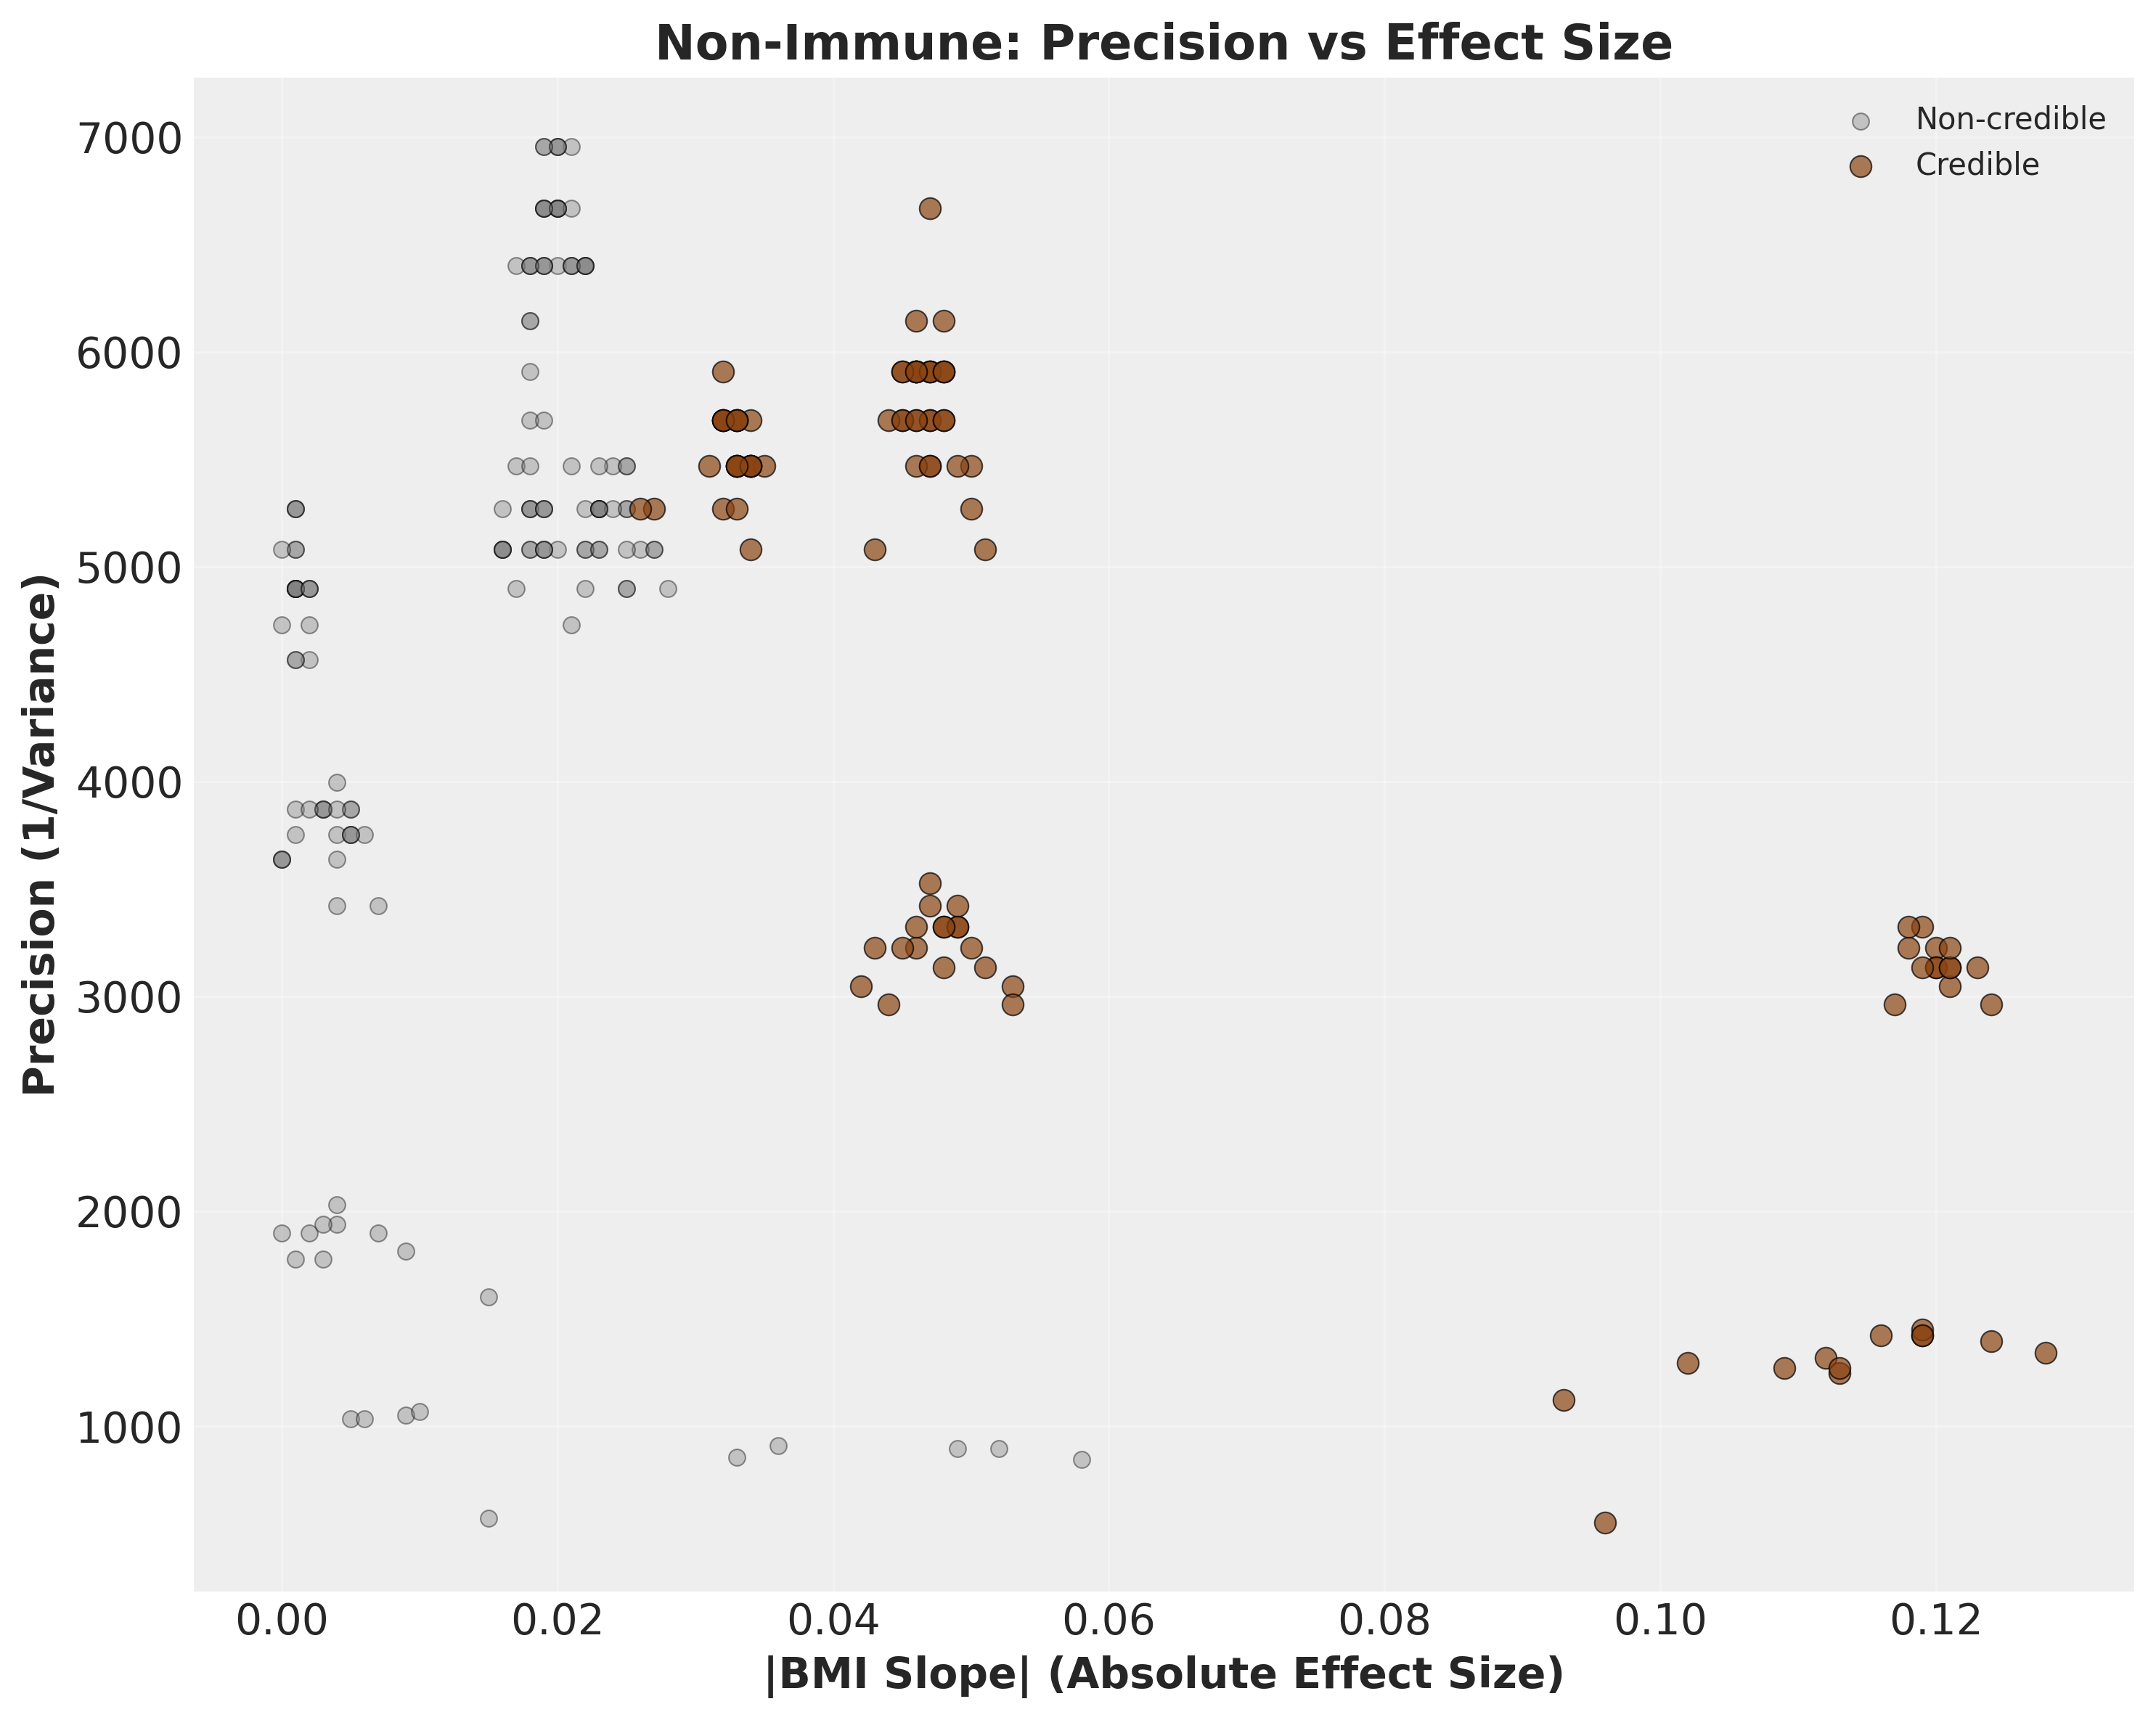


QUANTITATIVE VALIDATION (CONTINUOUS BMI): Non-Immune

SLOPE MAGNITUDE vs UNCERTAINTY:
  Pearson: r = 0.343, p = 2.86e-08
  Spearman: ρ = 0.075, p = 2.40e-01
  Interpretation: Positive relationship

SIGNAL-TO-NOISE RATIO:
  Mean SNR: 2.090
  Median SNR: 1.684
  Strong signals (SNR>2): 102/249 (41.0%)
  Moderate signals (1<SNR≤2): 89/249 (35.7%)

EFFECT SIZE DISTRIBUTION:
  Mean slope: 0.0282
  Median slope: 0.0220
  SD: 0.0380

CREDIBILITY:
  Credible effects: 104/249 (41.8%)
  Positive slopes: 98 (39.4%)
  Negative slopes: 6 (2.4%)

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_quantitative_validation/validation_summary_continuous.txt
💾 Saved (SVG dir): /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/nonimmune/validation_summary_continuous.txt

✅ FINISHED: Non-Immune

QUANTITATIVE VALIDATION (CONTINUOUS BMI): Immune Fine

Loading results: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_c

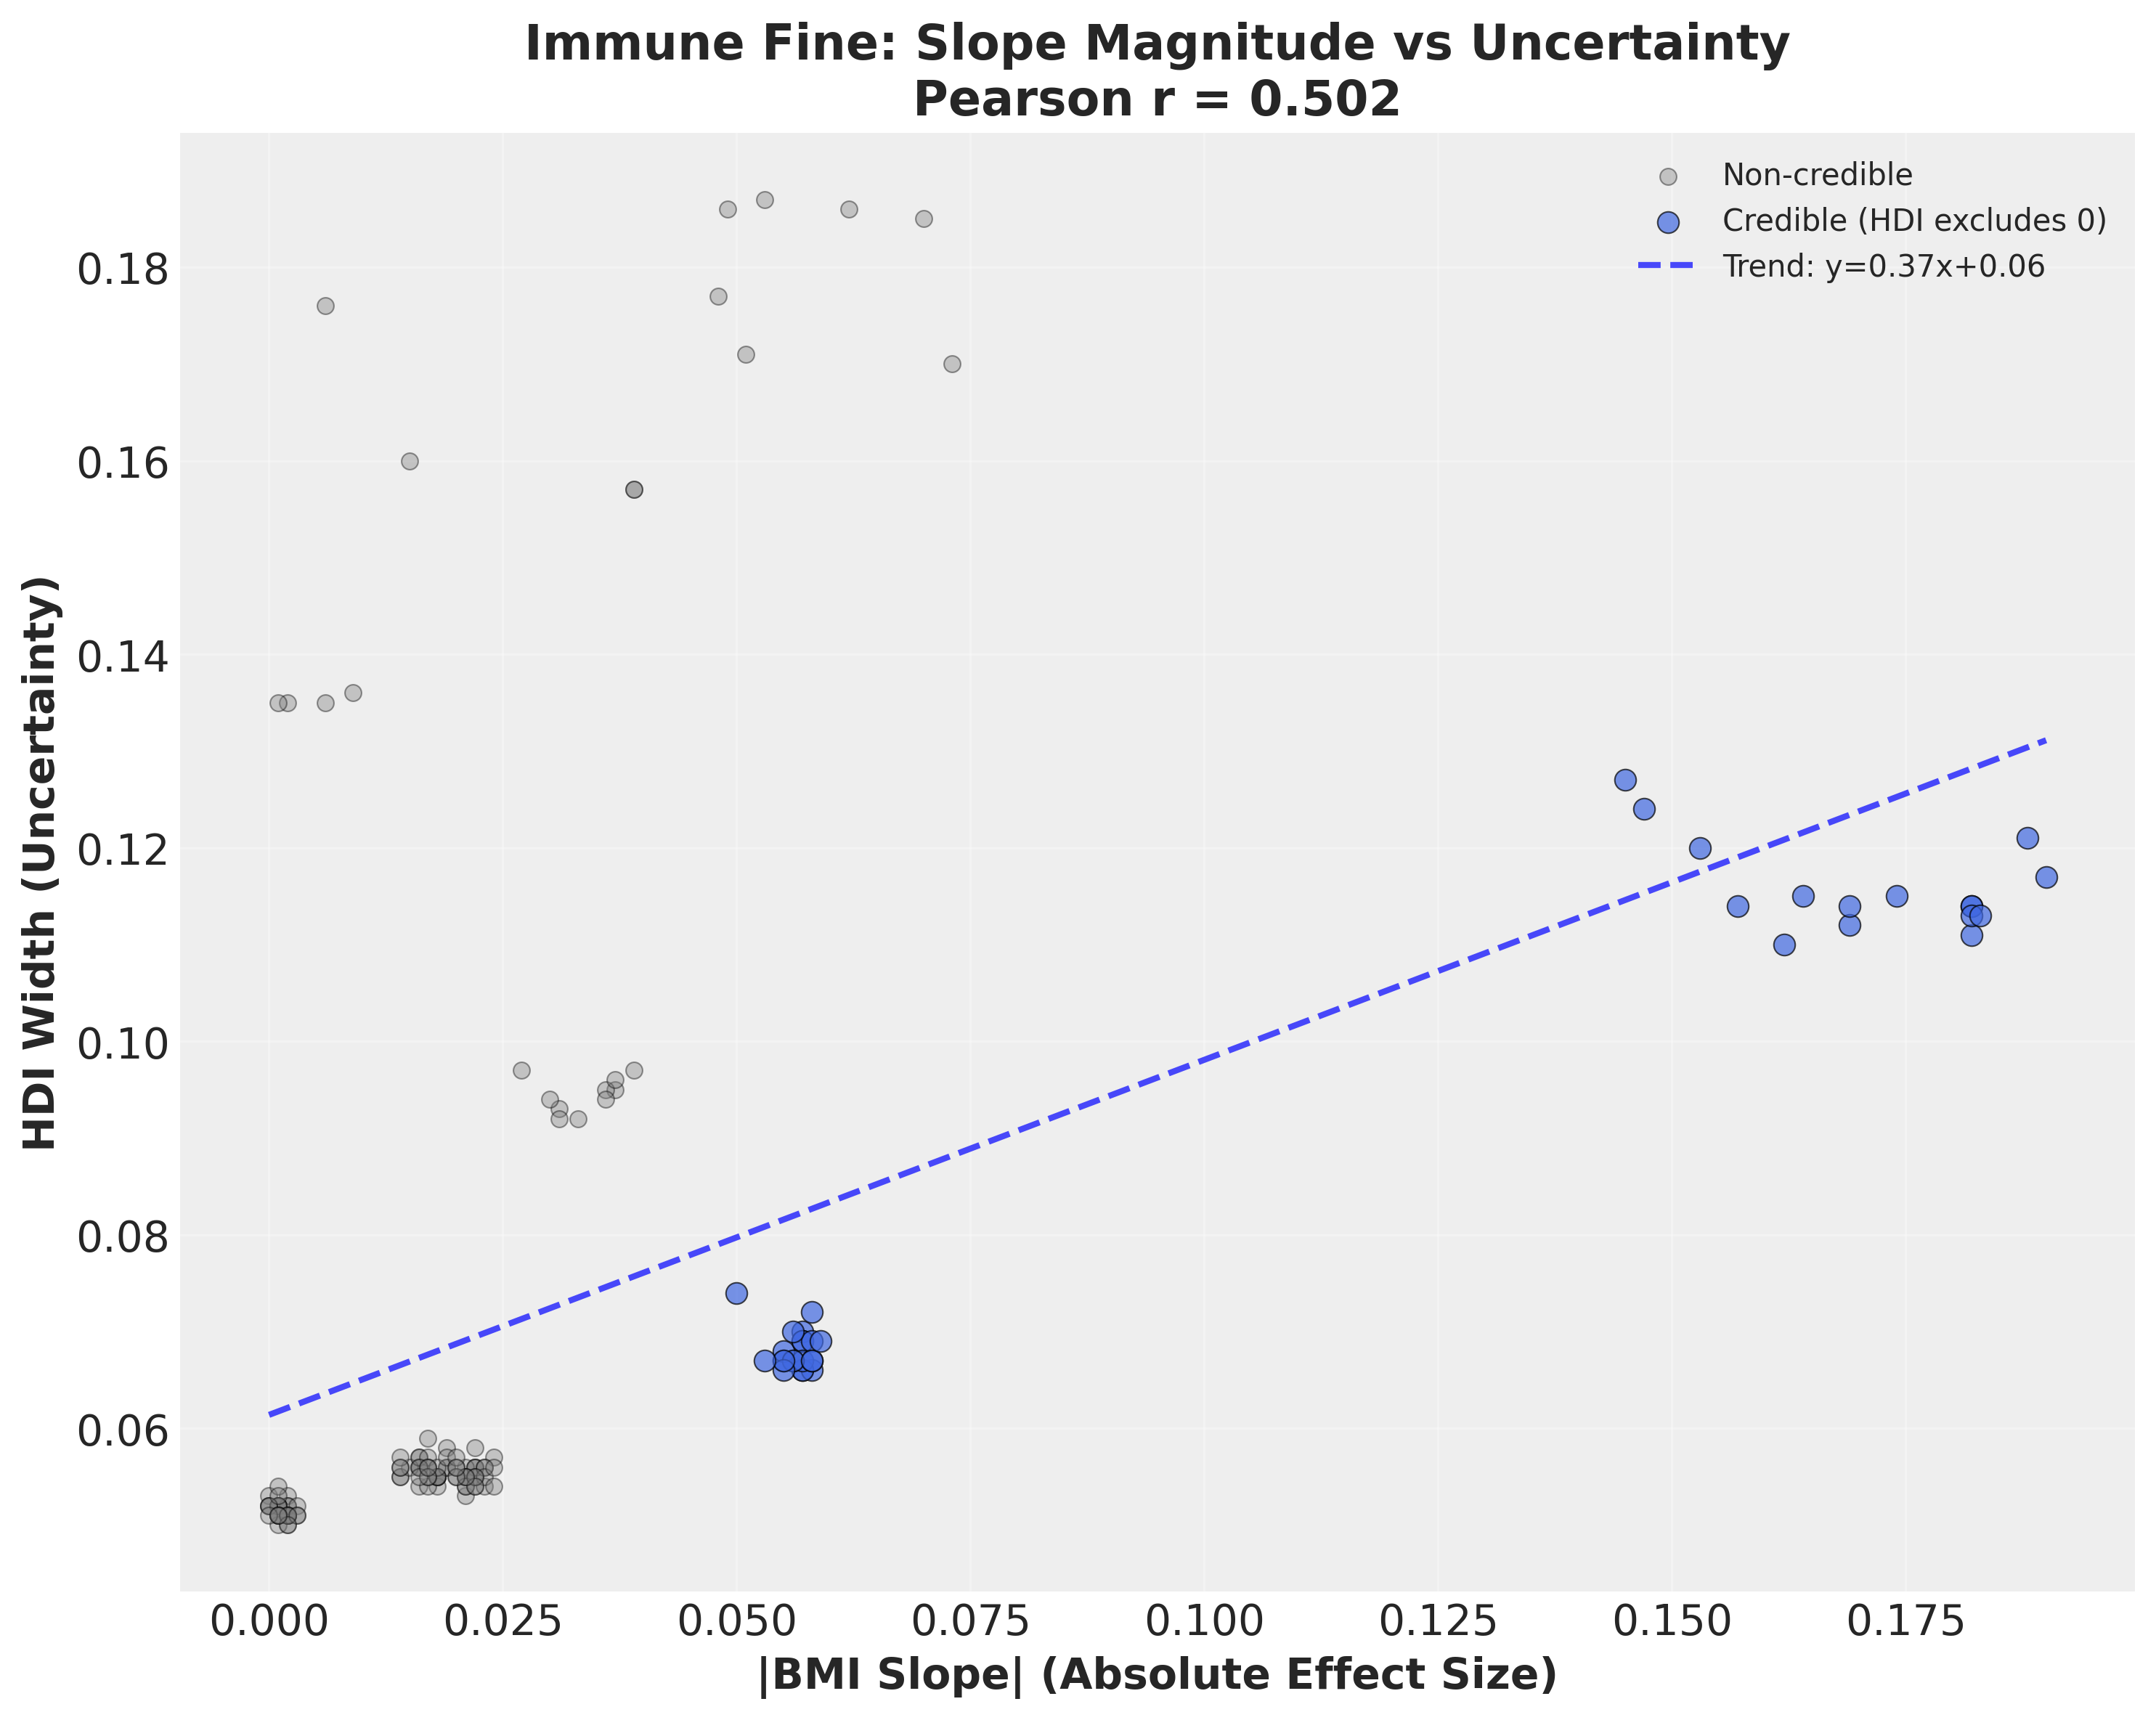


2. SIGNAL-TO-NOISE RATIO ANALYSIS

Signal-to-Noise Ratios:
  Mean SNR: 1.746
  Median SNR: 1.307
  Max SNR: 6.427

Features by signal strength:
  Strong signal (SNR > 2): 37/156 (23.7%)
  Moderate signal (1 < SNR ≤ 2): 73/156 (46.8%)
  Weak signal (SNR ≤ 1): 46/156 (29.5%)

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_quantitative_validation/signal_to_noise_ratio.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/immune_fine/signal_to_noise_ratio.svg


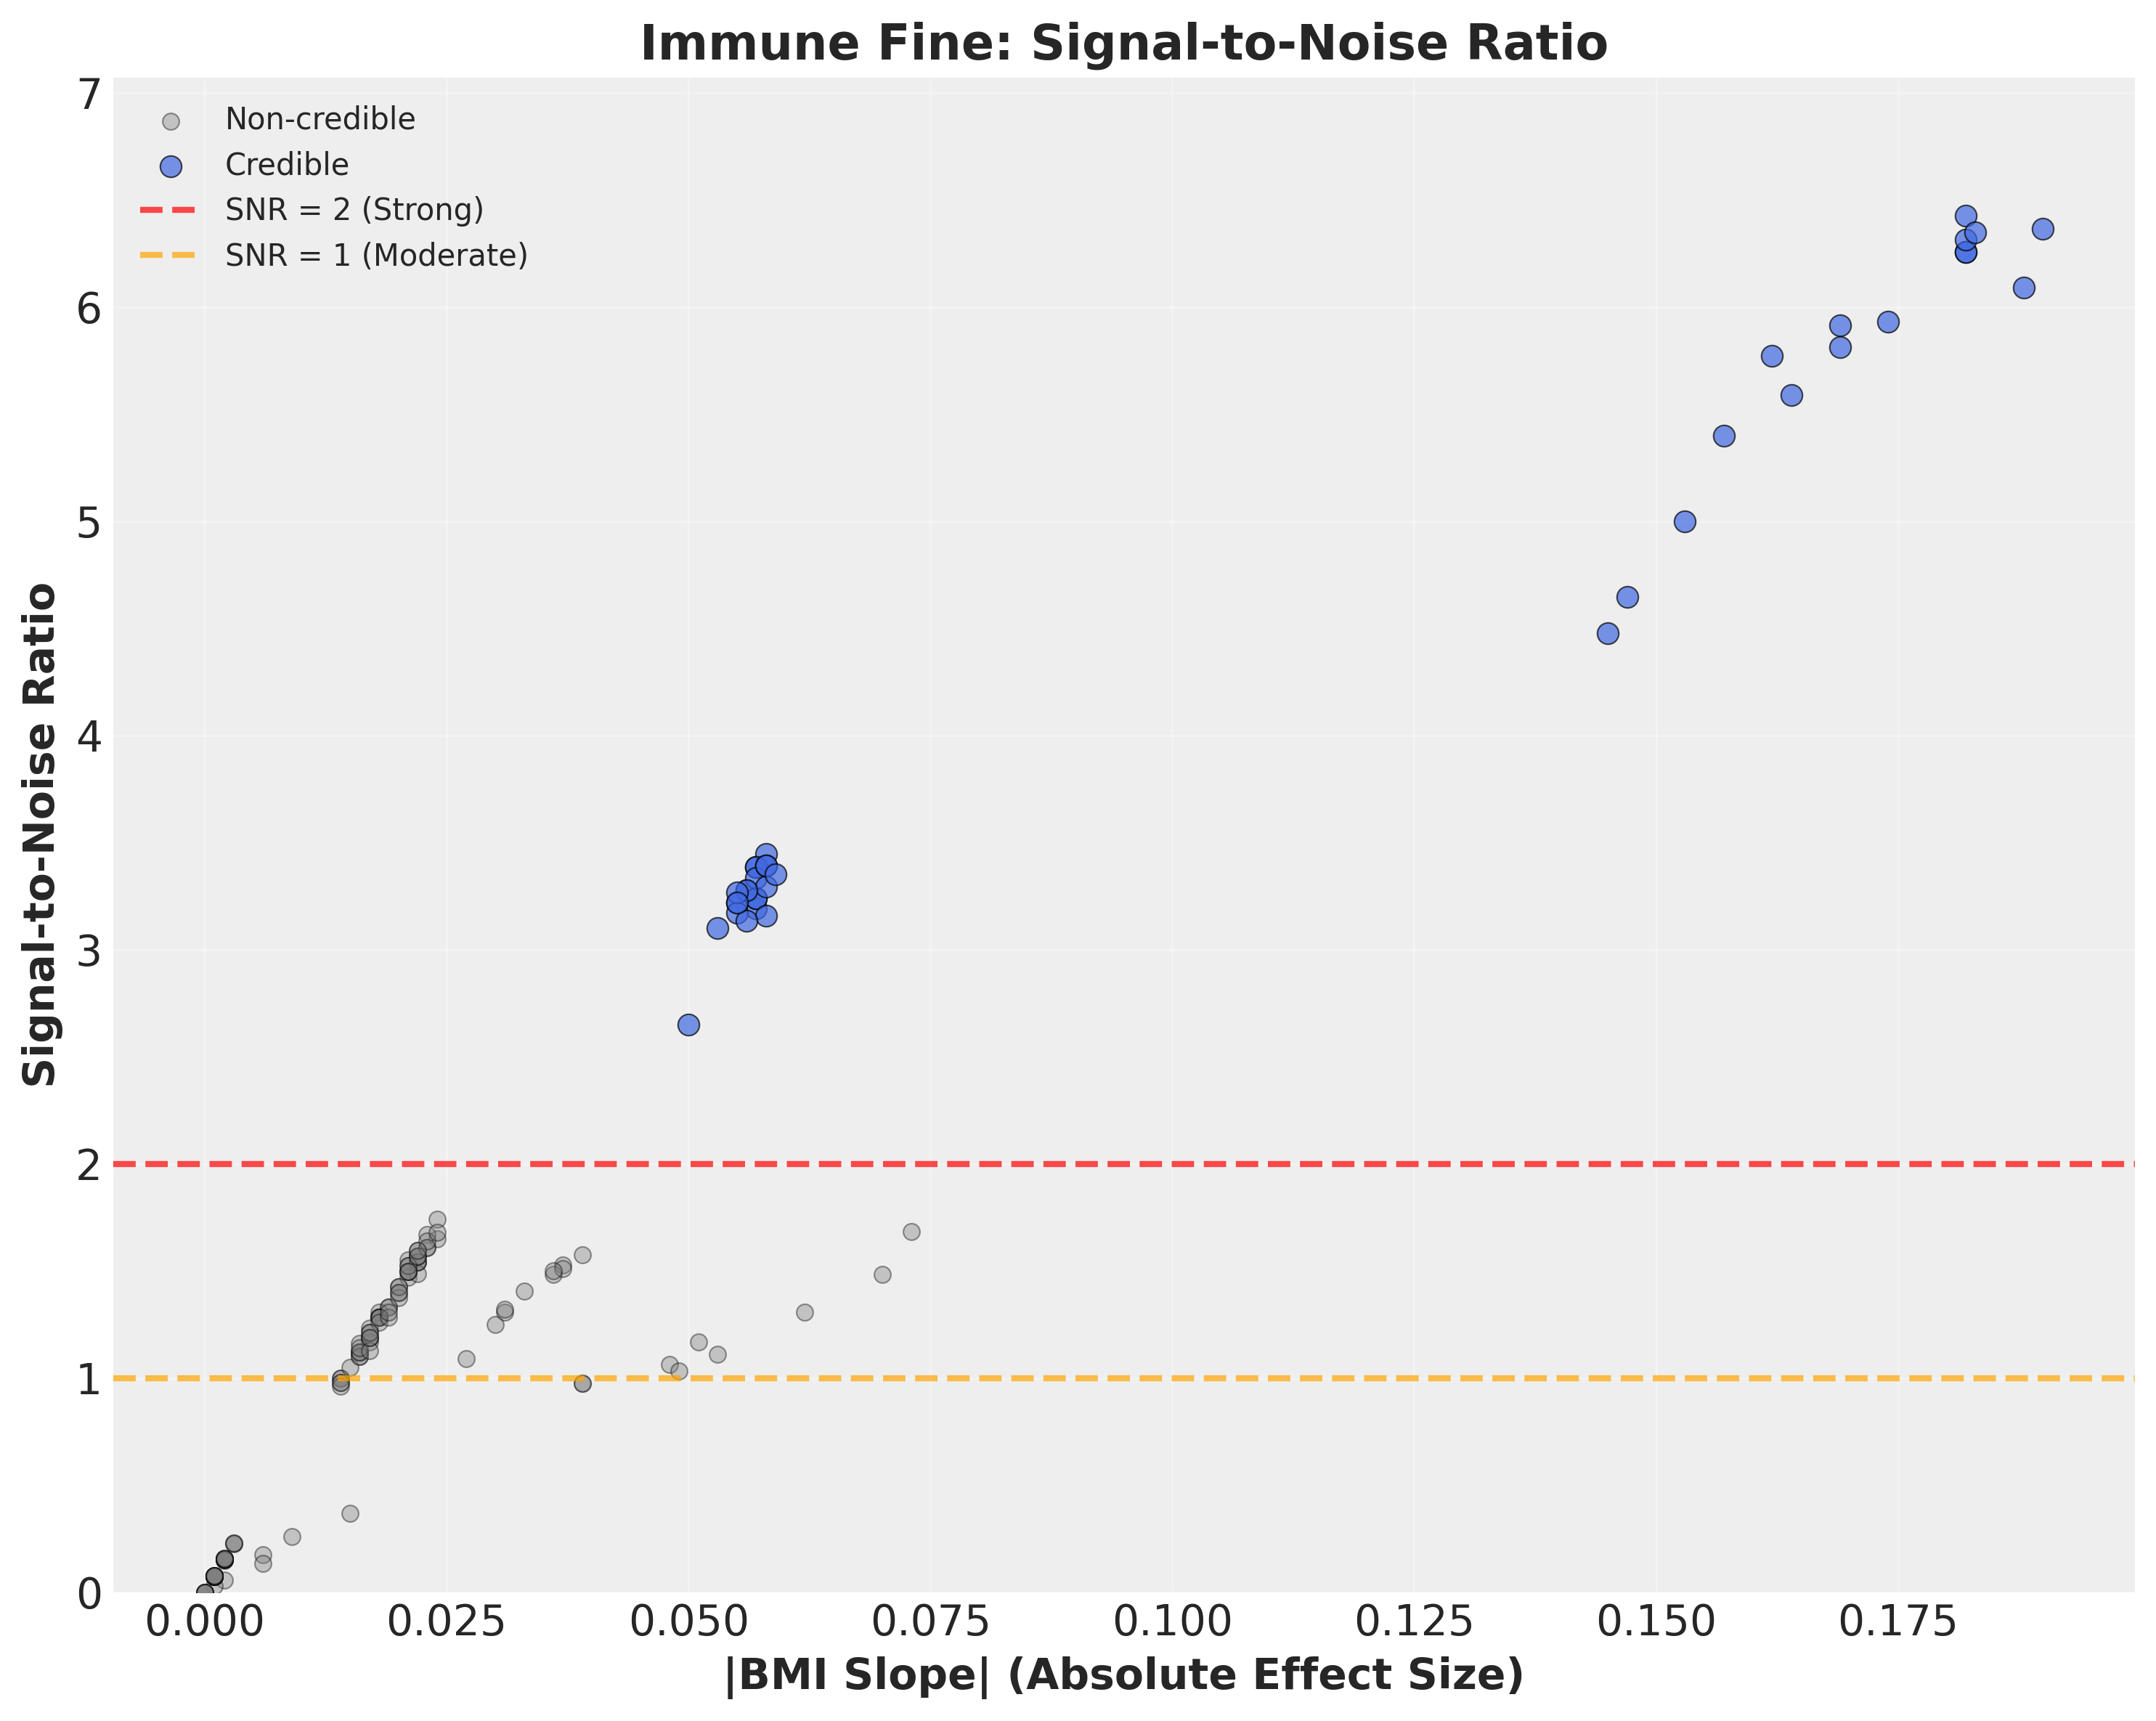


3. EFFECT SIZE DISTRIBUTION

BMI Slope Distribution:
  Mean: 0.0358
  Median: 0.0200
  SD: 0.0505
  Range: [-0.0730, 0.1900]

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_quantitative_validation/effect_size_distribution.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/immune_fine/effect_size_distribution.svg


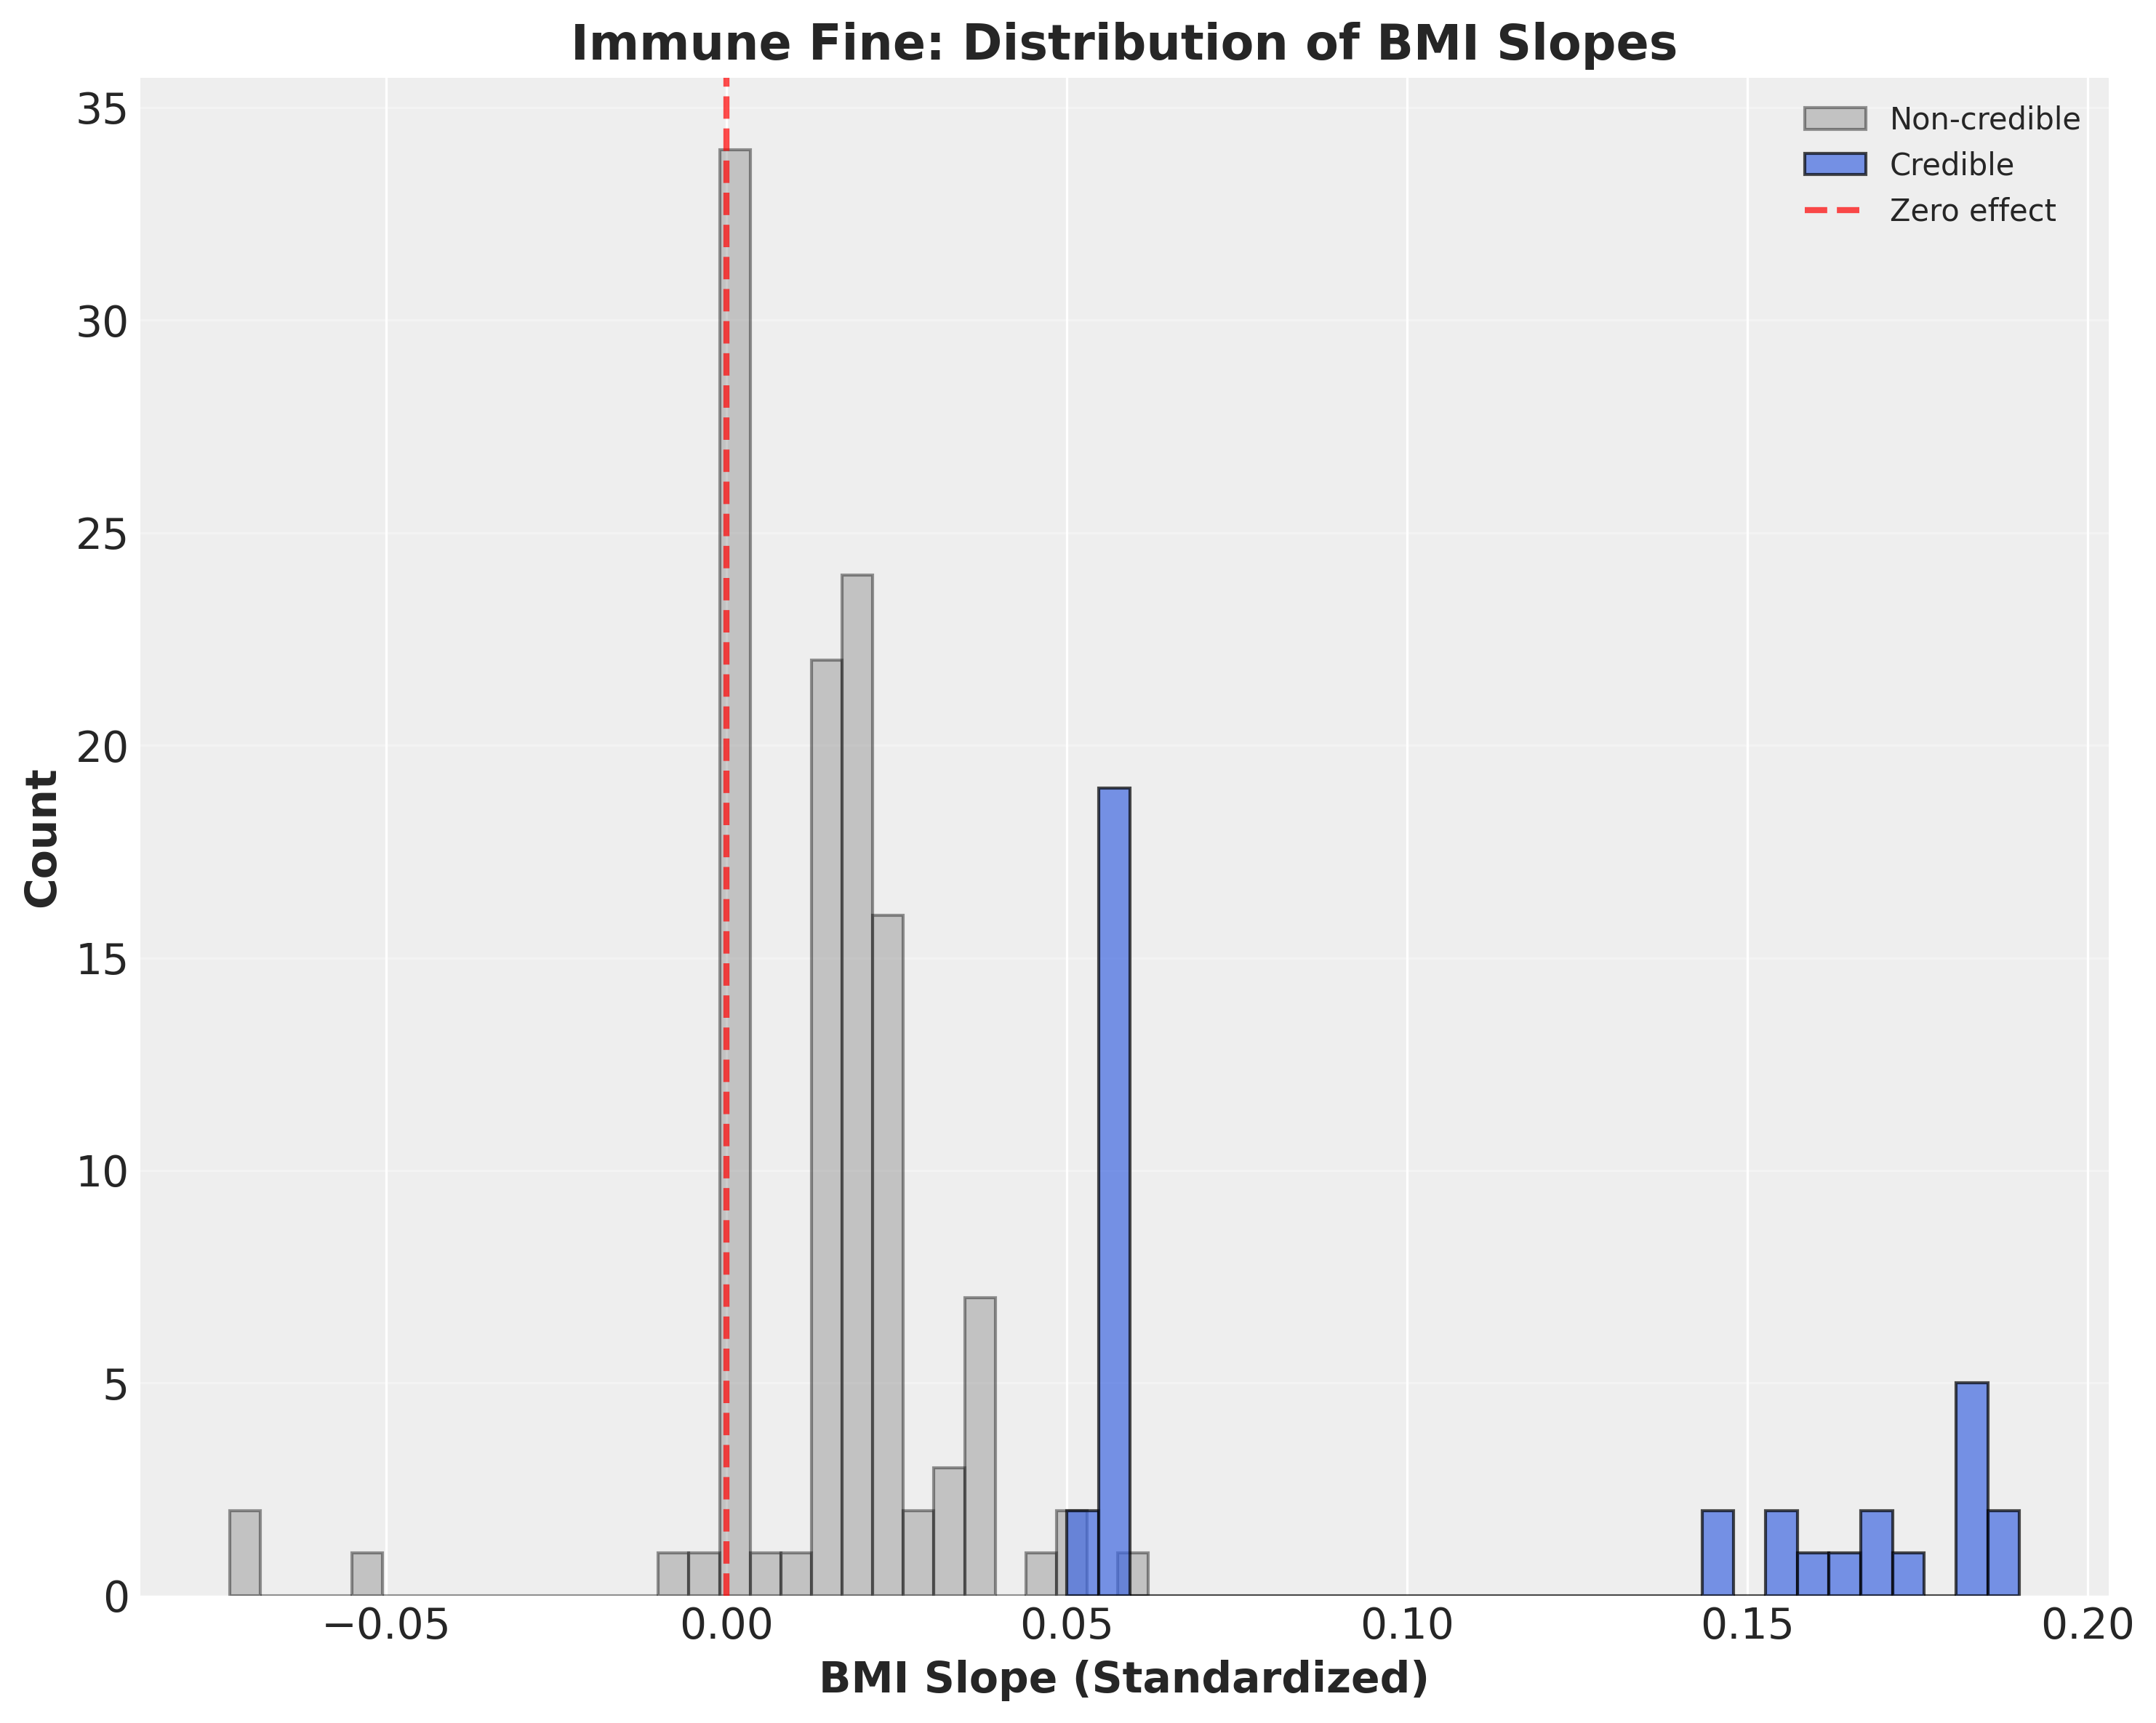


4. PRECISION ANALYSIS

Precision Statistics:
  Mean: 3908.5
  Median: 4900.0
  Range: [439.4, 6146.6]
  High precision (>75th percentile): 34/156

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_quantitative_validation/precision_vs_effect_size.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/immune_fine/precision_vs_effect_size.svg


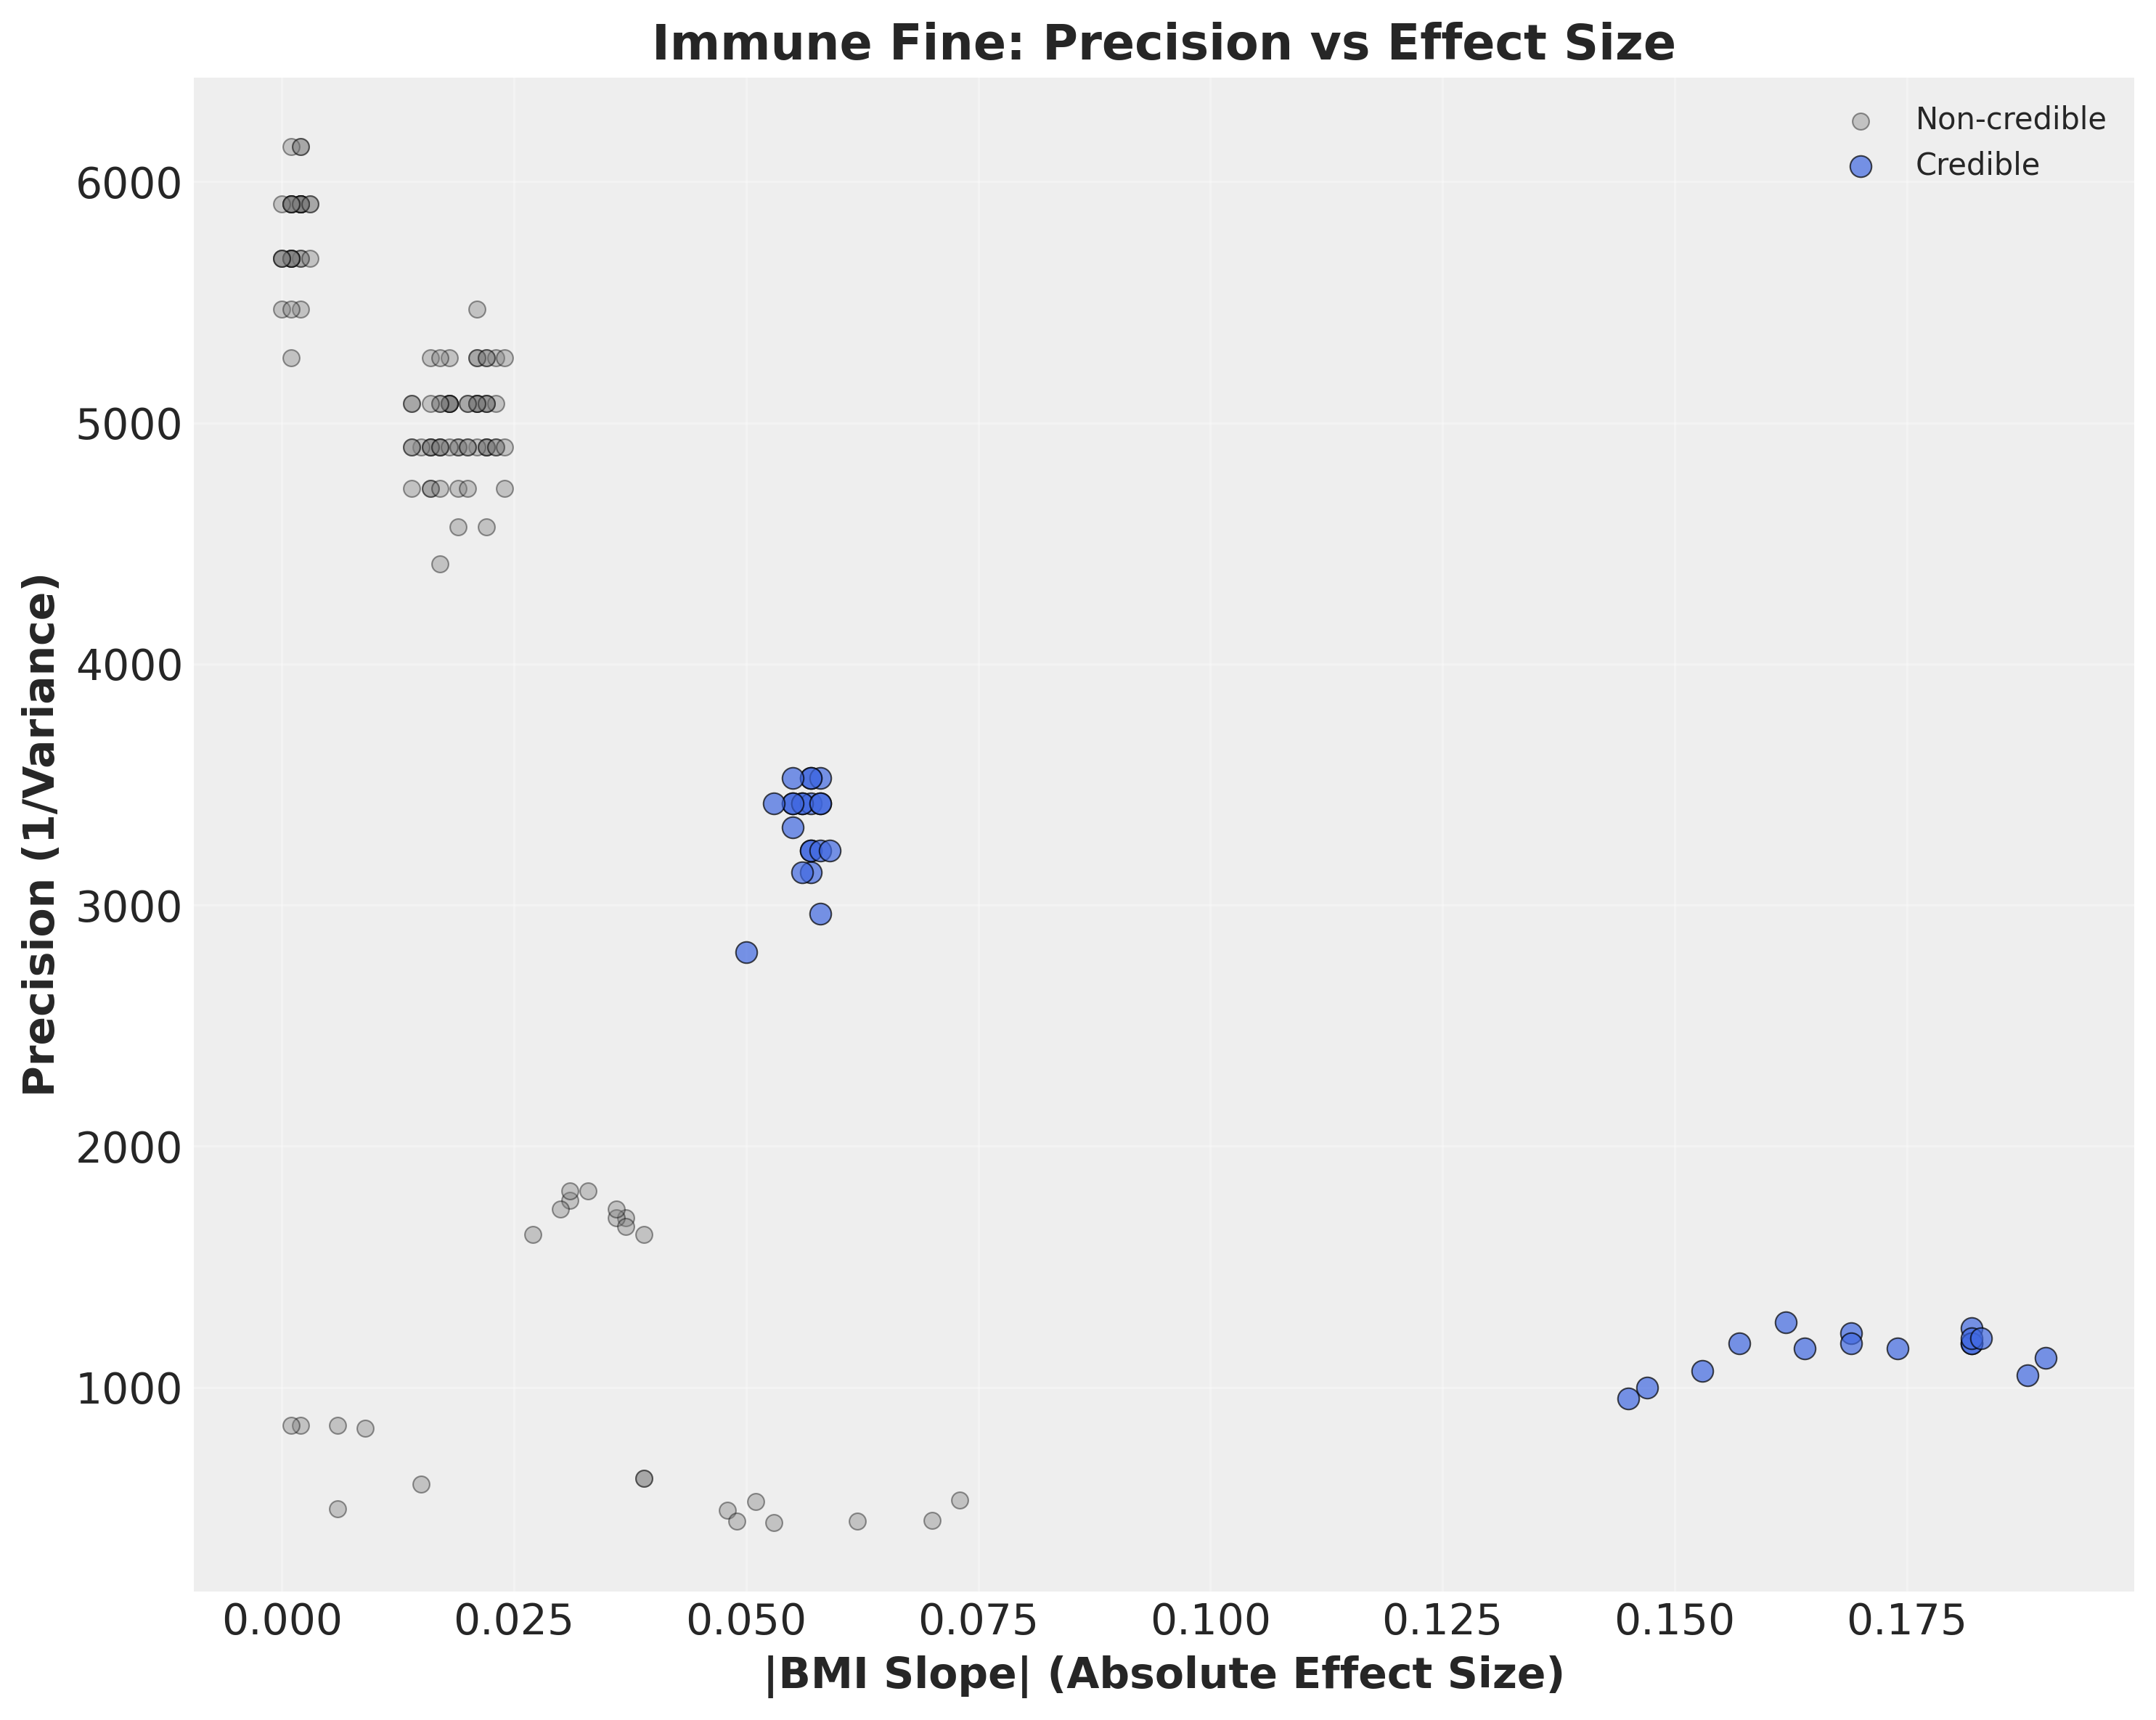


QUANTITATIVE VALIDATION (CONTINUOUS BMI): Immune Fine

SLOPE MAGNITUDE vs UNCERTAINTY:
  Pearson: r = 0.502, p = 2.48e-11
  Spearman: ρ = 0.749, p = 2.48e-29
  Interpretation: Positive relationship

SIGNAL-TO-NOISE RATIO:
  Mean SNR: 1.746
  Median SNR: 1.307
  Strong signals (SNR>2): 37/156 (23.7%)
  Moderate signals (1<SNR≤2): 73/156 (46.8%)

EFFECT SIZE DISTRIBUTION:
  Mean slope: 0.0358
  Median slope: 0.0200
  SD: 0.0505

CREDIBILITY:
  Credible effects: 37/156 (23.7%)
  Positive slopes: 37 (23.7%)
  Negative slopes: 0 (0.0%)

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_quantitative_validation/validation_summary_continuous.txt
💾 Saved (SVG dir): /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/immune_fine/validation_summary_continuous.txt

✅ FINISHED: Immune Fine

QUANTITATIVE VALIDATION (CONTINUOUS BMI): Immune Coarse

Loading results: /content/drive/MyDrive/new_dysfunction/bayesian_hierarch

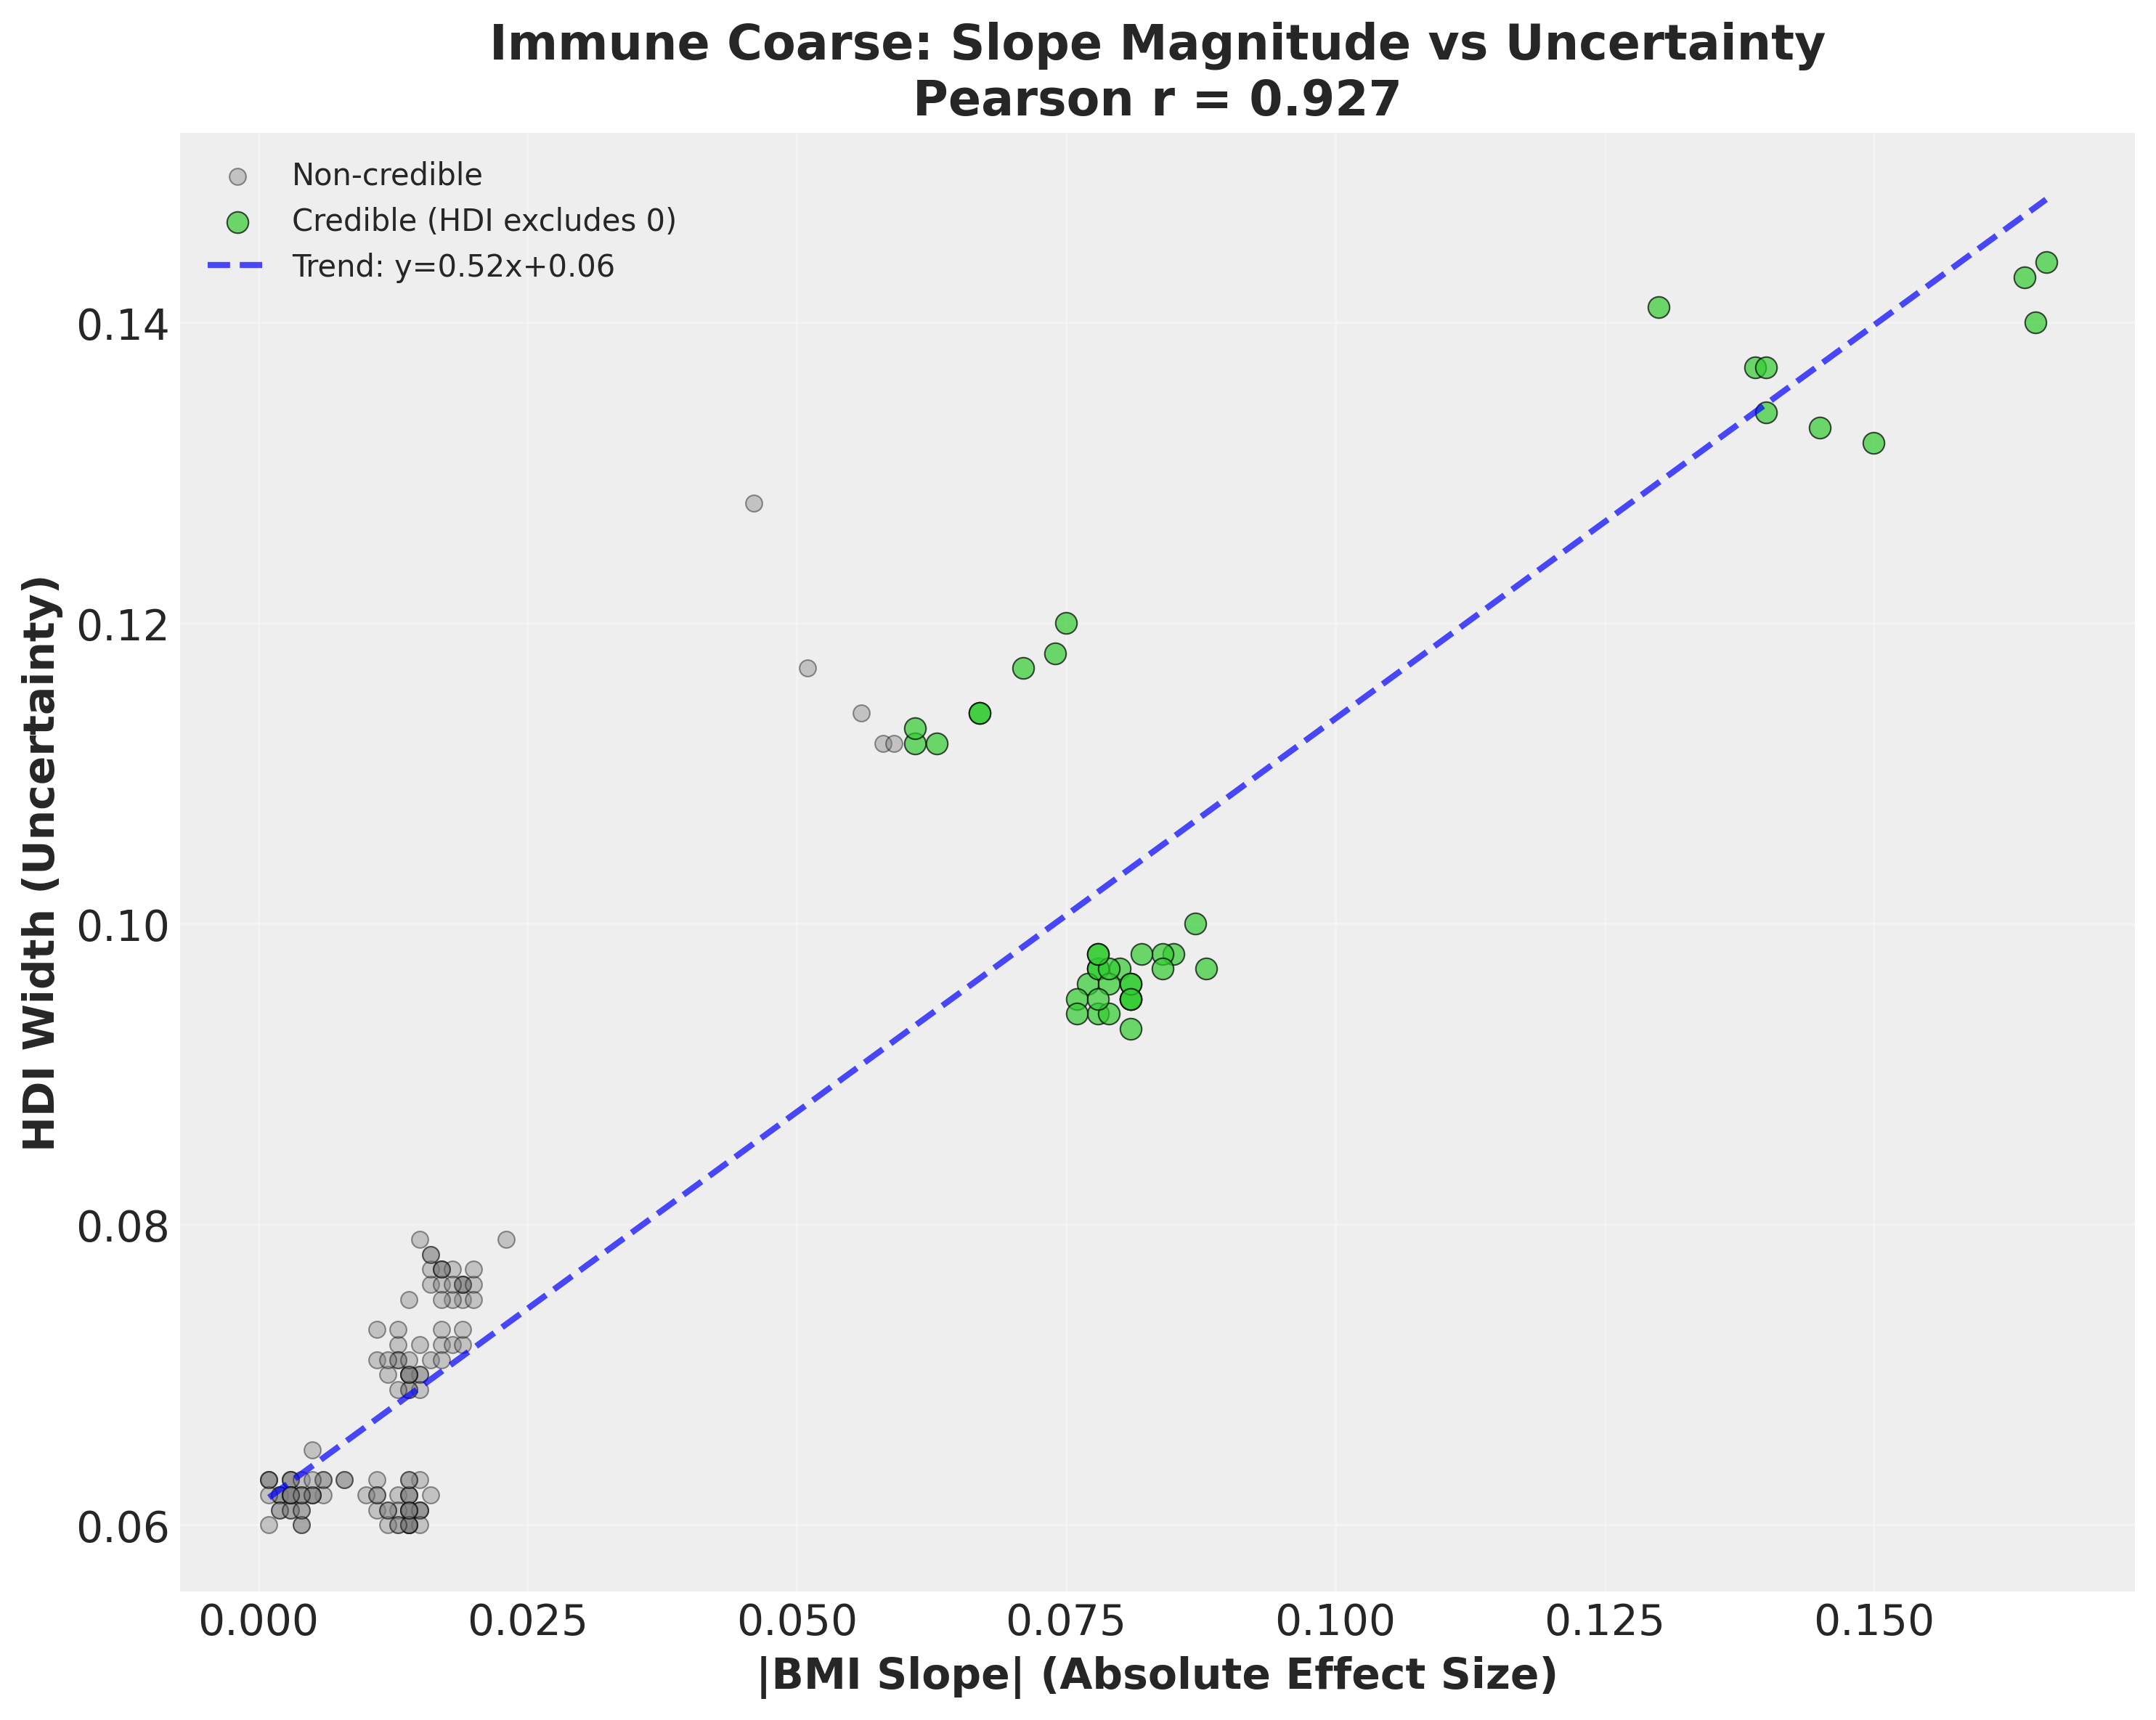


2. SIGNAL-TO-NOISE RATIO ANALYSIS

Signal-to-Noise Ratios:
  Mean SNR: 1.354
  Median SNR: 0.885
  Max SNR: 4.620

Features by signal strength:
  Strong signal (SNR > 2): 44/167 (26.3%)
  Moderate signal (1 < SNR ≤ 2): 10/167 (6.0%)
  Weak signal (SNR ≤ 1): 113/167 (67.7%)

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_quantitative_validation/signal_to_noise_ratio.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/immune_coarse/signal_to_noise_ratio.svg


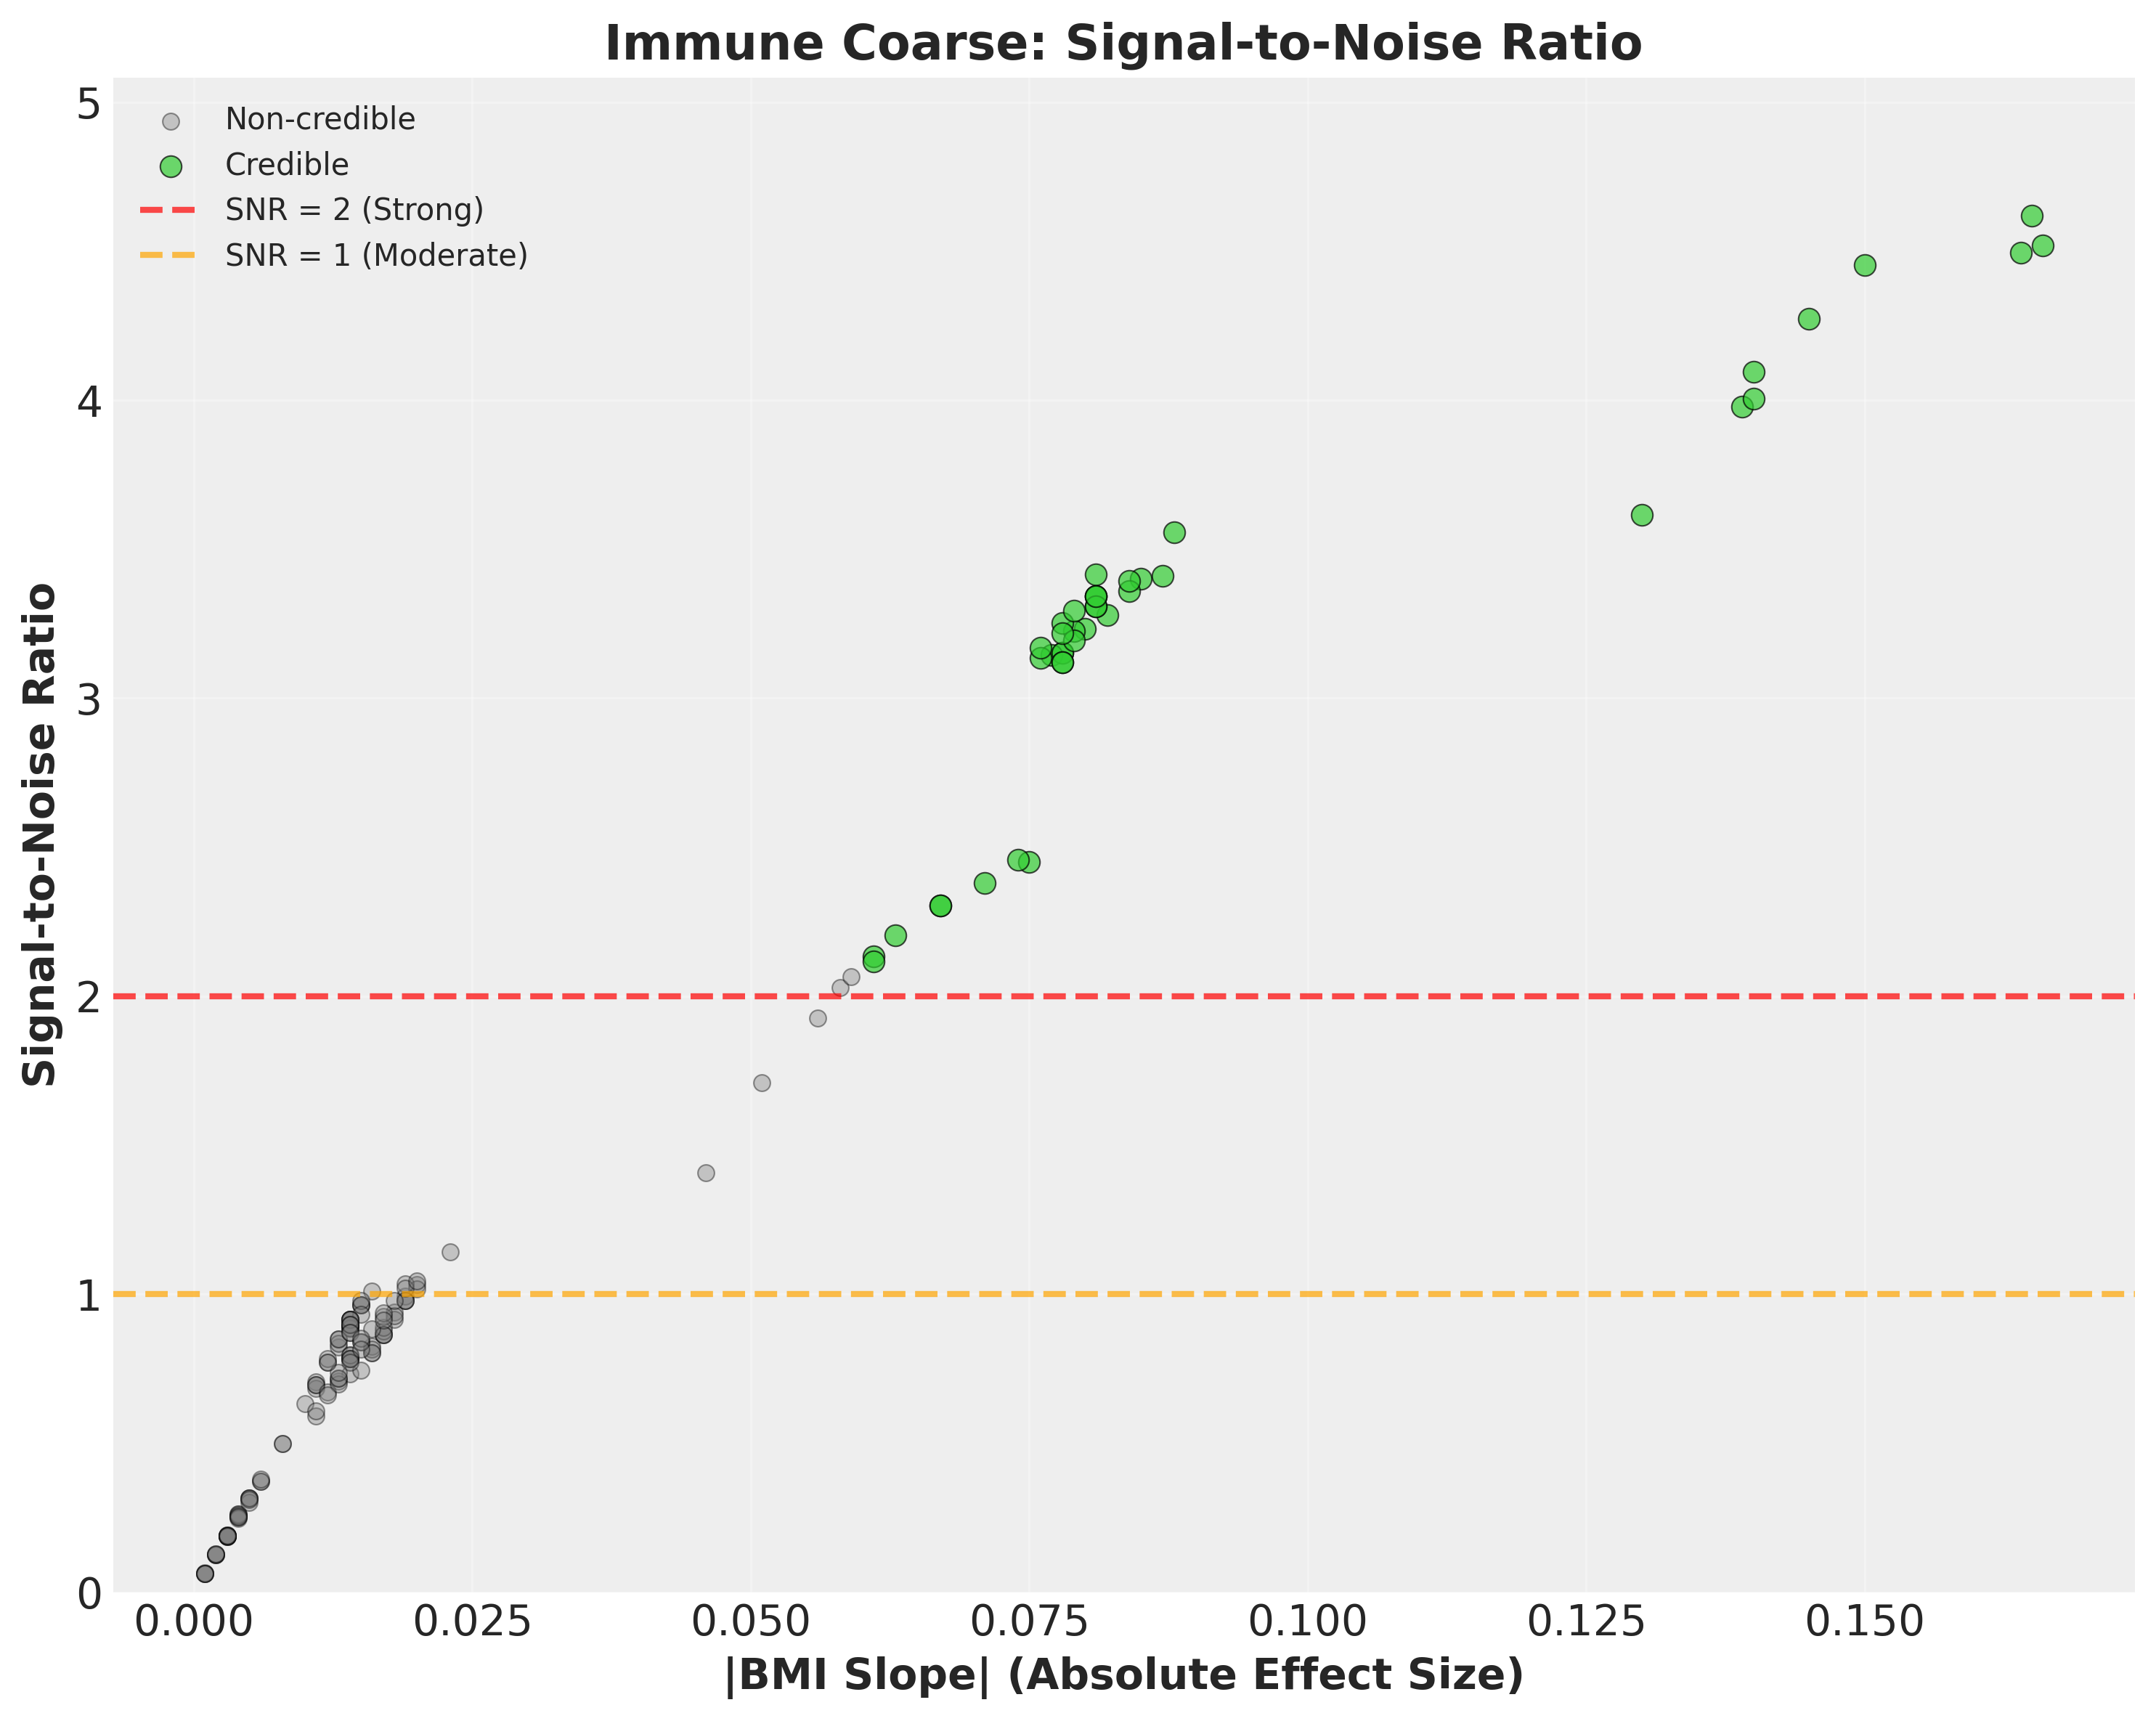


3. EFFECT SIZE DISTRIBUTION

BMI Slope Distribution:
  Mean: 0.0093
  Median: -0.0030
  SD: 0.0501
  Range: [-0.0880, 0.1660]

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_quantitative_validation/effect_size_distribution.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/immune_coarse/effect_size_distribution.svg


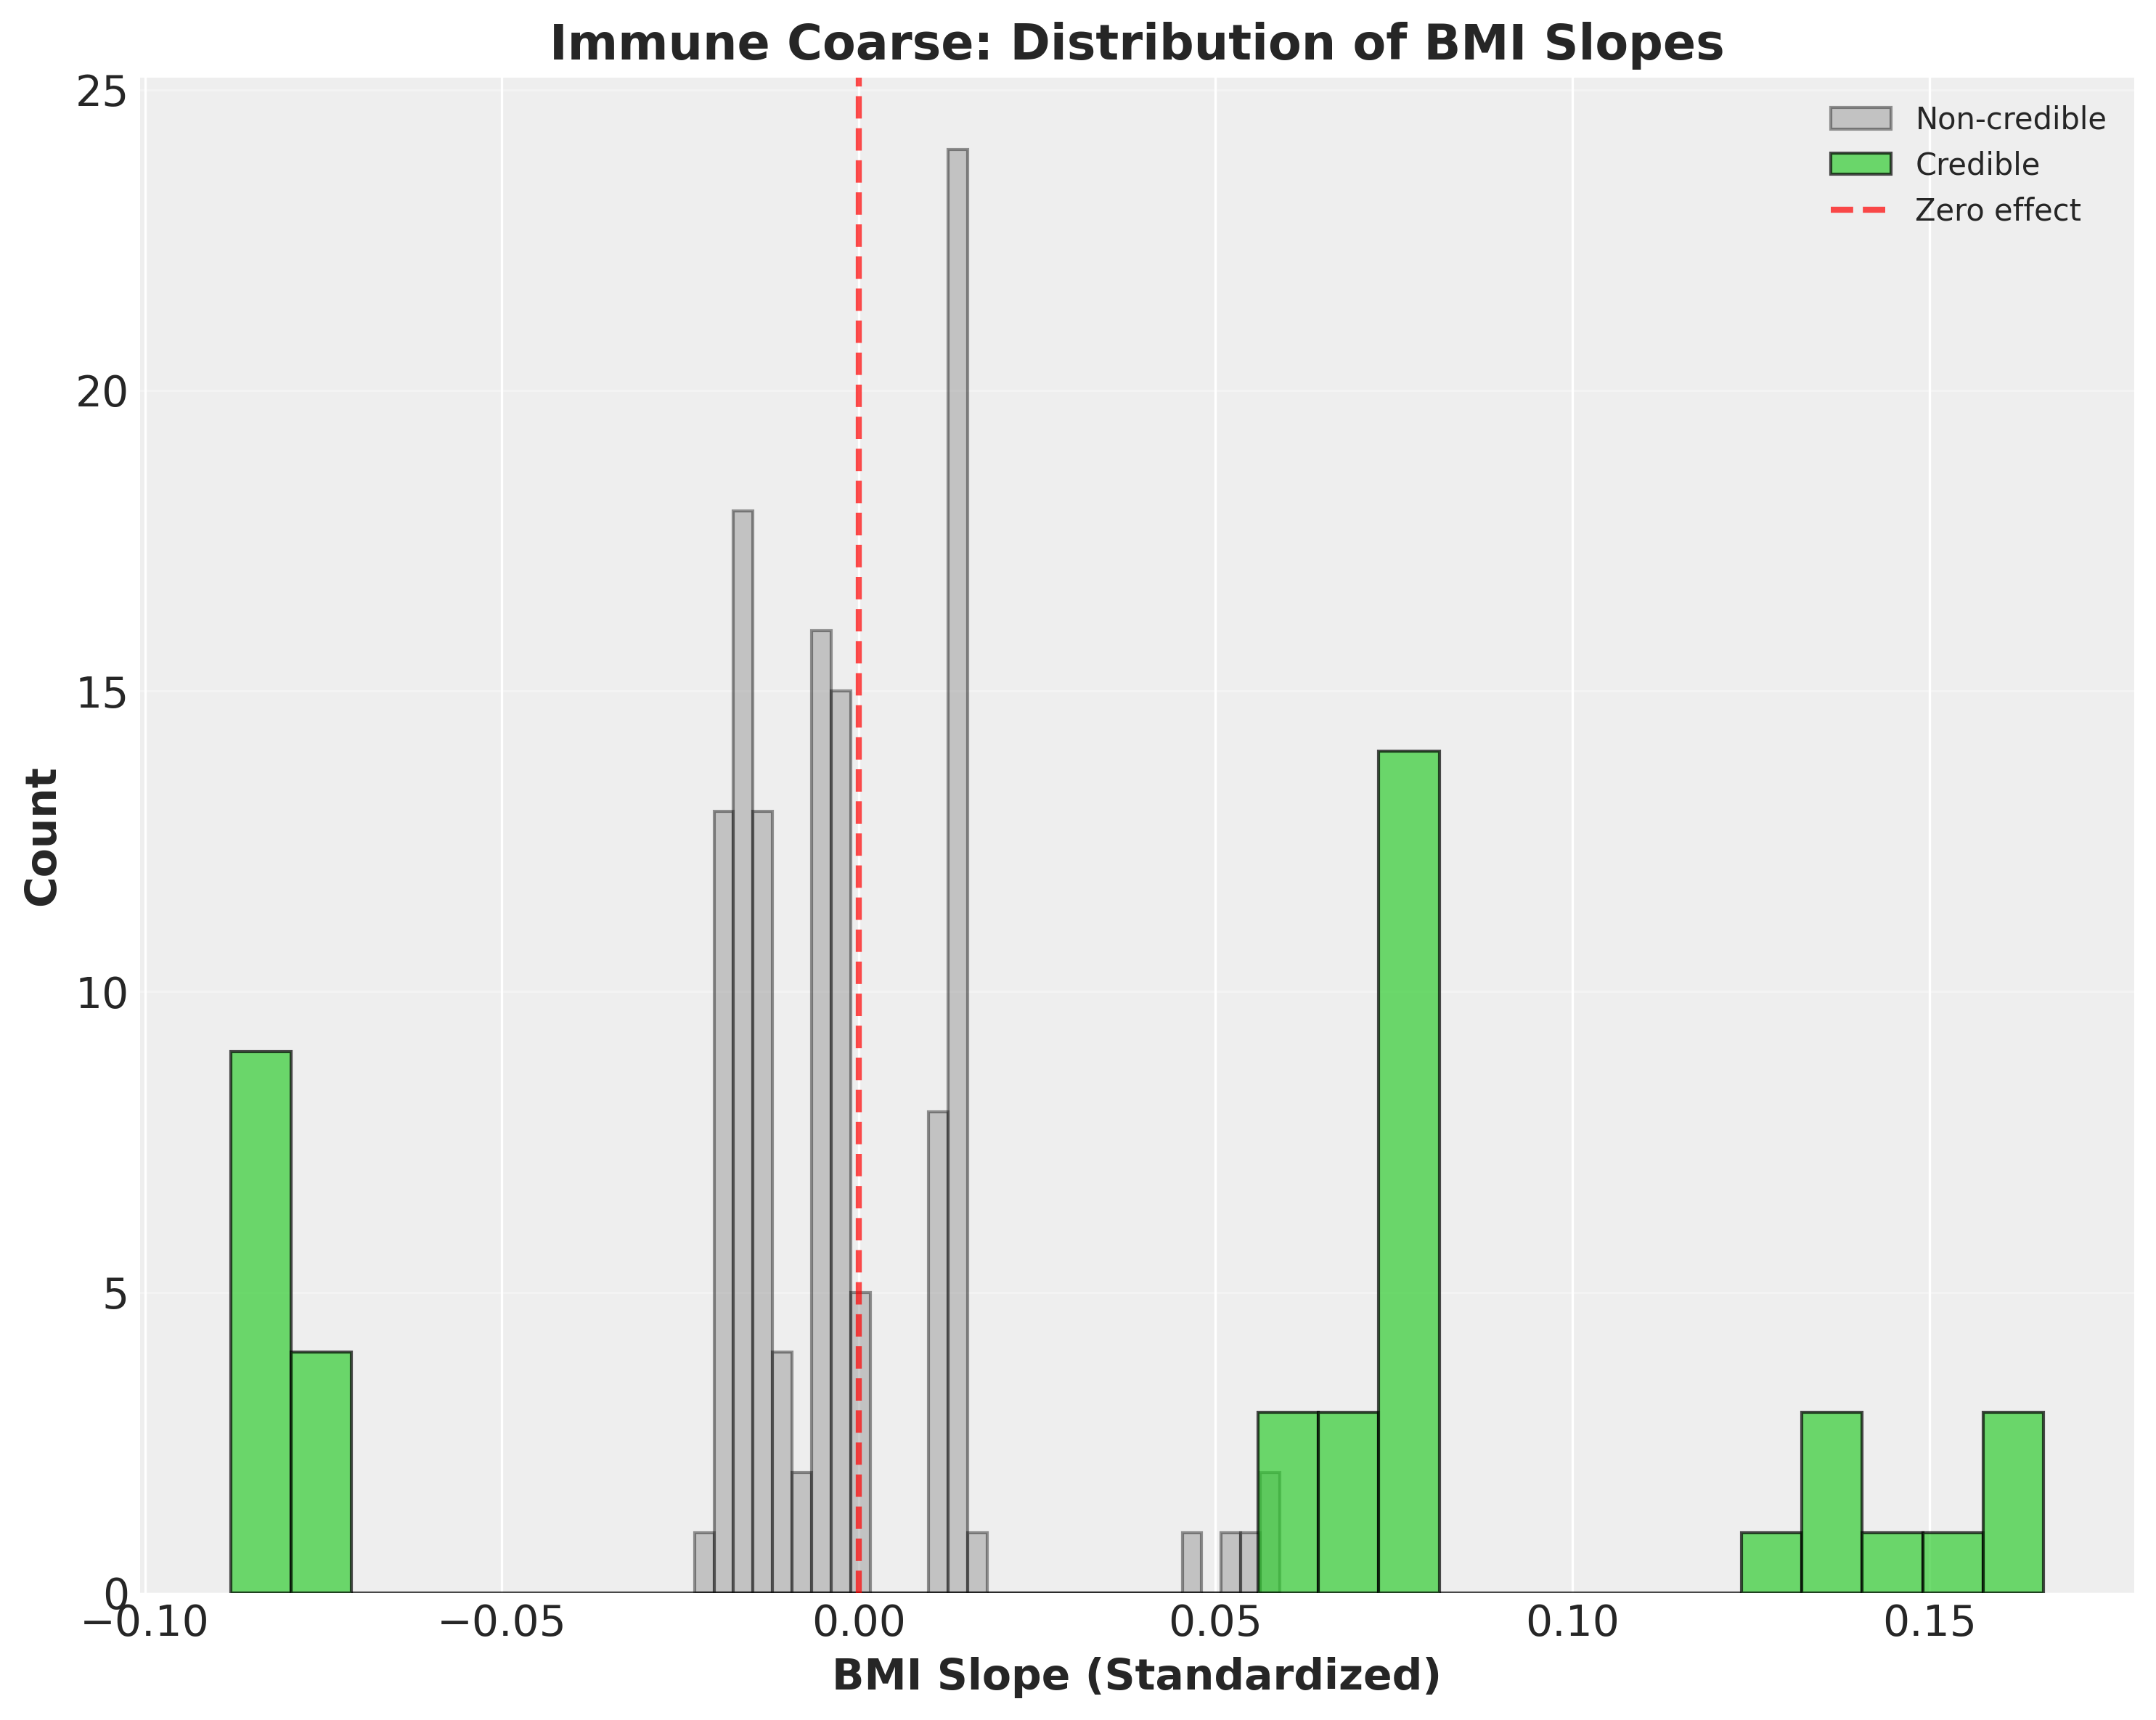


4. PRECISION ANALYSIS

Precision Statistics:
  Mean: 2941.6
  Median: 3048.3
  Range: [741.0, 4268.4]
  High precision (>75th percentile): 30/167

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_quantitative_validation/precision_vs_effect_size.png
💾 Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/immune_coarse/precision_vs_effect_size.svg


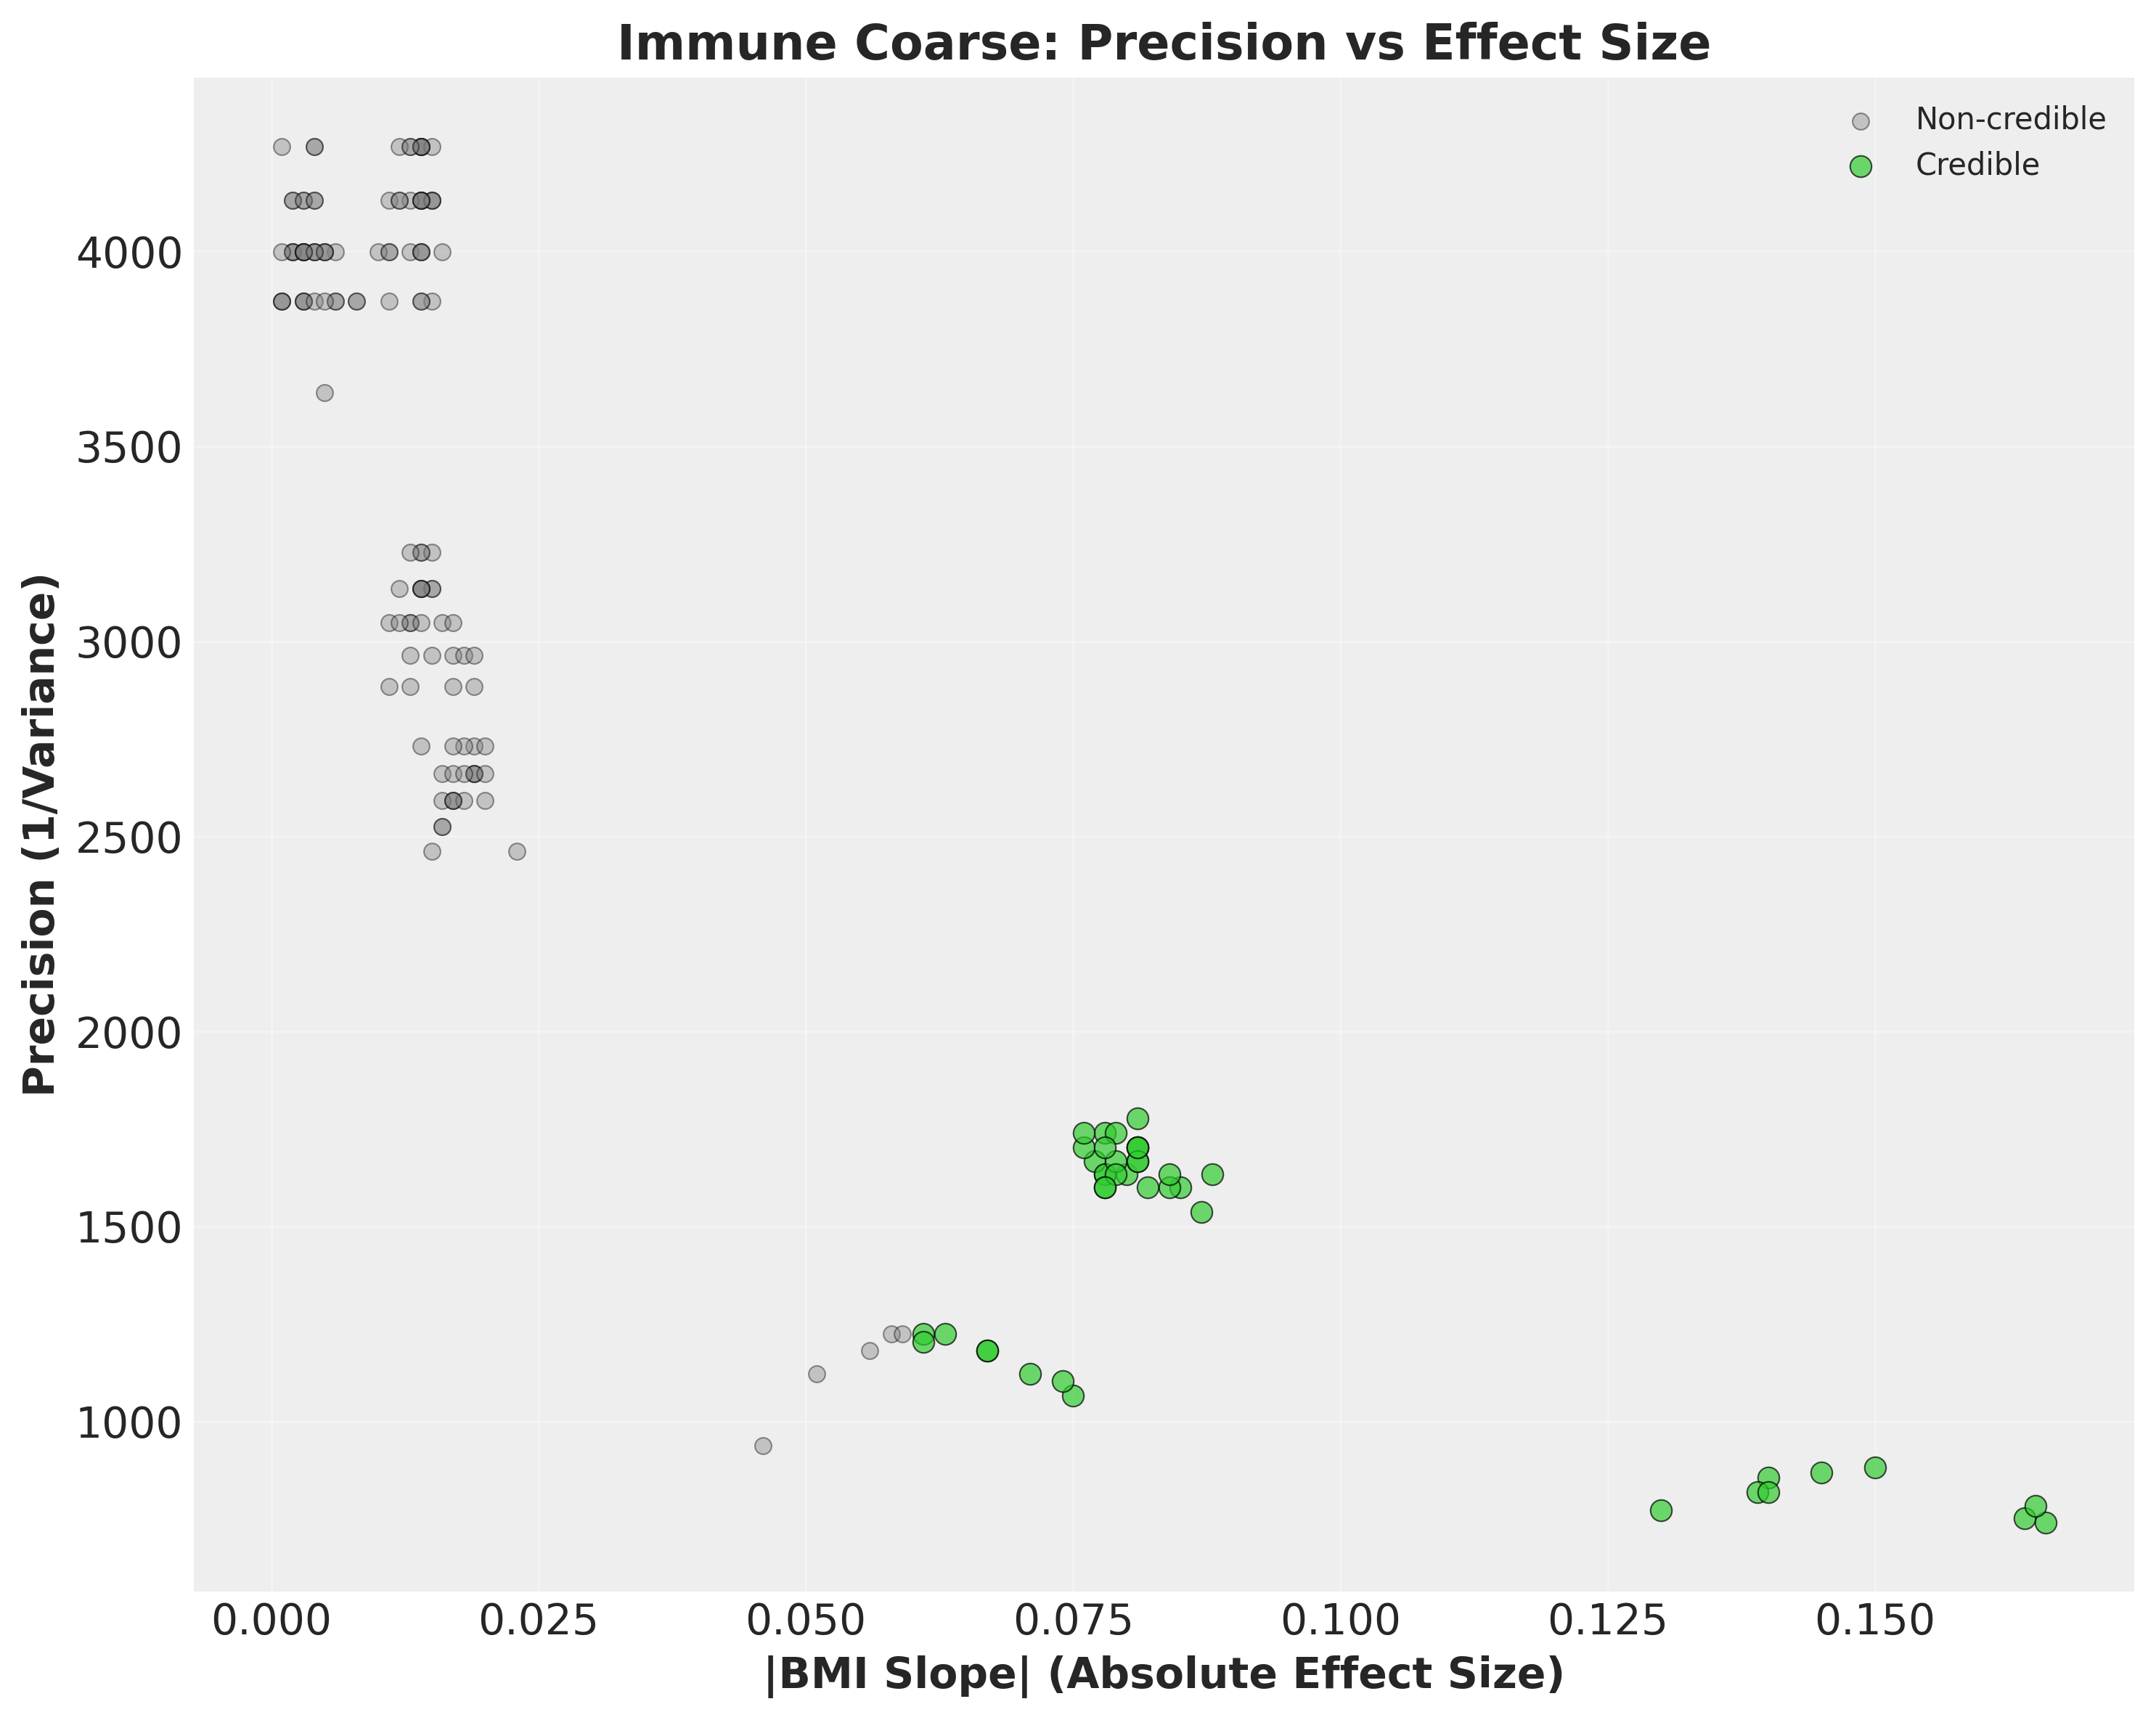


QUANTITATIVE VALIDATION (CONTINUOUS BMI): Immune Coarse

SLOPE MAGNITUDE vs UNCERTAINTY:
  Pearson: r = 0.927, p = 3.06e-72
  Spearman: ρ = 0.820, p = 6.87e-42
  Interpretation: Positive relationship

SIGNAL-TO-NOISE RATIO:
  Mean SNR: 1.354
  Median SNR: 0.885
  Strong signals (SNR>2): 44/167 (26.3%)
  Moderate signals (1<SNR≤2): 10/167 (6.0%)

EFFECT SIZE DISTRIBUTION:
  Mean slope: 0.0093
  Median slope: -0.0030
  SD: 0.0501

CREDIBILITY:
  Credible effects: 42/167 (25.1%)
  Positive slopes: 29 (17.4%)
  Negative slopes: 13 (7.8%)

💾 Saved: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_quantitative_validation/validation_summary_continuous.txt
💾 Saved (SVG dir): /content/drive/MyDrive/new_dysfunction/svg_continuous/quantitative_validation/immune_coarse/validation_summary_continuous.txt

✅ FINISHED: Immune Coarse

🎉 ALL THREE COMPARTMENTS COMPLETED SUCCESSFULLY!

OUTPUT LOCATIONS:

NON-IMMUNE:
  Main outputs: /content/drive/MyDrive/n

In [ ]:
#!/usr/bin/env python3
"""
SCRIPT 3: Quantitative Validation (Slope Magnitude vs Uncertainty)
CONTINUOUS BMI VERSION
Runs for all compartments: nonimmune, immune_fine, immune_coarse
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ======================================================================
# CONFIGURATION
# ======================================================================

BASE = "/content/drive/MyDrive/new_dysfunction"

COMPARTMENTS = {
    'nonimmune': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_nonimmune",
        'name': 'Non-Immune',
        'color': '#8B4513'
    },
    'immune_fine': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_immune_fine",
        'name': 'Immune Fine',
        'color': '#4169E1'
    },
    'immune_coarse': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_immune_coarse",
        'name': 'Immune Coarse',
        'color': '#32CD32'
    }
}

FIGURE_DPI = 300

# SVG output configuration
SVG_BASE = f"{BASE}/svg_continuous"
SVG_SUBFOLDER = "quantitative_validation"

# ======================================================================
# MAIN LOOP (RUN FOR ALL 3 COMPARTMENTS)
# ======================================================================

for COMPARTMENT, info in COMPARTMENTS.items():

    MODEL_DIR = info['dir']
    COMP_NAME = info['name']
    COMP_COLOR = info['color']

    print("\n" + "="*80)
    print(f"QUANTITATIVE VALIDATION (CONTINUOUS BMI): {COMP_NAME}")
    print("="*80)

    out_dir = os.path.join(MODEL_DIR, "continuous_quantitative_validation")
    os.makedirs(out_dir, exist_ok=True)

    # Create SVG output directory
    svg_out_dir = os.path.join(SVG_BASE, SVG_SUBFOLDER, COMPARTMENT)
    os.makedirs(svg_out_dir, exist_ok=True)

    results_path = os.path.join(MODEL_DIR, "bayesian_results_continuous_with_rope.csv")
    print(f"\nLoading results: {results_path}")

    if not os.path.exists(results_path):
        print(f"  ⚠️  Results file not found, skipping {COMPARTMENT}")
        continue

    results = pd.read_csv(results_path)

    # ==================================================================
    # 1. SLOPE MAGNITUDE vs UNCERTAINTY
    # ==================================================================

    print("\n" + "="*80)
    print("1. SLOPE MAGNITUDE vs UNCERTAINTY ANALYSIS")
    print("="*80)

    slope_mean = results['bmi_slope_standardized_mean'].values
    slope_low = results['bmi_slope_standardized_hdi_low'].values
    slope_high = results['bmi_slope_standardized_hdi_high'].values

    # Calculate HDI width (uncertainty)
    hdi_width = slope_high - slope_low
    slope_abs = np.abs(slope_mean)

    # Correlation between magnitude and uncertainty
    pearson_r, pearson_p = stats.pearsonr(slope_abs, hdi_width)
    spearman_r, spearman_p = stats.spearmanr(slope_abs, hdi_width)

    print(f"\nSlope Magnitude vs Uncertainty:")
    print(f"  Pearson correlation: r = {pearson_r:.3f}, p = {pearson_p:.2e}")
    print(f"  Spearman correlation: ρ = {spearman_r:.3f}, p = {spearman_p:.2e}")

    # Categorize by credibility
    is_credible = results['bmi_slope_credible'].values if 'bmi_slope_credible' in results.columns else np.zeros(len(results), dtype=bool)

    # Scatter plot: Magnitude vs Uncertainty
    fig, ax = plt.subplots(figsize=(10, 8), dpi=FIGURE_DPI)

    # Plot non-credible in gray
    ax.scatter(slope_abs[~is_credible], hdi_width[~is_credible],
               alpha=0.4, s=30, color='gray', edgecolor='black', linewidth=0.5,
               label='Non-credible')

    # Plot credible in color
    ax.scatter(slope_abs[is_credible], hdi_width[is_credible],
               alpha=0.7, s=50, color=COMP_COLOR, edgecolor='black', linewidth=0.5,
               label='Credible (HDI excludes 0)')

    # Add trend line
    z = np.polyfit(slope_abs, hdi_width, 1)
    p = np.poly1d(z)
    x_trend = np.linspace(slope_abs.min(), slope_abs.max(), 100)
    ax.plot(x_trend, p(x_trend), "b--", linewidth=2, alpha=0.7,
            label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')

    ax.set_xlabel('|BMI Slope| (Absolute Effect Size)', fontsize=14, fontweight='bold')
    ax.set_ylabel('HDI Width (Uncertainty)', fontsize=14, fontweight='bold')
    ax.set_title(f'{COMP_NAME}: Slope Magnitude vs Uncertainty\nPearson r = {pearson_r:.3f}',
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(out_dir, "slope_magnitude_vs_uncertainty.png")
    plt.savefig(fig_path, dpi=FIGURE_DPI, bbox_inches='tight')
    print(f"\nSaved: {fig_path}")

    svg_fig_path = os.path.join(svg_out_dir, "slope_magnitude_vs_uncertainty.svg")
    plt.savefig(svg_fig_path, format='svg', bbox_inches='tight')
    print(f"Saved SVG: {svg_fig_path}")

    plt.show()

    # ==================================================================
    # 2. SIGNAL-TO-NOISE RATIO ANALYSIS
    # ==================================================================

    print("\n" + "="*80)
    print("2. SIGNAL-TO-NOISE RATIO ANALYSIS")
    print("="*80)

    # Calculate posterior SD from HDI width (assuming normal distribution)
    # 95% HDI width ≈ 3.92 * SD
    post_sd = hdi_width / 3.92

    # SNR = |effect| / SD
    snr = slope_abs / post_sd

    print(f"\nSignal-to-Noise Ratios:")
    print(f"  Mean SNR: {snr.mean():.3f}")
    print(f"  Median SNR: {np.median(snr):.3f}")
    print(f"  Max SNR: {snr.max():.3f}")

    high_snr = (snr > 2).sum()
    moderate_snr = ((snr > 1) & (snr <= 2)).sum()
    low_snr = (snr <= 1).sum()

    print(f"\nFeatures by signal strength:")
    print(f"  Strong signal (SNR > 2): {high_snr}/{len(results)} ({high_snr/len(results)*100:.1f}%)")
    print(f"  Moderate signal (1 < SNR ≤ 2): {moderate_snr}/{len(results)} ({moderate_snr/len(results)*100:.1f}%)")
    print(f"  Weak signal (SNR ≤ 1): {low_snr}/{len(results)} ({low_snr/len(results)*100:.1f}%)")

    # SNR vs Slope Magnitude
    fig, ax = plt.subplots(figsize=(10, 8), dpi=FIGURE_DPI)

    # Color by credibility
    ax.scatter(slope_abs[~is_credible], snr[~is_credible],
               alpha=0.4, s=30, color='gray', edgecolor='black', linewidth=0.5,
               label='Non-credible')
    ax.scatter(slope_abs[is_credible], snr[is_credible],
               alpha=0.7, s=50, color=COMP_COLOR, edgecolor='black', linewidth=0.5,
               label='Credible')

    # Reference lines
    ax.axhline(2, color='red', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 2 (Strong)')
    ax.axhline(1, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 1 (Moderate)')

    ax.set_xlabel('|BMI Slope| (Absolute Effect Size)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Signal-to-Noise Ratio', fontsize=14, fontweight='bold')
    ax.set_title(f'{COMP_NAME}: Signal-to-Noise Ratio',
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(alpha=0.3)
    ax.set_ylim([0, snr.max() * 1.1])

    plt.tight_layout()
    fig_path = os.path.join(out_dir, "signal_to_noise_ratio.png")
    plt.savefig(fig_path, dpi=FIGURE_DPI, bbox_inches='tight')
    print(f"\nSaved: {fig_path}")

    svg_fig_path = os.path.join(svg_out_dir, "signal_to_noise_ratio.svg")
    plt.savefig(svg_fig_path, format='svg', bbox_inches='tight')
    print(f"Saved SVG: {svg_fig_path}")

    plt.show()

    # ==================================================================
    # 3. EFFECT SIZE DISTRIBUTION
    # ==================================================================

    print("\n" + "="*80)
    print("3. EFFECT SIZE DISTRIBUTION")
    print("="*80)

    print(f"\nBMI Slope Distribution:")
    print(f"  Mean: {slope_mean.mean():.4f}")
    print(f"  Median: {np.median(slope_mean):.4f}")
    print(f"  SD: {slope_mean.std():.4f}")
    print(f"  Range: [{slope_mean.min():.4f}, {slope_mean.max():.4f}]")

    # Histogram with credible vs non-credible
    fig, ax = plt.subplots(figsize=(10, 8), dpi=FIGURE_DPI)

    ax.hist(slope_mean[~is_credible], bins=30, alpha=0.4, color='gray',
            label='Non-credible', edgecolor='black')
    ax.hist(slope_mean[is_credible], bins=30, alpha=0.7, color=COMP_COLOR,
            label='Credible', edgecolor='black')

    ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Zero effect')
    ax.set_xlabel('BMI Slope (Standardized)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=14, fontweight='bold')
    ax.set_title(f'{COMP_NAME}: Distribution of BMI Slopes',
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    fig_path = os.path.join(out_dir, "effect_size_distribution.png")
    plt.savefig(fig_path, dpi=FIGURE_DPI, bbox_inches='tight')
    print(f"\nSaved: {fig_path}")

    svg_fig_path = os.path.join(svg_out_dir, "effect_size_distribution.svg")
    plt.savefig(svg_fig_path, format='svg', bbox_inches='tight')
    print(f"Saved SVG: {svg_fig_path}")

    plt.show()

    # ==================================================================
    # 4. PRECISION ANALYSIS (Inverse of Uncertainty)
    # ==================================================================

    print("\n" + "="*80)
    print("4. PRECISION ANALYSIS")
    print("="*80)

    # Precision = 1 / Variance ≈ 1 / SD^2
    precision = 1 / (post_sd ** 2)

    print(f"\nPrecision Statistics:")
    print(f"  Mean: {precision.mean():.1f}")
    print(f"  Median: {np.median(precision):.1f}")
    print(f"  Range: [{precision.min():.1f}, {precision.max():.1f}]")

    # High precision features
    high_precision_threshold = np.percentile(precision, 75)
    high_precision_count = (precision > high_precision_threshold).sum()
    print(f"  High precision (>75th percentile): {high_precision_count}/{len(results)}")

    # Precision vs Effect Size
    fig, ax = plt.subplots(figsize=(10, 8), dpi=FIGURE_DPI)

    ax.scatter(slope_abs[~is_credible], precision[~is_credible],
               alpha=0.4, s=30, color='gray', edgecolor='black', linewidth=0.5,
               label='Non-credible')
    ax.scatter(slope_abs[is_credible], precision[is_credible],
               alpha=0.7, s=50, color=COMP_COLOR, edgecolor='black', linewidth=0.5,
               label='Credible')

    ax.set_xlabel('|BMI Slope| (Absolute Effect Size)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Precision (1/Variance)', fontsize=14, fontweight='bold')
    ax.set_title(f'{COMP_NAME}: Precision vs Effect Size',
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(out_dir, "precision_vs_effect_size.png")
    plt.savefig(fig_path, dpi=FIGURE_DPI, bbox_inches='tight')
    print(f"\nSaved: {fig_path}")

    svg_fig_path = os.path.join(svg_out_dir, "precision_vs_effect_size.svg")
    plt.savefig(svg_fig_path, format='svg', bbox_inches='tight')
    print(f"Saved SVG: {svg_fig_path}")

    plt.show()

    # ==================================================================
    # Save summary
    # ==================================================================

    report = []
    report.append("="*80)
    report.append(f"QUANTITATIVE VALIDATION (CONTINUOUS BMI): {COMP_NAME}")
    report.append("="*80)
    report.append("")
    report.append("SLOPE MAGNITUDE vs UNCERTAINTY:")
    report.append(f"  Pearson: r = {pearson_r:.3f}, p = {pearson_p:.2e}")
    report.append(f"  Spearman: ρ = {spearman_r:.3f}, p = {spearman_p:.2e}")
    report.append(f"  Interpretation: {'Positive' if pearson_r > 0 else 'Negative'} relationship")
    report.append("")
    report.append("SIGNAL-TO-NOISE RATIO:")
    report.append(f"  Mean SNR: {snr.mean():.3f}")
    report.append(f"  Median SNR: {np.median(snr):.3f}")
    report.append(f"  Strong signals (SNR>2): {high_snr}/{len(results)} ({high_snr/len(results)*100:.1f}%)")
    report.append(f"  Moderate signals (1<SNR≤2): {moderate_snr}/{len(results)} ({moderate_snr/len(results)*100:.1f}%)")
    report.append("")
    report.append("EFFECT SIZE DISTRIBUTION:")
    report.append(f"  Mean slope: {slope_mean.mean():.4f}")
    report.append(f"  Median slope: {np.median(slope_mean):.4f}")
    report.append(f"  SD: {slope_mean.std():.4f}")
    report.append("")
    report.append("CREDIBILITY:")
    report.append(f"  Credible effects: {is_credible.sum()}/{len(results)} ({is_credible.sum()/len(results)*100:.1f}%)")
    if 'bmi_slope_direction' in results.columns:
        n_pos = (results['bmi_slope_direction'] == 'positive').sum()
        n_neg = (results['bmi_slope_direction'] == 'negative').sum()
        report.append(f"  Positive slopes: {n_pos} ({n_pos/len(results)*100:.1f}%)")
        report.append(f"  Negative slopes: {n_neg} ({n_neg/len(results)*100:.1f}%)")
    report.append("")

    report_text = "\n".join(report)
    print("\n" + report_text)

    report_path = os.path.join(out_dir, "validation_summary_continuous.txt")
    with open(report_path, 'w') as f:
        f.write(report_text)
    print(f"Saved: {report_path}")

    # Also save to SVG directory
    svg_report_path = os.path.join(svg_out_dir, "validation_summary_continuous.txt")
    with open(svg_report_path, 'w') as f:
        f.write(report_text)
    print(f"Saved (SVG dir): {svg_report_path}")

    print("\nFINISHED:", COMP_NAME)

print("\nALL THREE COMPARTMENTS COMPLETED SUCCESSFULLY!")

print("\n" + "="*80)
print("OUTPUT LOCATIONS:")
print("="*80)
for COMPARTMENT, info in COMPARTMENTS.items():
    print(f"\n{info['name'].upper()}:")
    print(f"  Main outputs: {info['dir']}/continuous_quantitative_validation/")
    print(f"  SVG outputs:  {SVG_BASE}/{SVG_SUBFOLDER}/{COMPARTMENT}/")